In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, precision_score,
                             recall_score, f1_score, classification_report,
                             roc_auc_score, RocCurveDisplay, auc,silhouette_score,
                             adjusted_rand_score,precision_recall_curve,
                             average_precision_score,roc_curve)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


- Separating by each audio moth (each audio moth has different acoustic features)

- Graph the importance of each feature for each model

- run on google colab pro using student email

# Project Sections

## Table of Contents

1. [Data Loading](#data-loading)

2. [Feature Selection](#feature-selection)

3. [Isolation Forest](#isolation-forest)

4. [XGBoosting](#xgboosting)

5. [Light GBM](#light-gbm)

6. [Sentinel Species](#sentinel-species)

7. [MLP Neural Network](#mlp-neural-network)


- Look at other models
 - how new models may addres class imbalance
- Train model on one audio moth and evaluate on other audio moth
 - improve current model with new features

# Data Loading

In [ ]:
import pandas as pd
from google.colab import drive

file_path = '/content/drive/MyDrive/Audio Moth Data/sliding_window_acoustic.csv'
df = None # Initialize df to None

try:
    df = pd.read_csv(file_path)
    print("File loaded successfully on first attempt.")
except OSError as e:
    # Check for the specific error related to Drive disconnection
    if "Transport endpoint is not connected" in str(e):
        print(f"OSError: {e}. Google Drive connection may be lost. Attempting to re-mount and retry...")
        try:
            # Attempt to mount Drive. This is idempotent and won't harm if already mounted.
            # It will prompt user for authentication if not already authenticated in the session.
            drive.mount('/content/drive')
            print("Google Drive mount command executed. Retrying file load...")
            df = pd.read_csv(file_path)
            print("File loaded successfully after re-mounting.")
        except Exception as retry_e:
            print(f"Failed to load file even after attempting to re-mount: {retry_e}")
    else:
        print(f"An unexpected OSError occurred: {e}")
except Exception as e:
    print(f"An unexpected error occurred during file loading: {e}")

if df is not None:
    df.info()
else:
    print("DataFrame 'df' could not be loaded.")

File loaded successfully on first attempt.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769365 entries, 0 to 769364
Data columns (total 90 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   recorder_id             769365 non-null  object 
 1   original_clip_name      769365 non-null  object 
 2   segment_id              769365 non-null  int64  
 3   start_time              769365 non-null  float64
 4   end_time                769365 non-null  float64
 5   window_duration         769365 non-null  float64
 6   onset_confidence        769365 non-null  int64  
 7   has_onset               769365 non-null  bool   
 8   preliminary_rms         769365 non-null  float64
 9   RMS Energy              769365 non-null  float64
 10  Zero Crossing Rate      769365 non-null  float64
 11  Spectral Bandwidth      769365 non-null  float64
 12  Spectral Rolloff (85%)  769365 non-null  float64
 13  Spectral Flatness       769365 

In [ ]:
df.sample(10)

,recorder_id,original_clip_name,segment_id,start_time,end_time,window_duration,onset_confidence,has_onset,preliminary_rms,RMS Energy,...,Precipitation,Humidity,Weathercode,Weather Desc,Timestamp Local,Sunrise,Sunset,Time Of Day,Timestamp UTC,Datetime_hour
168881,Audio_Moth_1,Audio_Moth_1_20250319_074209.wav,6,2.16,2.76,0.6,6,True,0.008402,0.008402,...,0.0,78,0,Clear sky,2025-03-19 08:00:00-06:00,2025-03-19 05:39:16.886691-06:00,2025-03-19 17:45:12.872250-06:00,morning,2025-03-19 14:00:00+00:00,8
699807,Audio_Moth_6,Audio_Moth_6_20250318_101619.wav,3,1.08,1.68,0.6,5,True,0.016699,0.016699,...,0.2,67,51,Light drizzle,2025-03-18 10:00:00-06:00,2025-03-18 05:39:48.918172-06:00,2025-03-18 17:45:16.092609-06:00,morning,2025-03-18 16:00:00+00:00,10
108103,Audio_Moth_1,Audio_Moth_1_20250319_005439.wav,2,0.72,1.32,0.6,1,True,0.078357,0.078357,...,0.0,89,1,Mainly clear,2025-03-19 01:00:00-06:00,2025-03-19 05:39:16.886691-06:00,2025-03-19 17:45:12.872250-06:00,night,2025-03-19 07:00:00+00:00,1
172700,Audio_Moth_1,Audio_Moth_1_20250319_143506.wav,3,1.08,1.68,0.6,8,True,0.017637,0.017637,...,0.2,76,51,Light drizzle,2025-03-19 15:00:00-06:00,2025-03-19 05:39:16.886691-06:00,2025-03-19 17:45:12.872250-06:00,afternoon,2025-03-19 21:00:00+00:00,15
380857,Audio_Moth_4,Audio_Moth_4_20250318_063037.wav,1,0.36,0.96,0.6,8,True,0.026095,0.026095,...,0.0,90,3,Overcast,2025-03-18 07:00:00-06:00,2025-03-18 05:39:48.918172-06:00,2025-03-18 17:45:16.092609-06:00,morning,2025-03-18 13:00:00+00:00,7
590198,Audio_Moth_5,Audio_Moth_5_20250318_115443.wav,0,0.00,0.60,0.6,2,True,0.022229,0.022229,...,0.3,66,51,Light drizzle,2025-03-18 12:00:00-06:00,2025-03-18 05:39:48.918172-06:00,2025-03-18 17:45:16.092609-06:00,afternoon,2025-03-18 18:00:00+00:00,12
324663,Audio_Moth_1,Audio_Moth_1_20250320_020418.wav,3,1.08,1.68,0.6,6,True,0.073179,0.073179,...,0.0,94,0,Clear sky,2025-03-20 02:00:00-06:00,2025-03-20 05:38:44.718176-06:00,2025-03-20 17:45:09.530345-06:00,night,2025-03-20 08:00:00+00:00,2
560973,Audio_Moth_5,Audio_Moth_5_20250320_061117.wav,0,0.00,0.60,0.6,1,True,0.053441,0.053441,...,0.0,96,3,Overcast,2025-03-20 06:00:00-06:00,2025-03-20 05:38:44.718176-06:00,2025-03-20 17:45:09.530345-06:00,morning,2025-03-20 12:00:00+00:00,6
271398,Audio_Moth_1,Audio_Moth_1_20250320_011239.wav,1,0.36,0.96,0.6,10,True,0.059825,0.059825,...,0.0,86,0,Clear sky,2025-03-20 01:00:00-06:00,2025-03-20 05:38:44.718176-06:00,2025-03-20 17:45:09.530345-06:00,night,2025-03-20 07:00:00+00:00,1
267167,Audio_Moth_1,Audio_Moth_1_20250320_223033.wav,5,1.80,2.40,0.6,10,True,0.202785,0.202785,...,0.0,86,0,Clear sky,2025-03-20 23:00:00-06:00,2025-03-20 05:38:44.718176-06:00,2025-03-20 17:45:09.530345-06:00,night,2025-03-21 05:00:00+00:00,23


In [ ]:
df['Sim Type'].unique()

array([nan, 'Human Presence on Trail', 'Vehicle', 'Gunshot', 'Chainsaw',
       'Human Presence off Trail'], dtype=object)

## Feature Selection

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# --- Feature Lists ---
core_features = [
    'RMS Energy', 'Spectral Contrast', 'Spectral Flatness',
    'Spectral Bandwidth', 'Spectral Rolloff (85%)',
    'Onset Strength', 'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13'
]

sentinel_features = ['is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant']

custom_features = [
    # --- Resilient Acoustic Features ---
     'Mean_F0',
    'Spectral Centroid',
    'Spectral Bandwidth',
    'Spectral Flatness',
    'Zero Crossing Rate',
    'RMS Energy',

    # --- Engineered Temporal Dynamics ---
    'RMS_Energy_Delta',
    'RMS_Energy_Rolling_Var',

    # --- Environmental Context ---
    'Windspeed',
    'Temperature',
    'Humidity',
    'Energy_per_Wind',

    # --- Cyclical Time ---
    'hour_sin',
    'hour_cos',

    # --- Biological Indicators ---
    'is_Orange_billed_Sparrow',
    'is_Antpitta',
    'is_Pygmy_Tyrant',
    'sentinel_active_count',
    'is_suspiciously_quiet'
]

# --- Prevent KeyError: Create the target variable ---
if 'is_simulation' not in df.columns:
    df['is_simulation'] = (~df['Sim Type'].isna()).astype(int)

# --- Ensure we only use features that actually exist in the dataframe ---
custom_features = [col for col in custom_features if col in df.columns]

# --- Assign Features (X) and Target (y) ---
X = df[custom_features]
y = df['is_simulation']

# --- Plotting Functions ---
def plot_feature_importance(model, feature_names, title):
    importances = model.feature_importances_
    feature_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
    plt.title(title, fontsize=16)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_permutation_importance(model, X_test, y_test, feature_names, title):
    print("Calculating permutation importance...")
    result = permutation_importance(
        model, X_test, y_test, n_repeats=10, random_state=42, scoring='f1'
    )
    importances = result.importances_mean
    feature_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
    plt.title(title, fontsize=16)
    plt.xlabel('Importance Score (Decrease in F1-Score)', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()

# --- Print Dataset Stats ---
print(f"Total samples: {len(df)}")
print(f"Simulation samples: {df['is_simulation'].sum()}")
print(f"Baseline samples: {(df['is_simulation'] == 0).sum()}")
print(f"Simulation types:\n{df['Sim Type'].value_counts()}")

Total samples: 769365
Simulation samples: 6657
Baseline samples: 762708
Simulation types:
Sim Type
Human Presence on Trail     5425
Vehicle                      812
Gunshot                      196
Chainsaw                     175
Human Presence off Trail      49
Name: count, dtype: int64


In [ ]:
X = df[core_features].copy()
y = df['is_simulation'].copy()
print(f"Missing values in features: {X.isnull().sum().sum()}")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set - Simulation: {y_train.sum()}, Baseline: {(y_train == 0).sum()}")
print(f"Test set - Simulation: {y_test.sum()}, Baseline: {(y_test == 0).sum()}")


Missing values in features: 0
Train set - Simulation: 5326, Baseline: 610166
Test set - Simulation: 1331, Baseline: 152542


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scale_pos_weight = (y_train == 0).sum() / y_train.sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

Scale pos weight: 114.56


In [ ]:
#Dataset A: Audio_Moth_1 only (open area)
df_moth1 = df[df['recorder_id'] == 'Audio_Moth_1'].copy()
print(f"Dataset A (Audio_Moth_1 - open area): {df_moth1.shape[0]} samples")

#Dataset B: All Audio_Moth recorders (including moth1)
df_all_moths = df[df['recorder_id'].str.contains('Audio_Moth', na=False)].copy()
print(f"Dataset B (All Audio_Moth recorders): {df_all_moths.shape[0]} samples")

print(f"\nTotal samples: {len(df)}")
print(f"Unique recorders: {df['recorder_id'].unique()}")
print(f"Audio_Moth recorders: {df_all_moths['recorder_id'].unique()}")

def prepare_features(df, dataset_name):
    print(f"\n=== {dataset_name} ===")

    df_clean = df[core_features].replace([np.inf, -np.inf], np.nan).dropna()
    keep_idx = df_clean.index
    df_subset = df.loc[keep_idx].copy()

    print(f"Shape after cleaning: {df_subset.shape}")
    print(f"Simulation samples: {df_subset['is_simulation'].sum()} ({df_subset['is_simulation'].mean():.2%})")

    return df_subset, df_clean.values

df_A, X_A = prepare_features(df_moth1, "Audio_Moth_1 (open area)")
df_B, X_B = prepare_features(df_all_moths, "All Audio_Moth recorders")

Dataset A (Audio_Moth_1 - open area): 332192 samples
Dataset B (All Audio_Moth recorders): 769365 samples

Total samples: 769365
Unique recorders: ['Audio_Moth_1' 'Audio_Moth_4' 'Audio_Moth_2' 'Audio_Moth_5'
 'Audio_Moth_6' 'Audio_Moth_3']
Audio_Moth recorders: ['Audio_Moth_1' 'Audio_Moth_4' 'Audio_Moth_2' 'Audio_Moth_5'
 'Audio_Moth_6' 'Audio_Moth_3']

=== Audio_Moth_1 (open area) ===
Shape after cleaning: (332192, 91)
Simulation samples: 1442 (0.43%)

=== All Audio_Moth recorders ===
Shape after cleaning: (769365, 91)
Simulation samples: 6657 (0.87%)


In [ ]:
from sklearn.cluster import DBSCAN

def perform_pca_analysis(X, df_subset, dataset_name):
    """Perform PCA analysis and return transformed data"""
    print(f"\n=== PCA Analysis for {dataset_name} ===")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca_full = PCA(random_state=42)
    pca_full.fit(X_scaled)

    print("Explained variance ratio by component:")
    for i, ratio in enumerate(pca_full.explained_variance_ratio_):
        print(f"Component {i+1}: {ratio:.2%} ({np.sum(pca_full.explained_variance_ratio_[:i+1]):.2%} cumulative)")

    n_components_90 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.90) + 1
    print(f"Components needed for 90% variance: {n_components_90}")

    pca_cluster = PCA(n_components=min(5, len(core_features)), random_state=42)
    pca_viz = PCA(n_components=2, random_state=42)

    X_pca_cluster = pca_cluster.fit_transform(X_scaled)
    X_pca_viz = pca_viz.fit_transform(X_scaled)

    df_subset_copy = df_subset.copy()
    df_subset_copy['pca1'] = X_pca_viz[:, 0]
    df_subset_copy['pca2'] = X_pca_viz[:, 1]

    print(f"PCA clustering components explained variance: {pca_cluster.explained_variance_ratio_.sum():.2%}")
    print(f"PCA visualization components explained variance: {pca_viz.explained_variance_ratio_.sum():.2%}")

    return X_scaled, X_pca_cluster, X_pca_viz, df_subset_copy, scaler, pca_cluster, pca_viz

results_A = perform_pca_analysis(X_A, df_A, "Audio_Moth_1 (open area)")
X_A_scaled, X_A_pca_cluster, X_A_pca_viz, df_A_pca, scaler_A, pca_cluster_A, pca_viz_A = results_A

results_B = perform_pca_analysis(X_B, df_B, "All Audio_Moth recorders")
X_B_scaled, X_B_pca_cluster, X_B_pca_viz, df_B_pca, scaler_B, pca_cluster_B, pca_viz_B = results_B


=== PCA Analysis for Audio_Moth_1 (open area) ===
Explained variance ratio by component:
Component 1: 33.13% (33.13% cumulative)
Component 2: 22.98% (56.11% cumulative)
Component 3: 13.36% (69.48% cumulative)
Component 4: 10.72% (80.19% cumulative)
Component 5: 7.74% (87.94% cumulative)
Component 6: 4.27% (92.21% cumulative)
Component 7: 3.61% (95.82% cumulative)
Component 8: 2.15% (97.97% cumulative)
Component 9: 1.15% (99.12% cumulative)
Component 10: 0.88% (100.00% cumulative)
Components needed for 90% variance: 6
PCA clustering components explained variance: 87.94%
PCA visualization components explained variance: 56.11%

=== PCA Analysis for All Audio_Moth recorders ===
Explained variance ratio by component:
Component 1: 37.31% (37.31% cumulative)
Component 2: 21.70% (59.01% cumulative)
Component 3: 11.86% (70.87% cumulative)
Component 4: 10.22% (81.09% cumulative)
Component 5: 6.30% (87.38% cumulative)
Component 6: 4.89% (92.28% cumulative)
Component 7: 3.80% (96.07% cumulative)


Model performance visualization

In [ ]:
def visualize_model_performance(df, y_train, y_test, y_pred, model_name="Model"):
    """
    Generates a timeline scatter plot and rolling accuracy plot for a trained model.

    Args:
        df (pd.DataFrame): The original full dataframe containing the 'Datetime' column.
        y_train (pd.Series): The training labels (indices must match df).
        y_test (pd.Series): The test labels (indices must match df).
        y_pred (np.array or list): The predicted labels for the test set.
        model_name (str): Title for the plot.
    """

    # 1. Prepare the Master Plotting DataFrame
    # We map y_train and y_test back to the original timestamps using their indices
    df_plot = df.loc[y_train.index.union(y_test.index), ['Datetime']].copy()
    df_plot['timestamp'] = pd.to_datetime(df_plot['Datetime'])
    df_plot = df_plot.sort_values('timestamp')

    # Initialize columns
    df_plot['actual_class'] = np.nan
    df_plot['predicted_class'] = np.nan
    df_plot['dataset_type'] = np.nan

    # Fill Train Data
    df_plot.loc[y_train.index, 'actual_class'] = y_train
    df_plot.loc[y_train.index, 'dataset_type'] = 'Train'

    # Fill Test Data & Predictions
    df_plot.loc[y_test.index, 'actual_class'] = y_test
    df_plot.loc[y_test.index, 'predicted_class'] = y_pred
    df_plot.loc[y_test.index, 'dataset_type'] = 'Test'

    # 2. Define Confusion Matrix Status (Test Set Only)
    test_mask = df_plot['dataset_type'] == 'Test'

    conditions = [
        (test_mask) & (df_plot['actual_class'] == 1) & (df_plot['predicted_class'] == 1), # TP
        (test_mask) & (df_plot['actual_class'] == 0) & (df_plot['predicted_class'] == 0), # TN
        (test_mask) & (df_plot['actual_class'] == 1) & (df_plot['predicted_class'] == 0), # FN
        (test_mask) & (df_plot['actual_class'] == 0) & (df_plot['predicted_class'] == 1), # FP
        (~test_mask) # Train
    ]
    choices = ['True Positive', 'True Negative', 'False Negative', 'False Positive', 'Train']
    df_plot['status'] = np.select(conditions, choices, default='Unknown')

    # 3. Setup Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    colors = {
        'Train': 'lightgrey',
        'True Positive': '#2ca02c',  # Green
        'True Negative': '#98df8a',  # Light Green
        'False Negative': '#d62728', # Red (Critical miss)
        'False Positive': '#ff7f0e'  # Orange (False alarm)
    }

    # --- Plot 1: Timeline Scatter ---
    plot_order = ['Train', 'True Negative', 'True Positive', 'False Positive', 'False Negative']

    for status in plot_order:
        subset = df_plot[df_plot['status'] == status]
        if subset.empty: continue

        # Jitter for visibility
        jitter = np.random.uniform(-0.05, 0.05, size=len(subset))

        # Styling based on status
        alpha_val = 0.15 if status in ['Train', 'True Negative'] else 0.7
        size_val = 15 if status in ['Train', 'True Negative'] else 25

        ax1.scatter(subset['timestamp'], subset['actual_class'] + jitter,
                    c=colors.get(status), label=status, alpha=alpha_val, s=size_val, edgecolors='none')

    # Formatting Top Plot
    f1 = f1_score(y_test, y_pred)
    ax1.set_title(f'{model_name} Timeline Analysis (Test F1: {f1:.4f})', fontsize=16)
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['Negative', 'Positive'])
    ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax1.grid(True, axis='x', alpha=0.3)

    # --- Plot 2: Rolling Trends ---
    window = 1000 # samples

    # Calculate Rolling Stats
    # Note: We align the rolling calc to the time-sorted index
    df_plot['positive_rate'] = df_plot['actual_class'].rolling(window=window, center=True).mean()

    # Rolling Accuracy (Test set only)
    df_plot.loc[test_mask, 'is_correct'] = (
        df_plot.loc[test_mask, 'actual_class'] == df_plot.loc[test_mask, 'predicted_class']
    ).astype(int)

    # We calculate accuracy only on the rows that correspond to the test set
    # (This avoids treating training data as "correct" or "incorrect")
    rolling_acc = df_plot['is_correct'].rolling(window=window, center=True).mean()

    ax2.plot(df_plot['timestamp'], df_plot['positive_rate'], color='blue', label='Data Density (Positives)')
    ax2.plot(df_plot['timestamp'], rolling_acc, color='purple', linestyle='--', linewidth=2, label='Test Accuracy')

    ax2.set_ylabel('Rate / Accuracy')
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax2.grid(True, alpha=0.3)
    ax2.set_title(f'Rolling Density & Performance (Window: {window})')

    plt.xlabel('Timestamp')
    plt.tight_layout()
    plt.show()

## Isolation Forest

In [ ]:
print("=" * 60)
print("CONTAMINATION PARAMETER TUNING - Dataset A (with train/test split)")
print("=" * 60)

from sklearn.model_selection import train_test_split

X_A_train, X_A_test, y_sim_train, y_sim_test = train_test_split(
    X_A_scaled, df_A['is_simulation'],
    test_size=0.3, random_state=42, stratify=df_A['is_simulation']
)

print(f"Train size: {len(X_A_train)}, Test size: {len(X_A_test)}")
print(f"Train sim rate: {y_sim_train.mean():.2%}, Test sim rate: {y_sim_test.mean():.2%}")

contamination_levels = [0.02, 0.03, 0.05, 0.08, 'auto']
results = []

for contamination in contamination_levels:
    print(f"\n--- Contamination = {contamination} ---")

    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100
    )

    iso_forest.fit(X_A_train)
    anomalies_test = iso_forest.predict(X_A_test)
    anomalies_binary_test = (anomalies_test == 1).astype(int)

    anomaly_rate = np.mean(anomalies_test == -1)
    print(f"Test anomaly detection rate: {anomaly_rate:.1%}")

    from sklearn.metrics import precision_score, recall_score, f1_score

    sim_precision = precision_score(y_sim_test, 1-anomalies_binary_test)
    sim_recall = recall_score(y_sim_test, 1-anomalies_binary_test)
    sim_f1 = f1_score(y_sim_test, 1-anomalies_binary_test)


    print(f"Simulation  - P: {sim_precision:.3f}, R: {sim_recall:.3f}, F1: {sim_f1:.3f}")

    results.append({
        'contamination': contamination,
        'anomaly_rate': anomaly_rate,
        'sim_precision': sim_precision,
        'sim_recall': sim_recall,
        'sim_f1': sim_f1
    })

results_df = pd.DataFrame(results)
print(f"\n" + "="*80)
print("SUMMARY TABLE:")
print("="*80)
print(results_df.round(3))

best_sim_f1 = results_df.loc[results_df['sim_f1'].idxmax()]

print(f"\nBest for Simulation F1: contamination = {best_sim_f1['contamination']} (F1 = {best_sim_f1['sim_f1']:.3f})")

CONTAMINATION PARAMETER TUNING - Dataset A (with train/test split)
Train size: 232534, Test size: 99658
Train sim rate: 0.43%, Test sim rate: 0.43%

--- Contamination = 0.02 ---
Test anomaly detection rate: 2.0%
Simulation  - P: 0.010, R: 0.046, F1: 0.016

--- Contamination = 0.03 ---
Test anomaly detection rate: 3.0%
Simulation  - P: 0.007, R: 0.051, F1: 0.013

--- Contamination = 0.05 ---
Test anomaly detection rate: 5.0%
Simulation  - P: 0.007, R: 0.083, F1: 0.013

--- Contamination = 0.08 ---
Test anomaly detection rate: 8.0%
Simulation  - P: 0.008, R: 0.148, F1: 0.015

--- Contamination = auto ---
Test anomaly detection rate: 14.3%
Simulation  - P: 0.011, R: 0.363, F1: 0.021

SUMMARY TABLE:
  contamination  anomaly_rate  sim_precision  sim_recall  sim_f1
0          0.02         0.020          0.010       0.046   0.016
1          0.03         0.030          0.007       0.051   0.013
2          0.05         0.050          0.007       0.083   0.013
3          0.08         0.080      

#### Full dataset isolation forest visualization

CONTAMINATION PARAMETER TUNING - Dataset A (with train/test split)
Train size: 538555, Test size: 230810
Train sim rate: 0.87%, Test sim rate: 0.87%

--- Contamination = 0.02 ---
Test anomaly detection rate: 2.0%


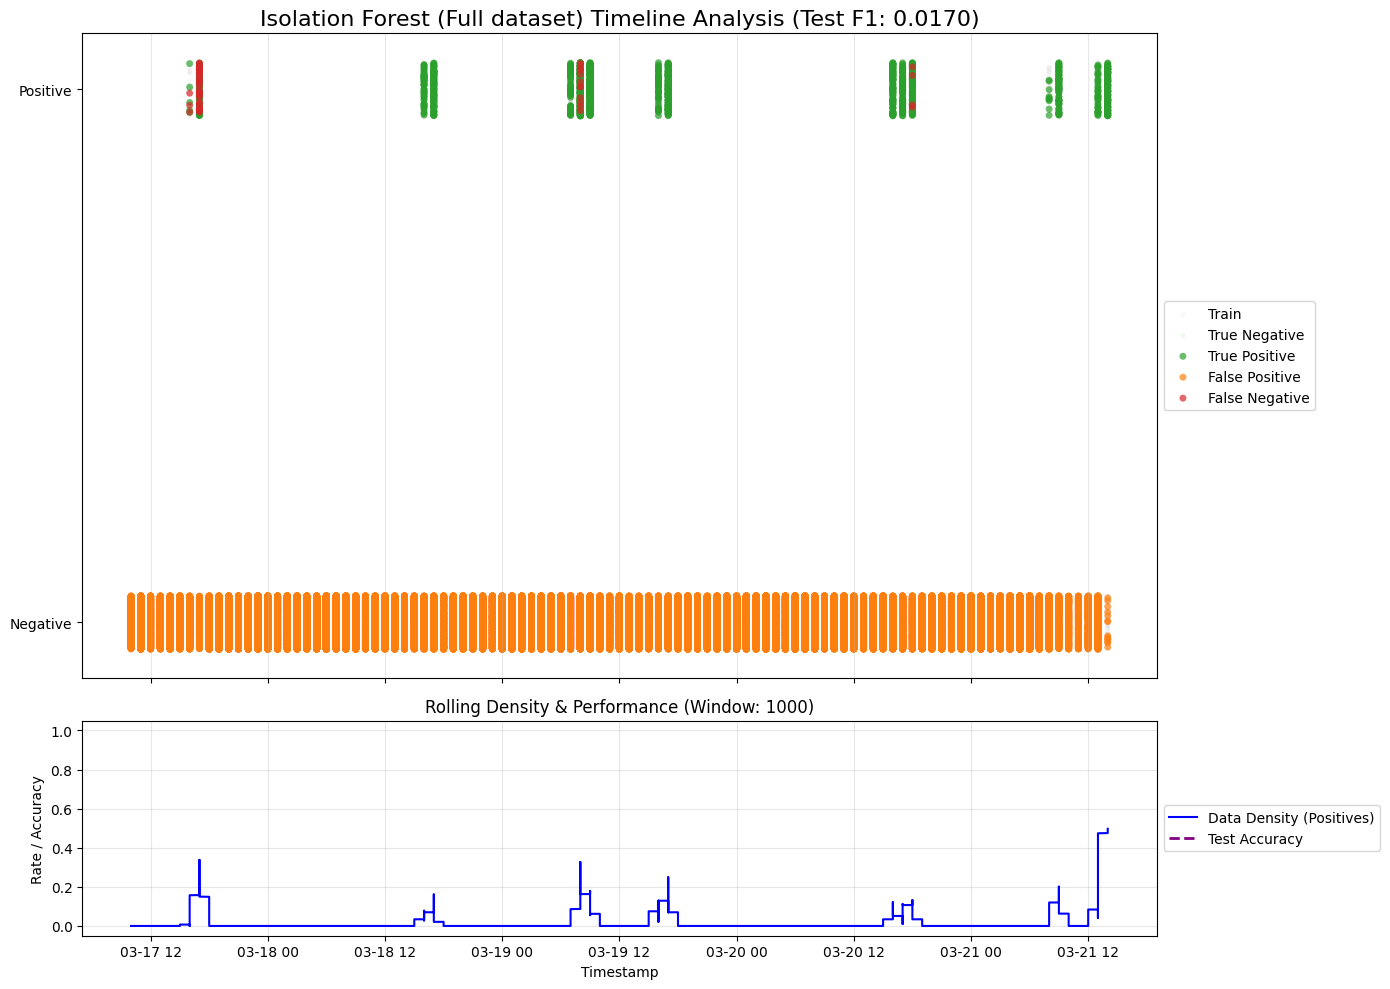

Simulation  - P: 0.013, R: 0.031, F1: 0.019

--- Contamination = 0.03 ---
Test anomaly detection rate: 3.0%


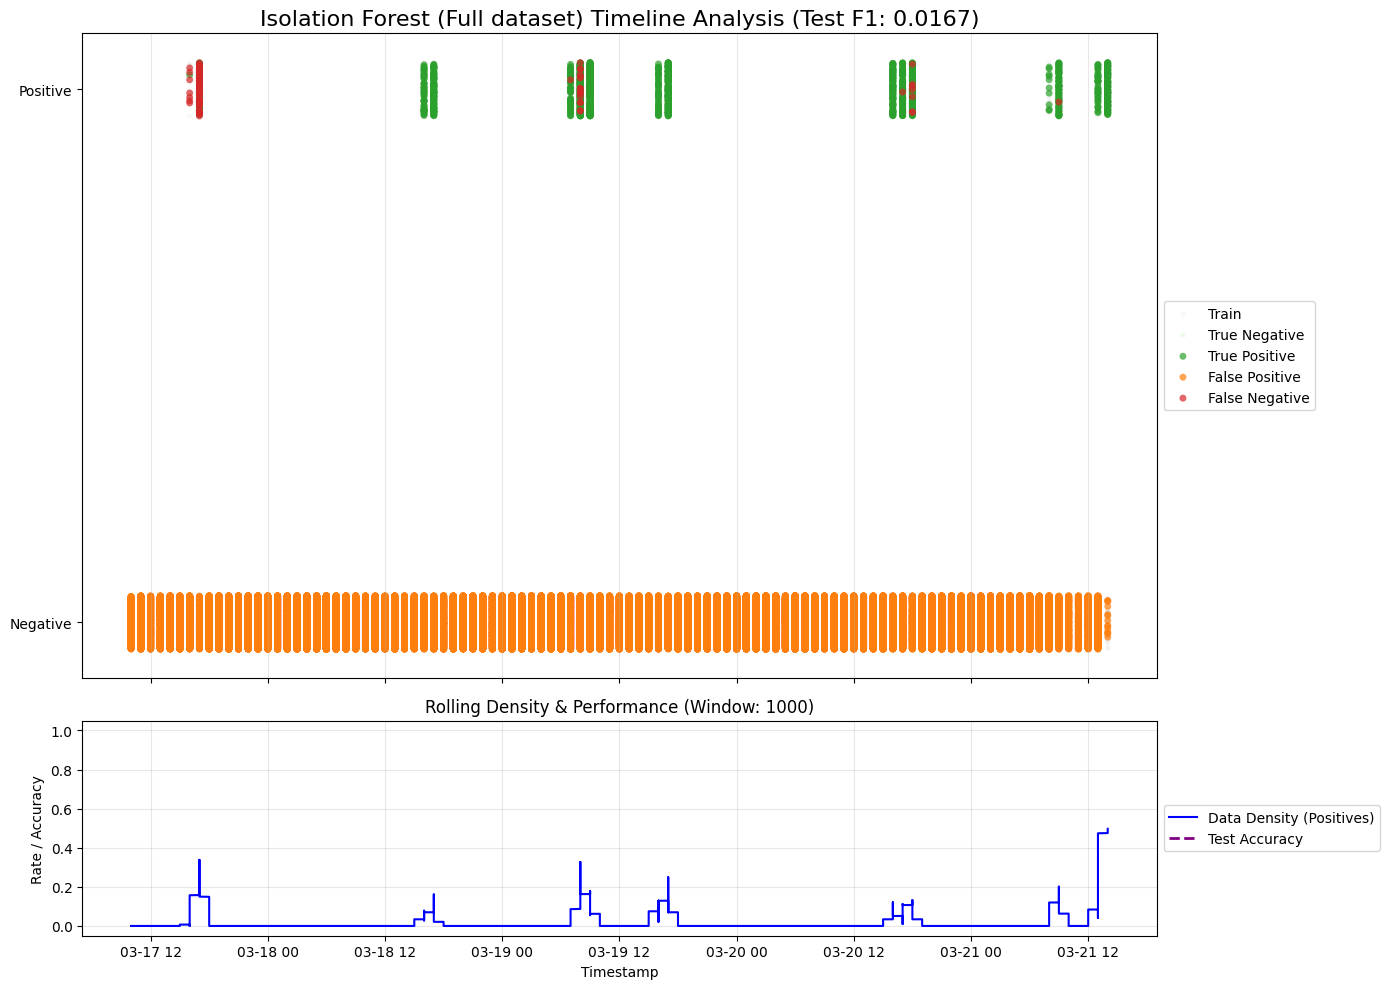

Simulation  - P: 0.016, R: 0.054, F1: 0.024

--- Contamination = 0.05 ---
Test anomaly detection rate: 5.0%


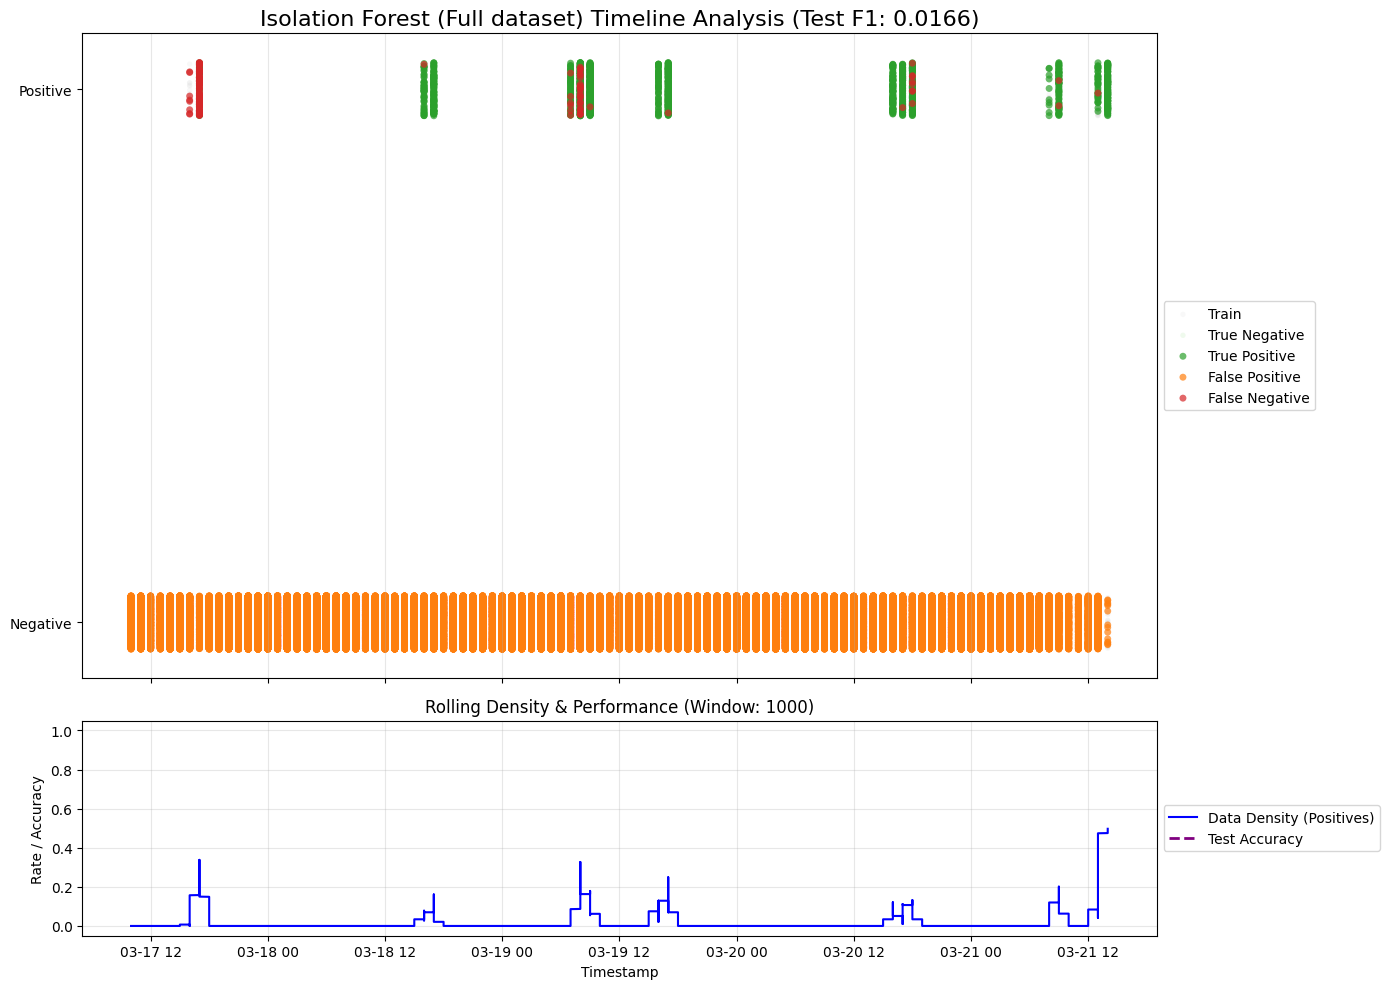

Simulation  - P: 0.014, R: 0.083, F1: 0.025

--- Contamination = 0.08 ---
Test anomaly detection rate: 8.0%


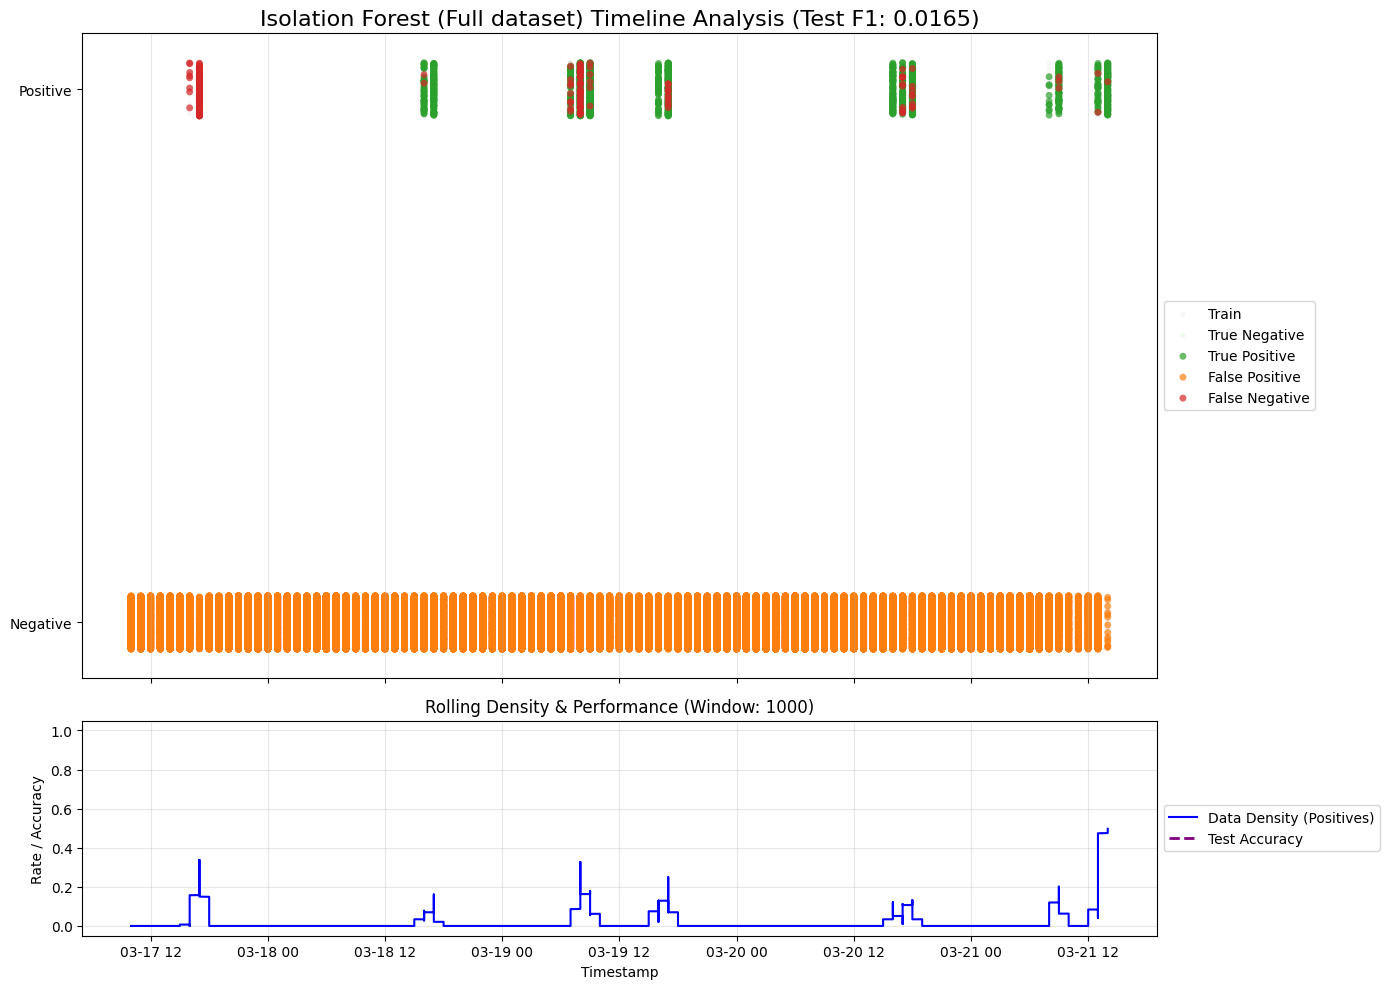

Simulation  - P: 0.012, R: 0.113, F1: 0.022

--- Contamination = auto ---
Test anomaly detection rate: 9.0%


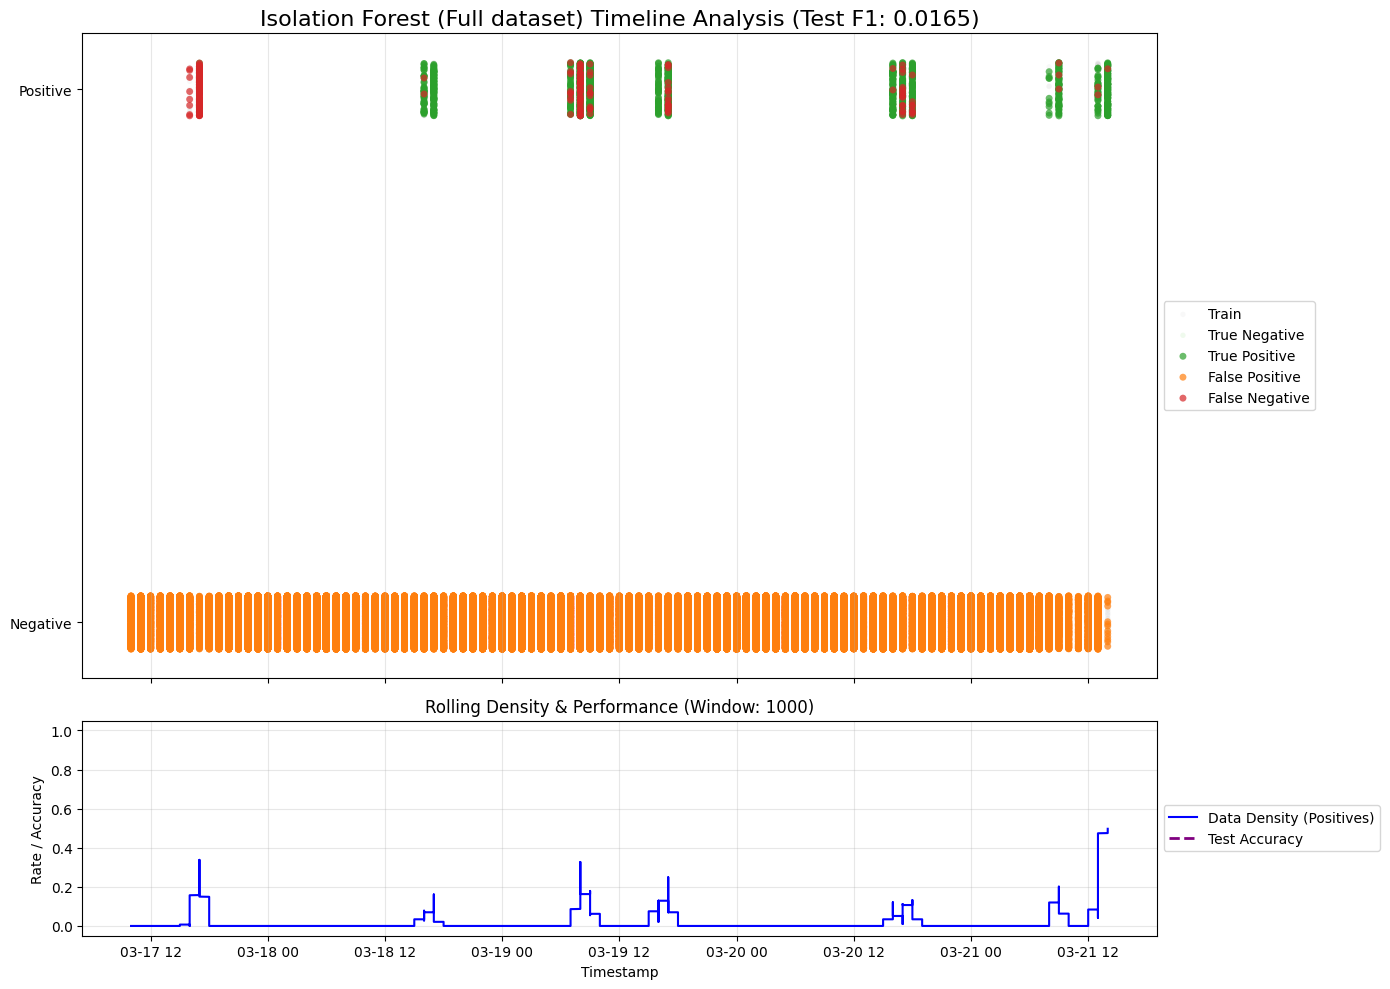

Simulation  - P: 0.012, R: 0.125, F1: 0.022

SUMMARY TABLE:
  contamination  anomaly_rate  sim_precision  sim_recall  sim_f1
0          0.02          0.02          0.013       0.031   0.019
1          0.03          0.03          0.016       0.054   0.024
2          0.05          0.05          0.014       0.083   0.025
3          0.08          0.08          0.012       0.113   0.022
4          auto          0.09          0.012       0.125   0.022

Best for Simulation F1: contamination = 0.05 (F1 = 0.025)


In [ ]:
print("=" * 60)
print("CONTAMINATION PARAMETER TUNING - Dataset A (with train/test split)")
print("=" * 60)

from sklearn.model_selection import train_test_split

X_B_train, X_B_test, y_sim_train, y_sim_test = train_test_split(
    X_B_scaled, df_B['is_simulation'],
    test_size=0.3, random_state=42, stratify=df_B['is_simulation']
)

print(f"Train size: {len(X_B_train)}, Test size: {len(X_B_test)}")
print(f"Train sim rate: {y_sim_train.mean():.2%}, Test sim rate: {y_sim_test.mean():.2%}")

contamination_levels = [0.02, 0.03, 0.05, 0.08, 'auto']
results = []

for contamination in contamination_levels:
    print(f"\n--- Contamination = {contamination} ---")

    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100
    )

    iso_forest.fit(X_B_train)
    anomalies_test = iso_forest.predict(X_B_test)
    anomalies_binary_test = (anomalies_test == 1).astype(int)

    anomaly_rate = np.mean(anomalies_test == -1)
    print(f"Test anomaly detection rate: {anomaly_rate:.1%}")

    from sklearn.metrics import precision_score, recall_score, f1_score

    sim_precision = precision_score(y_sim_test, 1-anomalies_binary_test)
    sim_recall = recall_score(y_sim_test, 1-anomalies_binary_test)
    sim_f1 = f1_score(y_sim_test, 1-anomalies_binary_test)

    visualize_model_performance(
      df=df_B,              # The original dataframe (for timestamps)
      y_train=y_sim_train,    # The training labels with indices
      y_test=y_sim_test,      # The test labels with indices
      y_pred=anomalies_binary_test,  # The predictions you just generated
      model_name="Isolation Forest (Full dataset)"
    )

    print(f"Simulation  - P: {sim_precision:.3f}, R: {sim_recall:.3f}, F1: {sim_f1:.3f}")

    results.append({
        'contamination': contamination,
        'anomaly_rate': anomaly_rate,
        'sim_precision': sim_precision,
        'sim_recall': sim_recall,
        'sim_f1': sim_f1
    })

results_df = pd.DataFrame(results)
print(f"\n" + "="*80)
print("SUMMARY TABLE:")
print("="*80)
print(results_df.round(3))

best_sim_f1 = results_df.loc[results_df['sim_f1'].idxmax()]

print(f"\nBest for Simulation F1: contamination = {best_sim_f1['contamination']} (F1 = {best_sim_f1['sim_f1']:.3f})")

In [ ]:
# --- 1. Define Devices and Features ---
audio_moths = [
    'Audio_Moth_1', 'Audio_Moth_2', 'Audio_Moth_3',
    'Audio_Moth_4', 'Audio_Moth_5', 'Audio_Moth_6'
]
DEVICE_COLUMN = 'recorder_id'

FEATURE_COLUMNS = core_features
TARGET_COLUMN = 'is_simulation'
# ----------------------------------------


# Store results for each moth
all_results = []

# --- 2. Loop Through Each Audio Moth ---

for moth_name in audio_moths:
    print(f"\n" + "="*60)
    print(f"Processing Model for: {moth_name}")
    print("="*60)

    # Filter the DataFrame for *only* this moth's data
    moth_df = df[df[DEVICE_COLUMN] == moth_name].copy()

    if moth_df.empty:
        print(f"No data found for {moth_name}. Skipping.")
        continue

    # Select features (X) and target (y) for this moth
    X_moth = moth_df[FEATURE_COLUMNS]
    y_moth = moth_df[TARGET_COLUMN]

    if X_moth.shape[0] < 10: # Check for minimum data
        print(f"Insufficient data for {moth_name} (found {X_moth.shape[0]} rows). Skipping.")
        continue

    # --- 3. Scale and Split Data (INSIDE the loop) ---
    # Scale features for this moth
    scaler = StandardScaler()
    X_moth_scaled = scaler.fit_transform(X_moth)

    # Check if stratification is possible (i.e., have both classes)
    if y_moth.nunique() < 2:
        print(f"Warning: Only one class present for {moth_name}. Splitting without stratification.")
        stratify_param = None
    else:
        stratify_param = y_moth

    # Split the data for this moth
    X_train, X_test, y_train, y_test = train_test_split(
        X_moth_scaled, y_moth,
        test_size=0.3,
        random_state=42,
        stratify=stratify_param
    )

    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Test sim rate: {y_test.mean():.2%}")

    # --- 4. Train and Evaluate Isolation Forest ---

    # **IMPORTANT**: You may need to tune 'contamination' for each moth.
    contamination_level = y_test.mean()
    if contamination_level == 0:
        contamination_level = 'auto' # Handle case with no simulations in test

    print(f"Using contamination: {contamination_level:.3f}")

    iso_forest = IsolationForest(
        contamination=contamination_level,
        random_state=42,
        n_estimators=100
    )

    # Train on the training data
    iso_forest.fit(X_train)

    # Predict on the test data
    anomalies_test = iso_forest.predict(X_test)

    # Convert predictions: -1 (anomaly) -> 1, 1 (normal) -> 0
    y_pred = (anomalies_test == -1).astype(int)

    # Calculate metrics
    sim_precision = precision_score(y_test, y_pred, zero_division=0)
    sim_recall = recall_score(y_test, y_pred, zero_division=0)
    sim_f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n--- Results for {moth_name} ---")
    print(f"Simulation - Precision: {sim_precision:.3f}, Recall: {sim_recall:.3f}, F1: {sim_f1:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Store results
    all_results.append({
        'device': moth_name,
        'f1_score': sim_f1,
        'precision': sim_precision,
        'recall': sim_recall,
        'contamination': contamination_level,
        'test_size': len(y_test),
        'test_sim_rate': y_test.mean()
    })


# --- 5. Optional: Display Summary ---
print(f"\n" + "="*80)
print("SUMMARY OF ALL DEVICES")
print("="*80)

results_df = pd.DataFrame(all_results)
print(results_df.round(3))


Processing Model for: Audio_Moth_1
Train size: 232534, Test size: 99658
Train sim rate: 0.43%, Test sim rate: 0.43%
Using contamination: 0.004

--- Results for Audio_Moth_1 ---
Simulation - Precision: 0.002, Recall: 0.002, F1: 0.002
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     99225
           1       0.00      0.00      0.00       433

    accuracy                           0.99     99658
   macro avg       0.50      0.50      0.50     99658
weighted avg       0.99      0.99      0.99     99658


Processing Model for: Audio_Moth_2
Train size: 121054, Test size: 51881
Train sim rate: 0.86%, Test sim rate: 0.86%
Using contamination: 0.009

--- Results for Audio_Moth_2 ---
Simulation - Precision: 0.000, Recall: 0.000, F1: 0.000
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     51436
           1       0.00      0.00      0.00       445

    accuracy                           0.

--- Pre-processing data for all devices ---
  -> Stored data for Audio_Moth_1 (Train: 232534, Test: 99658)
  -> Stored data for Audio_Moth_2 (Train: 121054, Test: 51881)
  -> Stored data for Audio_Moth_3 (Train: 12642, Test: 5418)
  -> Stored data for Audio_Moth_4 (Train: 36333, Test: 15572)
  -> Stored data for Audio_Moth_5 (Train: 67487, Test: 28924)
  -> Stored data for Audio_Moth_6 (Train: 68503, Test: 29359)
--- Data pre-processing complete ---

TRAINING Model on: Audio_Moth_1
Using contamination = 0.004
--- Testing 'Audio_Moth_1' model on all devices: ---
  -> TESTED on Audio_Moth_1: F1 = 0.002 (P: 0.002, R: 0.002)
  -> TESTED on Audio_Moth_2: F1 = 0.006 (P: 0.007, R: 0.004)
  -> TESTED on Audio_Moth_3: F1 = 0.000 (P: 0.000, R: 0.000)
  -> TESTED on Audio_Moth_4: F1 = 0.012 (P: 0.024, R: 0.008)
  -> TESTED on Audio_Moth_5: F1 = 0.112 (P: 0.456, R: 0.064)
  -> TESTED on Audio_Moth_6: F1 = 0.013 (P: 0.020, R: 0.010)

TRAINING Model on: Audio_Moth_2
Using contamination = 0.009
--- T

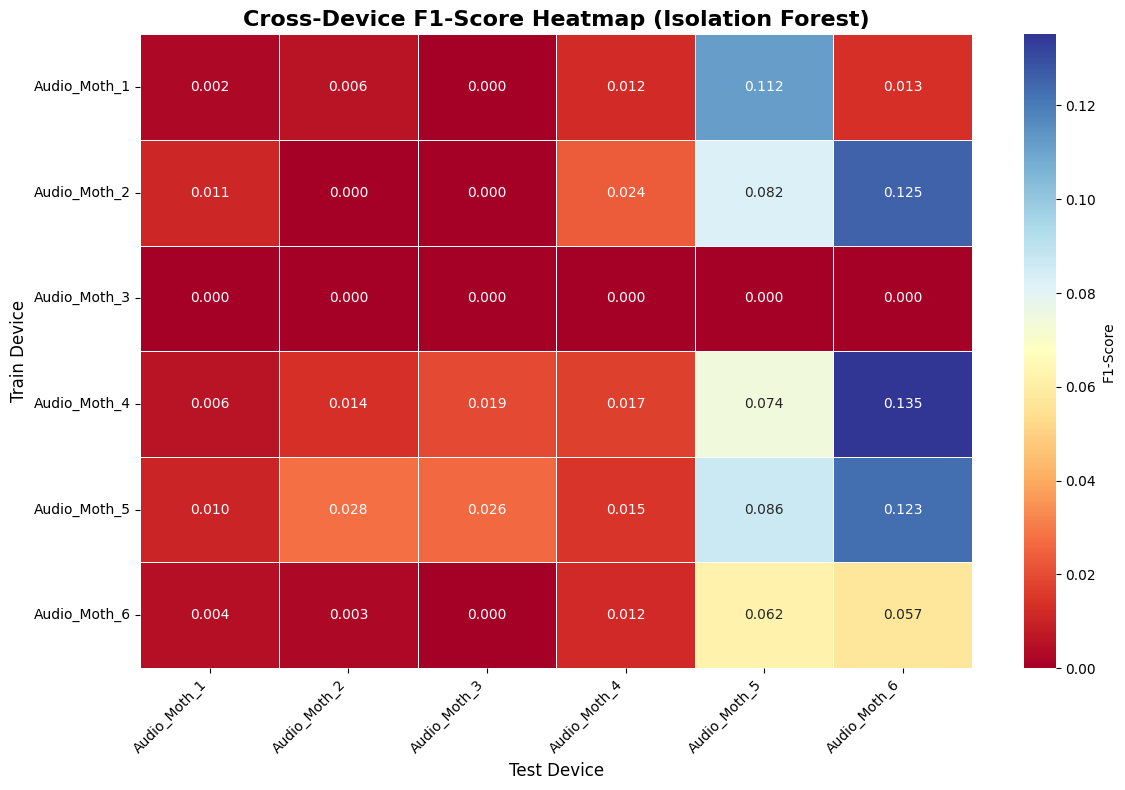

In [ ]:
# --- 1. Define Devices and Features ---
audio_moths = [
    'Audio_Moth_1', 'Audio_Moth_2', 'Audio_Moth_3',
    'Audio_Moth_4', 'Audio_Moth_5', 'Audio_Moth_6'
]
DEVICE_COLUMN = 'recorder_id'
FEATURE_COLUMNS = core_features
TARGET_COLUMN = 'is_simulation'

# --- 2. Helper Function to Get Data ---
# (This function isolates the data prep logic)

def get_device_data(df, device_name, device_col, feature_cols, target_col, test_size=0.3, random_state=42):
    """
    Filters, scales, and splits data for a single device.
    """
    moth_df = df[df[device_col] == device_name].copy()

    if moth_df.empty:
        return None, None, None, None # Return None if no data

    X_moth = moth_df[feature_cols]
    y_moth = moth_df[target_col]

    if X_moth.shape[0] < 10: # Check for minimum data
        return None, None, None, None

    stratify_param = y_moth if y_moth.nunique() > 1 else None

    # We must scale the data first *before* splitting
    # The scaler is fit on ALL data for this device
    scaler = StandardScaler()
    X_moth_scaled = scaler.fit_transform(X_moth)

    X_train, X_test, y_train, y_test = train_test_split(
        X_moth_scaled, y_moth,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_param
    )

    # Return all 4 components
    return X_train, X_test, y_train, y_test

# --- 3. Pre-process and Cache Data for All Devices ---

data_bundles = {}
print("--- Pre-processing data for all devices ---")
for moth_name in audio_moths:
    data_pack = get_device_data(
        df, moth_name, DEVICE_COLUMN, FEATURE_COLUMNS, TARGET_COLUMN
    )

    # Store the (X_train, X_test, y_train, y_test) tuple
    data_bundles[moth_name] = data_pack

    if data_pack[0] is not None:
        print(f"  -> Stored data for {moth_name} (Train: {len(data_pack[0])}, Test: {len(data_pack[1])})")
    else:
        print(f"  -> No/Insufficient data for {moth_name}")
print("--- Data pre-processing complete ---")


# --- 4. Main Nested Loop for Cross-Device Testing ---

all_cross_device_results = []

# --- Outer Loop: TRAIN on this device ---
for train_moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"TRAINING Model on: {train_moth_name}")
    print("="*80)

    # Get the training data for this moth
    # We also grab its y_test to calculate contamination
    X_train, _, y_train, y_test_for_contamination = data_bundles[train_moth_name]

    # --- Check if training is possible ---
    if X_train is None:
        print(f"Skipping training for {train_moth_name}: Insufficient data.")
        continue

    # Use the simulation rate from the moth's OWN test set to set contamination
    contamination_level = 'auto'
    if y_test_for_contamination is not None and y_test_for_contamination.mean() > 0:
         contamination_level = y_test_for_contamination.mean()

    print(f"Using contamination = {contamination_level if isinstance(contamination_level, str) else contamination_level:.3f}")

    # --- Train the Isolation Forest Model ---
    iso_forest = IsolationForest(
        contamination=contamination_level,
        random_state=42,
        n_estimators=100
    )
    iso_forest.fit(X_train) # Train the model

    # --- Inner Loop: TEST on this device ---
    print(f"--- Testing '{train_moth_name}' model on all devices: ---")
    for test_moth_name in audio_moths:

        # Get the TEST data for the inner moth
        # We only need X_test and y_test from this bundle
        _, X_test, _, y_test = data_bundles[test_moth_name]

        # --- Check if testing is possible ---
        if X_test is None or y_test is None:
            print(f"  -> Skipping test on {test_moth_name}: Insufficient test data.")
            continue

        # Check if test set has labels to compare against
        if y_test.nunique() < 2:
            print(f"  -> Skipping test on {test_moth_name}: Test data has only one class.")
            continue

        # --- Test and Evaluate ---
        anomalies_test = iso_forest.predict(X_test)
        y_pred = (anomalies_test == -1).astype(int)

        sim_f1 = f1_score(y_test, y_pred, zero_division=0)
        sim_precision = precision_score(y_test, y_pred, zero_division=0)
        sim_recall = recall_score(y_test, y_pred, zero_division=0)

        print(f"  -> TESTED on {test_moth_name}: F1 = {sim_f1:.3f} (P: {sim_precision:.3f}, R: {sim_recall:.3f})")

        # Store this cross-device result
        all_cross_device_results.append({
            'train_device': train_moth_name,
            'test_device': test_moth_name,
            'f1_score': sim_f1,
            'precision': sim_precision,
            'recall': sim_recall
        })

# --- 5. Final Summary ---
print(f"\n" + "="*80)
print("SUMMARY OF CROSS-DEVICE VALIDATION")
print("="*80)

results_df = pd.DataFrame(all_cross_device_results)

# A pivot table is the best way to view this
print("--- F1-Score Heatmap (Train device = rows, Test device = columns) ---")
f1_pivot = results_df.pivot(
    index='train_device',
    columns='test_device',
    values='f1_score'
)
print(f1_pivot.round(3))

# Set the figure size
plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(
    f1_pivot,          # Your DataFrame
    annot=True,        # Show the F1-score numbers in each cell
    fmt=".3f",         # Format the numbers to 3 decimal places
    cmap="RdYlBu",     # Color map: Red (high/good) to Blue (low/bad)
    linewidths=.5,     # Add thin lines between cells
    cbar=True,         # Show the color bar
    cbar_kws={'label': 'F1-Score'} # Add a label to the color bar
)

# Add titles and labels
plt.title('Cross-Device F1-Score Heatmap (Isolation Forest)', fontsize=16, weight='bold')
plt.xlabel('Test Device', fontsize=12)
plt.ylabel('Train Device', fontsize=12)
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability

# Ensure the plot is not cut off
plt.tight_layout()

# Save the plot as an image and display it
plt.savefig('cross_device_f1_heatmap.png')
plt.show()

#### Per-device validation

In [ ]:
# --- 1. Define Features and Device Info ---



DEVICE_COLUMN = 'recorder_id' # The column in 'df' with the moth names
FEATURE_COLUMNS = core_features
TARGET_COLUMN = 'is_simulation'

# --- 2. Prepare Data ---
print(f"Using {len(FEATURE_COLUMNS)} core features.")
X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

# Split the unscaled data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Full train set: {len(X_train)} rows")
print(f"Full test set: {len(X_test)} rows")

# --- 3. (NEW) Get a DataFrame of the Test Set ---
# We use the index from X_test to get the original rows from df.
df_test = df.loc[X_test.index].copy()

# --- 4. Scale Data ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 5. Contamination Tuning Loop
print(f"\n" + "="*80)
print("CONTAMINATION PARAMETER TUNING")
print("="*80)

contamination_levels = [0.02, 0.03, 0.05, 0.08, 'auto']
results = []

for contamination in contamination_levels:
    print(f"\n--- Contamination = {contamination} ---")

    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100
    )

    # Train on the training data
    iso_forest.fit(X_train_scaled)

    # Predict on the test data
    anomalies_test = iso_forest.predict(X_test_scaled)

    # Convert predictions: -1 (anomaly) -> 1, 1 (normal) -> 0
    y_pred = (anomalies_test == -1).astype(int)

    # Calculate metrics
    sim_precision = precision_score(y_test, y_pred, zero_division=0)
    sim_recall = recall_score(y_test, y_pred, zero_division=0)
    sim_f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"Simulation  - P: {sim_precision:.3f}, R: {sim_recall:.3f}, F1: {sim_f1:.3f}")

    results.append({
        'contamination': contamination,
        'sim_f1': sim_f1,
        'sim_precision': sim_precision,
        'sim_recall': sim_recall
    })

# --- 6. Find Best Model and Get Final Predictions ---
results_df = pd.DataFrame(results)
print(f"\n" + "="*80)
print("SUMMARY TABLE:")
print(results_df.round(3))

# Find the contamination level that gave the best F1 score
best_result = results_df.loc[results_df['sim_f1'].idxmax()]
best_contamination = best_result['contamination']

print(f"\nBest for Simulation F1: contamination = {best_contamination} (F1 = {best_result['sim_f1']:.3f})")

# --- Train the final, best model ---
print("\n--- Training final model with best contamination ---")
final_iso_forest = IsolationForest(
    contamination=best_contamination,
    random_state=42,
    n_estimators=100
)
final_iso_forest.fit(X_train_scaled)

# Get final predictions for the entire test set
final_anomalies = final_iso_forest.predict(X_test_scaled)
y_pred_final = (final_anomalies == -1).astype(int)


# --- 7. Per-Device Evaluation Loop ---
print(f"\n" + "="*80)
print("PER-DEVICE PERFORMANCE BREAKDOWN (ON TEST SET)")
print("="*80)

# Add the final predictions to our test DataFrame
df_test['y_pred_final'] = y_pred_final

per_device_results = []

for moth_name in audio_moths:
    # Filter the test set for *only* this moth's data
    moth_test_df = df_test[df_test[DEVICE_COLUMN] == moth_name]

    if moth_test_df.empty:
        print(f"\n--- {moth_name} ---")
        print("No test data available for this device.")
        continue

    # Get the true labels and predicted labels for this device
    y_true_device = moth_test_df['is_simulation']
    y_pred_device = moth_test_df['y_pred_final']

    # Calculate metrics
    f1 = f1_score(y_true_device, y_pred_device, zero_division=0)
    precision = precision_score(y_true_device, y_pred_device, zero_division=0)
    recall = recall_score(y_true_device, y_pred_device, zero_division=0)

    print(f"\n--- {moth_name} (Test Samples: {len(y_true_device)}) ---")
    print(f"F1: {f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")

    per_device_results.append({
        'device': moth_name,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'test_samples': len(y_true_device)
    })

# --- 8. Final Summary Table ---
print(f"\n" + "="*80)
print("Per-Device Performance Summary")
print("="*80)
summary_df = pd.DataFrame(per_device_results)
print(summary_df.round(3))

Using 10 core features.
Full train set: 538555 rows
Full test set: 230810 rows

CONTAMINATION PARAMETER TUNING

--- Contamination = 0.02 ---
Simulation  - P: 0.013, R: 0.031, F1: 0.019

--- Contamination = 0.03 ---
Simulation  - P: 0.016, R: 0.054, F1: 0.024

--- Contamination = 0.05 ---
Simulation  - P: 0.014, R: 0.083, F1: 0.025

--- Contamination = 0.08 ---
Simulation  - P: 0.012, R: 0.113, F1: 0.022

--- Contamination = auto ---
Simulation  - P: 0.012, R: 0.125, F1: 0.022

SUMMARY TABLE:
  contamination  sim_f1  sim_precision  sim_recall
0          0.02   0.019          0.013       0.031
1          0.03   0.024          0.016       0.054
2          0.05   0.025          0.014       0.083
3          0.08   0.022          0.012       0.113
4          auto   0.022          0.012       0.125

Best for Simulation F1: contamination = 0.05 (F1 = 0.025)

--- Training final model with best contamination ---

PER-DEVICE PERFORMANCE BREAKDOWN (ON TEST SET)

--- Audio_Moth_1 (Test Samples: 999

#### LODO(Leave-one-device-out) Validation

In [ ]:
# --- 1. Define Features and Device Info ---


DEVICE_COLUMN = 'recorder_id' # The column in 'df' with the moth names
TARGET_COLUMN = 'is_simulation'
FEATURES_TO_USE = core_features # Use the core_features list

# Identify which features to scale
features_to_scale = [f for f in FEATURES_TO_USE if not f.startswith('is_')]

# --- 2. Main LODO Cross-Validation Loop ---
all_lodo_results = []
print("--- Starting Leave-One-Device-Out (LODO) Validation for Isolation Forest ---")

for test_moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"HOLDING OUT (Test Set): {test_moth_name}")
    print(f"TRAINING on all other 5 devices")
    print("="*80)

    # --- Create Train/Test splits based on device ---
    train_df = df[df[DEVICE_COLUMN] != test_moth_name].copy()
    test_df = df[df[DEVICE_COLUMN] == test_moth_name].copy()

    # --- Check for valid data ---
    if test_df.empty:
        print(f"Skipping {test_moth_name}: No test data found for this device.")
        continue
    if train_df.empty:
        print(f"Skipping {test_moth_name}: No training data available.")
        continue

    # --- Separate Features and Target ---
    X_train_raw = train_df[FEATURES_TO_USE]
    y_train = train_df[TARGET_COLUMN]
    X_test_raw = test_df[FEATURES_TO_USE]
    y_test = test_df[TARGET_COLUMN]

    # Check for labels in test set
    if y_test.nunique() < 2:
        print(f"Skipping {test_moth_name}: Test data has only one class (cannot evaluate F1).")
        continue

    print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Test sim rate: {y_test.mean():.2%}")

    # --- Scale Data (Fit on Train, Transform Test) ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    # --- Set Contamination based on TRAINING data ---
    contamination_level = y_train.mean()
    if contamination_level == 0:
        print("Warning: No positive samples in training set. Using 'auto' contamination.")
        contamination_level = 'auto'

    print(f"Using contamination (from train set): {contamination_level if isinstance(contamination_level, str) else contamination_level:.3f}")

    # --- Train Isolation Forest Model ---
    iso_forest = IsolationForest(
        contamination=contamination_level,
        random_state=42,
        n_estimators=100
    )

    # Isolation Forest trains ONLY on features (unsupervised)
    iso_forest.fit(X_train_scaled)

    # --- Evaluate on Hold-Out Device ---
    anomalies_test = iso_forest.predict(X_test_scaled)

    # Convert predictions: -1 (anomaly) -> 1, 1 (normal) -> 0
    y_pred_final = (anomalies_test == -1).astype(int)

    # Calculate metrics (no thresholding needed)
    f1 = f1_score(y_test, y_pred_final, zero_division=0)
    precision = precision_score(y_test, y_pred_final, zero_division=0)
    recall = recall_score(y_test, y_pred_final, zero_division=0)

    print(f"\n--- Results for held-out {test_moth_name} ---")
    print(f"F1: {f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")

    # Store results
    all_lodo_results.append({
        'held_out_device': test_moth_name,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'test_samples': len(y_test)
    })

# --- 3. Final LODO Summary ---
print(f"\n" + "="*80)
print("LODO VALIDATION SUMMARY (Isolation Forest)")
print("="*80)

summary_df = pd.DataFrame(all_lodo_results)
print(summary_df.round(3))

print(f"\n" + "="*80)
print("Average LODO Performance")
print("="*80)
metrics_mean = summary_df.drop(columns=['held_out_device']).mean()
print(metrics_mean.round(3))

--- Starting Leave-One-Device-Out (LODO) Validation for Isolation Forest ---

HOLDING OUT (Test Set): Audio_Moth_1
TRAINING on all other 5 devices
Train size: 437173, Test size: 332192
Train sim rate: 1.19%, Test sim rate: 0.43%
Using contamination (from train set): 0.012

--- Results for held-out Audio_Moth_1 ---
F1: 0.000, Precision: 0.000, Recall: 0.000

HOLDING OUT (Test Set): Audio_Moth_2
TRAINING on all other 5 devices
Train size: 596430, Test size: 172935
Train sim rate: 0.87%, Test sim rate: 0.86%
Using contamination (from train set): 0.009

--- Results for held-out Audio_Moth_2 ---
F1: 0.000, Precision: 0.000, Recall: 0.000

HOLDING OUT (Test Set): Audio_Moth_3
TRAINING on all other 5 devices
Train size: 751305, Test size: 18060
Train sim rate: 0.88%, Test sim rate: 0.19%
Using contamination (from train set): 0.009

--- Results for held-out Audio_Moth_3 ---
F1: 0.000, Precision: 0.000, Recall: 0.000

HOLDING OUT (Test Set): Audio_Moth_4
TRAINING on all other 5 devices
Train si

## XGBoosting

In [ ]:


    xgb_model = xgb.XGBClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=20,
        eval_metric='logloss',
        reg_alpha=1,
        reg_lambda=1
    )

    xgb_model.fit(X_train_scaled, y_train)
    y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

    print(f"XGBoost ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
    from sklearn.metrics import precision_score, recall_score, f1_score

    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1 = 0
    best_threshold = 0.5
    results = []

    for thresh in thresholds:
        y_pred_thresh = (y_pred_proba_xgb >= thresh).astype(int)
        precision = precision_score(y_test, y_pred_thresh)
        recall = recall_score(y_test, y_pred_thresh)
        f1 = f1_score(y_test, y_pred_thresh)

        results.append([thresh, precision, recall, f1])
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh

    results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])
    print(f"\nBest threshold: {best_threshold:.2f} with F1: {best_f1:.3f}")

    print("\nTop 5 thresholds by F1 score:")
    print(results_df.nlargest(5, 'F1')[['Threshold', 'Precision', 'Recall', 'F1']].round(3))

    y_pred_xgb = (y_pred_proba_xgb >= best_threshold).astype(int)
    print(f"\nFinal XGBoost Results (threshold={best_threshold:.2f}):")
    print(classification_report(y_test, y_pred_xgb))

    precision_recall_balance = results_df.copy()
    precision_recall_balance['PR_diff'] = abs(precision_recall_balance['Precision'] - precision_recall_balance['Recall'])
    best_balanced_idx = precision_recall_balance.loc[precision_recall_balance['F1'] > 0.08].nsmallest(1, 'PR_diff').index[0]
    balanced_threshold = precision_recall_balance.loc[best_balanced_idx, 'Threshold']

    y_pred_balanced = (y_pred_proba_xgb >= balanced_threshold).astype(int)
    print(f"\nBalanced Precision-Recall Results (threshold={balanced_threshold:.2f}):")
    print(classification_report(y_test, y_pred_balanced))


XGBoost ROC-AUC: 0.7708

Best threshold: 0.35 with F1: 0.076

Top 5 thresholds by F1 score:
   Threshold  Precision  Recall     F1
5       0.35      0.049   0.169  0.076
6       0.40      0.056   0.112  0.075
4       0.30      0.043   0.247  0.073
3       0.25      0.040   0.346  0.072
7       0.45      0.073   0.070  0.071

Final XGBoost Results (threshold=0.35):
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     96189
           1       0.05      0.17      0.08      1673

    accuracy                           0.93     97862
   macro avg       0.52      0.56      0.52     97862
weighted avg       0.97      0.93      0.95     97862



IndexError: index 0 is out of bounds for axis 0 with size 0

## LightGBM

In [ ]:
# LightGBM model
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    reg_alpha=1,
    reg_lambda=1,
    verbose=-1
)

lgb_model.fit(X_train_scaled, y_train)
y_pred_proba_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]

print(f"LightGBM ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lgb):.4f}")

# Best threshold by F1
thresholds = np.arange(0.1, 0.8, 0.05)
best_f1_lgb = 0
best_thresh_lgb = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_lgb >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1_lgb:
        best_f1_lgb = f1
        best_thresh_lgb = thresh

y_pred_lgb = (y_pred_proba_lgb >= best_thresh_lgb).astype(int)
print(f"Best threshold: {best_thresh_lgb:.2f}, F1: {best_f1_lgb:.3f}")
print(classification_report(y_test, y_pred_lgb))

visualize_model_performance(
    df=df,              # The original dataframe (for timestamps)
    y_train=y_train,    # The training labels with indices
    y_test=y_test,      # The test labels with indices
    y_pred=y_pred,  # The predictions you just generated
    model_name="LightGBM"
)

In [ ]:

core_features = [
    'RMS Energy', 'Spectral Contrast', 'Spectral Flatness',
    'Spectral Bandwidth', 'Spectral Rolloff (85%)',
    'Onset Strength', 'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13'
]

# Set this to the feature list you want to use
FEATURE_COLUMNS = core_features

# Define your devices and data columns

DEVICE_COLUMN = 'recorder_id'     # The column in 'df' with the moth names
TARGET_COLUMN = 'is_simulation' # The column in 'df' with the 0/1 target

# --- 2. Helper Functions ---

def get_device_data(df, device_name, device_col, feature_cols, target_col, test_size=0.3, random_state=42):
    """
    Filters, scales, and splits data for a single device.
    """
    # Filter the DataFrame
    device_df = df[df[device_col] == device_name].copy()

    if device_df.empty:
        print(f"No data found for {device_name}.")
        return None, None, None, None

    X_device = device_df[feature_cols]
    y_device = device_df[target_col]

    if X_device.shape[0] < 10: # Check for minimum data
        print(f"Insufficient data for {device_name} (found {X_device.shape[0]} rows).")
        return None, None, None, None

    # Check for stratification
    stratify_param = y_device if y_device.nunique() > 1 else None
    if stratify_param is None:
        print(f"Warning: Only one class present for {device_name}. Splitting without stratification.")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X_device, y_device,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_param
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.8, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    (This function replaces the threshold loop from your code)
    """
    best_f1 = 0
    best_threshold = 0.5

    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh

    return best_f1, best_threshold

# --- 3. Main Loop to Run LightGBM ---

all_results = []

for moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"Processing LightGBM for: {moth_name}")
    print("="*80)

    # --- Get Data ---
    data_pack = get_device_data(
        df,
        moth_name,
        DEVICE_COLUMN,
        FEATURE_COLUMNS,
        TARGET_COLUMN
    )

    X_train_scaled, X_test_scaled, y_train, y_test = data_pack

    if X_train_scaled is None:
        print(f"Skipping {moth_name} due to insufficient data.")
        all_results.append({
            'device': moth_name, 'model': 'LightGBM', 'f1_score': None,
            'roc_auc': None, 'precision': None, 'recall': None
        })
        continue

    print(f"Data Prepared: Train size: {len(X_train_scaled)}, Test size: {len(X_test_scaled)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Test sim rate: {y_test.mean():.2%}")

    # --- Train LightGBM Model ---
    # (Using the exact parameters you provided)
    lgb_model = lgb.LGBMClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced', # This handles imbalance
        reg_alpha=1,
        reg_lambda=1,
        verbose=-1
    )

    lgb_model.fit(X_train_scaled, y_train)
    y_pred_proba_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]

    # --- Evaluate ---
    roc_auc = roc_auc_score(y_test, y_pred_proba_lgb)
    print(f"\nLightGBM ROC-AUC: {roc_auc:.4f}")

    # Find best threshold using the helper function
    best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba_lgb)

    print(f"Best threshold: {best_thresh:.2f}, F1: {best_f1:.3f}")

    # Get final predictions and classification report
    y_pred_lgb = (y_pred_proba_lgb >= best_thresh).astype(int)
    print(classification_report(y_test, y_pred_lgb, zero_division=0))

    print(f"--- Calculating Permutation Importance for {moth_name} ---")
    plot_permutation_importance(
        model=lgb_model,
        X_test=X_test_scaled,
        y_test=y_test,
        feature_names=FEATURE_COLUMNS, # This is your 'core_features' list
        title=f"Permutation Importance - LightGBM ({moth_name})"
    )

    # Store results
    precision = precision_score(y_test, y_pred_lgb, zero_division=0)
    recall = recall_score(y_test, y_pred_lgb, zero_division=0)

    all_results.append({
        'device': moth_name,
        'model': 'LightGBM',
        'f1_score': best_f1,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'best_threshold': best_thresh,
        'test_sim_rate': y_test.mean()
    })

# --- 4. Final Summary ---
print(f"\n" + "="*80)
print("FINAL SUMMARY FOR LIGHTGBM ACROSS ALL DEVICES")
print("="*80)

summary_df = pd.DataFrame(all_results)
print(summary_df.round(3))

In [ ]:
# --- 1. Define Your Devices and Features ---
core_features = [
    'RMS Energy', 'Spectral Contrast', 'Spectral Flatness',
    'Spectral Bandwidth', 'Spectral Rolloff (85%)',
    'Onset Strength', 'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13'
]

audio_moths = [
    'Audio_Moth_1', 'Audio_Moth_2', 'Audio_Moth_3',
    'Audio_Moth_4', 'Audio_Moth_5', 'Audio_Moth_6'
]

DEVICE_COLUMN = 'recorder_id'
FEATURE_COLUMNS = core_features
TARGET_COLUMN = 'is_simulation'

# --- 2. Helper Functions ---

def get_device_data_supervised(df, device_name, device_col, feature_cols, target_col, test_size=0.3, random_state=42):
    """
    Filters, splits, and scales data for a single device.
    **Crucially, scales *after* splitting to prevent data leakage.**
    """
    device_df = df[df[device_col] == device_name].copy()

    if device_df.empty: return None, None, None, None

    X_device = device_df[feature_cols]
    y_device = device_df[target_col]

    if X_device.shape[0] < 10: return None, None, None, None

    stratify_param = y_device if y_device.nunique() > 1 else None

    # Split the raw (unscaled) data first
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_device, y_device,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_param
    )

    # Now, fit the scaler ONLY on the training data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    # Transform the test data using the scaler fit on train
    X_test_scaled = scaler.transform(X_test_raw)

    return X_train_scaled, X_test_scaled, y_train, y_test

def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.8, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5
    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    return best_f1, best_threshold

# --- 3. Pre-process and Cache Data for All Devices ---

data_bundles = {}
print("--- Pre-processing data for all devices ---")
for moth_name in audio_moths:
    data_pack = get_device_data_supervised(
        df, moth_name, DEVICE_COLUMN, FEATURE_COLUMNS, TARGET_COLUMN
    )

    data_bundles[moth_name] = data_pack

    if data_pack[0] is not None:
        print(f"  -> Stored data for {moth_name} (Train: {len(data_pack[0])}, Test: {len(data_pack[1])})")
    else:
        print(f"  -> No/Insufficient data for {moth_name}")
print("--- Data pre-processing complete ---")


# --- 4. Main Nested Loop for Cross-Device Testing ---

all_cross_device_results = []

# --- Outer Loop: TRAIN on this device ---
for train_moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"TRAINING Model on: {train_moth_name}")
    print("="*80)

    # Get the training data for this moth
    X_train_scaled, _, y_train, _ = data_bundles[train_moth_name]

    # --- Check if training is possible ---
    if X_train_scaled is None:
        print(f"Skipping training for {train_moth_name}: Insufficient data.")
        continue

    if y_train.nunique() < 2:
        print(f"Skipping training for {train_moth_name}: Training data has only one class.")
        continue

    # --- Train the LightGBM Model ---
    lgb_model = lgb.LGBMClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced', # Handles imbalance
        reg_alpha=1,
        reg_lambda=1,
        verbose=-1
    )
    lgb_model.fit(X_train_scaled, y_train)

    # --- Inner Loop: TEST on this device ---
    print(f"--- Testing '{train_moth_name}' model on all devices: ---")
    for test_moth_name in audio_moths:

        # Get the TEST data for the inner moth
        _, X_test_scaled, _, y_test = data_bundles[test_moth_name]

        # --- Check if testing is possible ---
        if X_test_scaled is None or y_test is None:
            print(f"  -> Skipping test on {test_moth_name}: Insufficient test data.")
            continue

        if y_test.nunique() < 2:
            print(f"  -> Skipping test on {test_moth_name}: Test data has only one class.")
            continue

        # --- Test and Evaluate ---
        y_pred_proba = lgb_model.predict_proba(X_test_scaled)[:, 1]

        best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
        y_pred_final = (y_pred_proba >= best_thresh).astype(int)

        sim_precision = precision_score(y_test, y_pred_final, zero_division=0)
        sim_recall = recall_score(y_test, y_pred_final, zero_division=0)

        print(f"  -> TESTED on {test_moth_name}: F1 = {best_f1:.3f} (P: {sim_precision:.3f}, R: {sim_recall:.3f})")

        all_cross_device_results.append({
            'train_device': train_moth_name,
            'test_device': test_moth_name,
            'f1_score': best_f1,
            'precision': sim_precision,
            'recall': sim_recall
        })

# --- 5. Final Summary ---
print(f"\n" + "="*80)
print("SUMMARY OF CROSS-DEVICE VALIDATION (LightGBM)")
print("="*80)

results_df = pd.DataFrame(all_cross_device_results)

# A pivot table is the best way to view this
print("--- F1-Score Heatmap (Train device = rows, Test device = columns) ---")
f1_pivot_lgbm = results_df.pivot(
    index='train_device',
    columns='test_device',
    values='f1_score'
)
print(f1_pivot_lgbm.round(3))

# --- 6. Generate Heatmap Visualization ---
print("\n--- Generating Heatmap ---")
plt.figure(figsize=(12, 8))
sns.heatmap(
    f1_pivot_lgbm,
    annot=True,        # Show the F1-score numbers
    fmt=".3f",         # Format to 3 decimal places
    cmap="RdYlBu",     # Color map: Red (high/good) to Blue (low/bad)
    linewidths=.5,
    cbar_kws={'label': 'F1-Score'}
)
plt.title('Cross-Device F1-Score Heatmap (LightGBM)', fontsize=16, weight='bold')
plt.xlabel('Test Device', fontsize=12)
plt.ylabel('Train Device', fontsize=12)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cross_device_f1_heatmap_lgbm.png')
plt.show()

#### Per-device validation

In [ ]:

# --- 1. Define Features and Device Info ---




DEVICE_COLUMN = 'recorder_id' # The column in 'df' with the moth names

# --- 2. Prepare Data ---
print(f"Using {len(core_features)} core features.")
X = df[core_features].copy()
y = df['is_simulation'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Full train set: {len(X_train)} rows")
print(f"Full test set: {len(X_test)} rows")

# --- 3. (NEW) Get a DataFrame of the Test Set ---
# We use the index from X_test to get the original rows from df.
df_test = df.loc[X_test.index].copy()

# --- 4. Scale Data ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 5. Train LightGBM (Your Original Code) ---
print("\n--- Training LightGBM on all devices (core features) ---")
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    reg_alpha=1,
    reg_lambda=1,
    verbose=-1
)

lgb_model.fit(X_train_scaled, y_train)

# --- 6. Evaluate on ALL Test Data (Your Original Code) ---
y_pred_proba_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nLightGBM ROC-AUC (Overall): {roc_auc_score(y_test, y_pred_proba_lgb):.4f}")

# Best threshold by F1
thresholds = np.arange(0.1, 0.8, 0.05)
best_f1_lgb = 0
best_thresh_lgb = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_lgb >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    if f1 > best_f1_lgb:
        best_f1_lgb = f1
        best_thresh_lgb = thresh

y_pred_lgb = (y_pred_proba_lgb >= best_thresh_lgb).astype(int)
print(f"Best threshold (Overall): {best_thresh_lgb:.2f}, F1: {best_f1_lgb:.3f}")
print("\n--- Overall Test Set Performance (All Devices) ---")
print(classification_report(y_test, y_pred_lgb, zero_division=0))


# --- 7. (NEW) Per-Device Evaluation Loop ---
print(f"\n" + "="*80)
print("PER-DEVICE PERFORMANCE BREAKDOWN (ON TEST SET)")
print("="*80)

# Add the final predictions to our test DataFrame
# y_pred_lgb is a numpy array in the same order as df_test
df_test['y_pred_final'] = y_pred_lgb

per_device_results = []

for moth_name in audio_moths:
    # Filter the test set for *only* this moth's data
    moth_test_df = df_test[df_test[DEVICE_COLUMN] == moth_name]

    if moth_test_df.empty:
        print(f"\n--- {moth_name} ---")
        print("No test data available for this device.")
        continue

    # Get the true labels and predicted labels for this device
    y_true_device = moth_test_df['is_simulation']
    y_pred_device = moth_test_df['y_pred_final']

    # Calculate metrics
    f1 = f1_score(y_true_device, y_pred_device, zero_division=0)
    precision = precision_score(y_true_device, y_pred_device, zero_division=0)
    recall = recall_score(y_true_device, y_pred_device, zero_division=0)

    print(f"\n--- {moth_name} (Test Samples: {len(y_true_device)}) ---")
    print(f"F1: {f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")

    per_device_results.append({
        'device': moth_name,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'test_samples': len(y_true_device)
    })

# --- 8. (NEW) Final Summary Table ---
print(f"\n" + "="*80)
print("Per-Device Performance Summary")
print("="*80)
summary_df = pd.DataFrame(per_device_results)
print(summary_df.round(3))

#### LODO Validation

In [ ]:
# --- 1. Define Features and Device Info ---


DEVICE_COLUMN = 'recorder_id' # The column in 'df' with the moth names
TARGET_COLUMN = 'is_simulation'
FEATURES_TO_USE = core_features # Use the core_features list

# Identify which features to scale (all, in this case)
features_to_scale = [f for f in FEATURES_TO_USE if not f.startswith('is_')]

# --- 2. Helper Function ---
def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.8, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5
    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    return best_f1, best_threshold

# --- 3. Main LODO Cross-Validation Loop ---
all_lodo_results = []
print("--- Starting Leave-One-Device-Out (LODO) Validation for LightGBM ---")

for test_moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"HOLDING OUT (Test Set): {test_moth_name}")
    print(f"TRAINING on all other 5 devices")
    print("="*80)

    # --- Create Train/Test splits based on device ---
    # Use the full 'df' as the source
    train_df = df[df[DEVICE_COLUMN] != test_moth_name].copy()
    test_df = df[df[DEVICE_COLUMN] == test_moth_name].copy()

    # --- Check for valid data ---
    if test_df.empty:
        print(f"Skipping {test_moth_name}: No test data found for this device.")
        continue
    if train_df.empty:
        print(f"Skipping {test_moth_name}: No training data available.")
        continue

    # --- Separate Features and Target ---
    X_train_raw = train_df[FEATURES_TO_USE]
    y_train = train_df[TARGET_COLUMN]
    X_test_raw = test_df[FEATURES_TO_USE]
    y_test = test_df[TARGET_COLUMN]

    # Check for labels in train/test sets
    if y_train.nunique() < 2:
        print(f"Skipping {test_moth_name}: Training data has only one class.")
        continue
    if y_test.nunique() < 2:
        print(f"Skipping {test_moth_name}: Test data has only one class.")
        continue

    print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Test sim rate: {y_test.mean():.2%}")

    # --- Scale Data (Fit on Train, Transform Test) ---
    scaler = StandardScaler()

    X_train_scaled = X_train_raw.copy()
    X_test_scaled = X_test_raw.copy()

    # Note: LightGBM can handle unscaled data, but scaling is
    # standard practice and won't hurt.
    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train_raw[features_to_scale])
    X_test_scaled[features_to_scale] = scaler.transform(X_test_raw[features_to_scale])

    # --- Train LightGBM Model (from your code) ---
    lgb_model = lgb.LGBMClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced', # This handles imbalance
        reg_alpha=1,
        reg_lambda=1,
        verbose=-1
    )

    lgb_model.fit(X_train_scaled, y_train)

    # --- Evaluate on Hold-Out Device ---
    y_pred_proba = lgb_model.predict_proba(X_test_scaled)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
    y_pred_final = (y_pred_proba >= best_thresh).astype(int)

    precision = precision_score(y_test, y_pred_final, zero_division=0)
    recall = recall_score(y_test, y_pred_final, zero_division=0)

    print(f"\n--- Results for held-out {test_moth_name} ---")
    print(f"F1: {best_f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, ROC-AUC: {roc_auc:.3f}")

    # Store results
    all_lodo_results.append({
        'held_out_device': test_moth_name,
        'f1_score': best_f1,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'best_threshold': best_thresh,
        'test_samples': len(y_test)
    })

# --- 4. Final LODO Summary ---
print(f"\n" + "="*80)
print("LODO VALIDATION SUMMARY (LightGBM)")
print("="*80)

summary_df = pd.DataFrame(all_lodo_results)
print(summary_df.round(3))

print(f"\n" + "="*80)
print("Average LODO Performance")
print("="*80)
# Drop non-numeric columns before calculating mean
metrics_mean = summary_df.drop(columns=['held_out_device']).mean()
print(metrics_mean.round(3))

## Sentinel Species

In [ ]:
sentinel_species = [
    'Arremon aurantiirostris_Orange-billed Sparrow',
    'Hylopezus perspicillatus_Streak-chested Antpitta',
    'Myiornis atricapillus_Black-capped Pygmy-Tyrant'
]

df['is_Orange_billed_Sparrow'] = (df['species'] == 'Arremon aurantiirostris_Orange-billed Sparrow')
df['is_Antpitta'] = (df['species'] == 'Hylopezus perspicillatus_Streak-chested Antpitta')
df['is_Pygmy_Tyrant'] = (df['species'] == 'Myiornis atricapillus_Black-capped Pygmy-Tyrant')

print("Sentinel species counts:")
for species in sentinel_species:
    count = (df['species'] == species).sum()
    print(f"{species}: {count}")

print(f"\nTotal species in dataset: {df['species'].nunique()}")
print("\nTop 10 most common species:")
print(df['species'].value_counts().head(10))

Sentinel species counts:
Arremon aurantiirostris_Orange-billed Sparrow: 13979
Hylopezus perspicillatus_Streak-chested Antpitta: 7567
Myiornis atricapillus_Black-capped Pygmy-Tyrant: 32097

Total species in dataset: 205

Top 10 most common species:
species
Ciccaba nigrolineata_Black-and-white Owl           174986
Pulsatrix perspicillata_Spectacled Owl             124740
Lophostrix cristata_Crested Owl                     70000
Myiothlypis fulvicauda_Buff-rumped Warbler          65142
Habia atrimaxillaris_Black-cheeked Ant-Tanager      53683
Myiornis atricapillus_Black-capped Pygmy-Tyrant     32097
Thamnophilus bridgesi_Black-hooded Antshrike        18627
Patagioenas nigrirostris_Short-billed Pigeon        17507
Microrhopias quixensis_Dot-winged Antwren           16940
Tinamus major_Great Tinamou                         15547
Name: count, dtype: int64


Sentinel species model ROC-AUC: 0.5989
Best threshold: 0.15, F1: 0.105
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    152542
           1       0.07      0.22      0.11      1331

    accuracy                           0.97    153873
   macro avg       0.53      0.60      0.54    153873
weighted avg       0.99      0.97      0.98    153873


Feature importance:
is_Orange_billed_Sparrow: 0.692
is_Antpitta: 0.308
is_Pygmy_Tyrant: 0.000


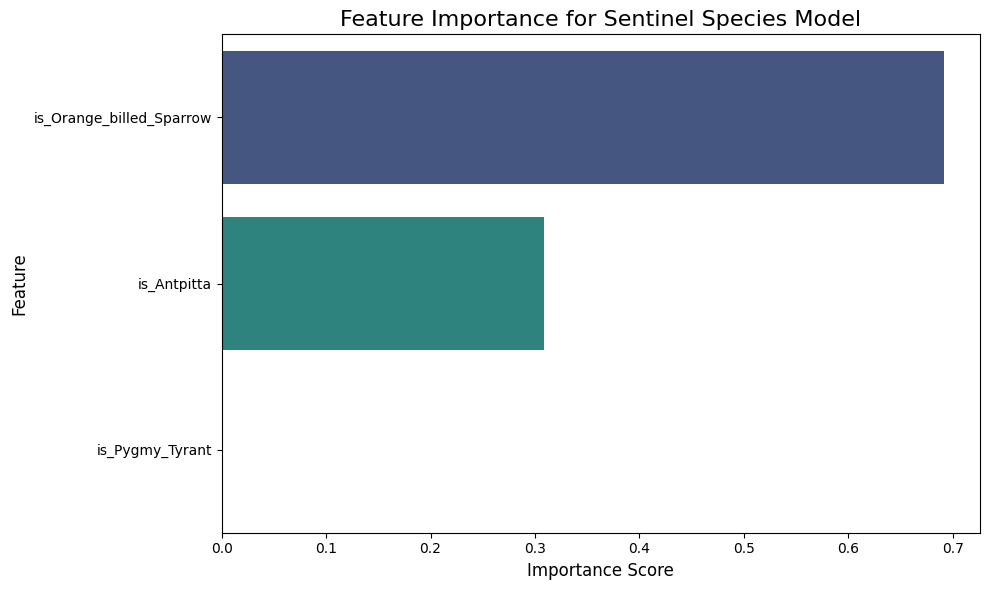

In [ ]:
# Train model with only sentinel species
X_sentinel = df[['is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant']].copy()
y = df['is_simulation'].copy()

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sentinel, y, test_size=0.2, random_state=42, stratify=y
)

xgb_sentinel = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=20,
    eval_metric='logloss'
)

xgb_sentinel.fit(X_train_s, y_train_s)
y_pred_proba_sentinel = xgb_sentinel.predict_proba(X_test_s)[:, 1]

print(f"Sentinel species model ROC-AUC: {roc_auc_score(y_test_s, y_pred_proba_sentinel):.4f}")

# Find best threshold
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_s = 0
best_thresh_s = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_sentinel >= thresh).astype(int)
    f1 = f1_score(y_test_s, y_pred)
    if f1 > best_f1_s:
        best_f1_s = f1
        best_thresh_s = thresh

y_pred_sentinel = (y_pred_proba_sentinel >= best_thresh_s).astype(int)

print(f"Best threshold: {best_thresh_s:.2f}, F1: {best_f1_s:.3f}")
print(classification_report(y_test_s, y_pred_sentinel))

print(f"\nFeature importance:")

for i, feature in enumerate(sentinel_features):
    print(f"{feature}: {xgb_sentinel.feature_importances_[i]:.3f}")

plot_feature_importance(
    model=xgb_sentinel,
    feature_names=X_sentinel.columns,
    title='Feature Importance for Sentinel Species Model'
)

Combined model ROC-AUC: 0.9460
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    152542
           1       0.16      0.48      0.24      1331

    accuracy                           0.97    153873
   macro avg       0.58      0.73      0.61    153873
weighted avg       0.99      0.97      0.98    153873


Feature importance:
                     feature  importance
0                 RMS Energy    0.203435
10  is_Orange_billed_Sparrow    0.138208
8                    MFCC_12    0.131354
7                     MFCC_9    0.110180
2          Spectral Flatness    0.107376
11               is_Antpitta    0.079221
6                     MFCC_8    0.046717
3         Spectral Bandwidth    0.041211
12           is_Pygmy_Tyrant    0.039991
4     Spectral Rolloff (85%)    0.035542
1          Spectral Contrast    0.034081
9                    MFCC_13    0.018895
5             Onset Strength    0.013788


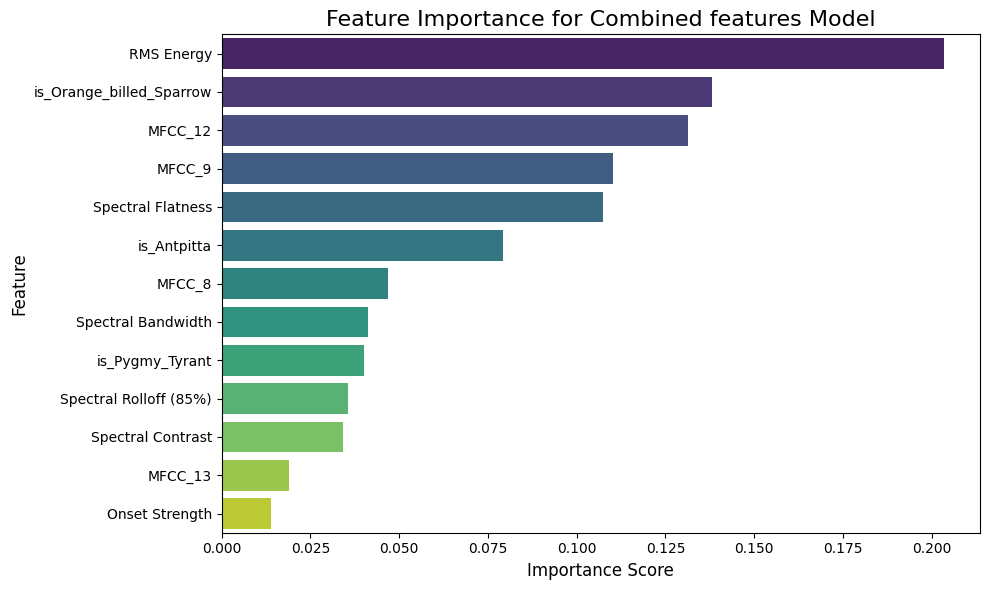

In [ ]:
core_features = [
    'RMS Energy', 'Spectral Contrast', 'Spectral Flatness',
    'Spectral Bandwidth', 'Spectral Rolloff (85%)',
    'Onset Strength', 'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13'
]

sentinel_features = ['is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant']

combined_features = core_features + sentinel_features

X_combined = df[combined_features].copy()
y = df['is_simulation'].copy()

X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

# Scale only acoustic features
scaler_cb = StandardScaler()
X_train_cb_scaled = X_train_cb.copy()
X_test_cb_scaled = X_test_cb.copy()

X_train_cb_scaled[core_features] = scaler_cb.fit_transform(X_train_cb[core_features])
X_test_cb_scaled[core_features] = scaler_cb.transform(X_test_cb[core_features])

# Use XGBoost
xgb_cb = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=20,
    eval_metric='logloss'
)

xgb_cb.fit(X_train_cb_scaled, y_train_cb)
y_pred_cb = xgb_cb.predict(X_test_cb_scaled)
y_pred_proba_cb = xgb_cb.predict_proba(X_test_cb_scaled)[:, 1]

print(f"Combined model ROC-AUC: {roc_auc_score(y_test_cb, y_pred_proba_cb):.4f}")
print(classification_report(y_test_cb, y_pred_cb))

# Check feature importance
importance = pd.DataFrame({
    'feature': combined_features,
    'importance': xgb_cb.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature importance:")
print(importance)

plot_feature_importance(
    model=xgb_cb,
    feature_names=combined_features,
    title='Feature Importance for Combined features Model'
)

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds:
    y_pred = (y_pred_proba_cb >= thresh).astype(int)
    precision = precision_score(y_test_cb, y_pred)
    recall = recall_score(y_test_cb, y_pred)
    f1 = f1_score(y_test_cb, y_pred)
    results.append([thresh, precision, recall, f1])

results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])

# Find best F1 threshold
best_f1_row = results_df.loc[results_df['F1'].idxmax()]
print(f"Best F1 threshold: {best_f1_row['Threshold']:.2f}")
print(f"Precision: {best_f1_row['Precision']:.3f}, Recall: {best_f1_row['Recall']:.3f}, F1: {best_f1_row['F1']:.3f}")

# Show top 5 thresholds
print("\nTop 5 thresholds by F1:")
print(results_df.nlargest(5, 'F1').round(3))

best_thresh = best_f1_row['Threshold']
y_pred_best = (y_pred_proba_cb >= best_thresh).astype(int)

print(f"\nResults with threshold {best_thresh:.2f}:")
print(classification_report(y_test_cb, y_pred_best))

Best F1 threshold: 0.65
Precision: 0.283, Recall: 0.292, F1: 0.287

Top 5 thresholds by F1:
    Threshold  Precision  Recall     F1
11       0.65      0.283   0.292  0.287
10       0.60      0.242   0.340  0.283
12       0.70      0.334   0.239  0.279
9        0.55      0.198   0.408  0.266
13       0.75      0.408   0.188  0.257

Results with threshold 0.65:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    152542
           1       0.28      0.29      0.29      1331

    accuracy                           0.99    153873
   macro avg       0.64      0.64      0.64    153873
weighted avg       0.99      0.99      0.99    153873



In [ ]:
# Use expanded features to find overall importance

X_expanded = df[expanded_features].copy()
y = df['is_simulation'].copy()

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_expanded, y, test_size=0.2, random_state=42, stratify=y
)

scaler_exp = StandardScaler()
features_to_scale = [f for f in expanded_features if f not in ['is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant']]

X_train_exp_scaled = X_train_exp.copy()
X_test_exp_scaled = X_test_exp.copy()
X_train_exp_scaled[features_to_scale] = scaler_exp.fit_transform(X_train_exp[features_to_scale])
X_test_exp_scaled[features_to_scale] = scaler_exp.transform(X_test_exp[features_to_scale])

xgb_exp = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=20,
    eval_metric='logloss'
)

xgb_exp.fit(X_train_exp_scaled, y_train_exp)

importance_exp = pd.DataFrame({
    'feature': expanded_features,
    'importance': xgb_exp.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature importance (all expanded features):")
print(importance_exp)

plot_feature_importance(
    model=xgb_exp,
    feature_names=expanded_features,
    title='Feature Importance for Expanded features Model'
)

NameError: name 'expanded_features' is not defined

In [ ]:
# Use sentinel species + top 6 features
custom_features = [
    'is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant',
    'Windspeed', 'Temperature', 'Datetime_hour',
    'RMS Energy', 'Humidity', 'MFCC_12'
]

print("Custom features:", custom_features)

X_custom = df[custom_features].copy()
y = df['is_simulation'].copy()

X_train_custom, X_test_custom, y_train_custom, y_test_custom = train_test_split(
    X_custom, y, test_size=0.2, random_state=42, stratify=y
)

scaler_custom = StandardScaler()
features_to_scale_custom = [f for f in custom_features if not f.startswith('is_')]

X_train_custom_scaled = X_train_custom.copy()
X_test_custom_scaled = X_test_custom.copy()
X_train_custom_scaled[features_to_scale_custom] = scaler_custom.fit_transform(X_train_custom[features_to_scale_custom])
X_test_custom_scaled[features_to_scale_custom] = scaler_custom.transform(X_test_custom[features_to_scale_custom])

xgb_custom = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=20,
    eval_metric='logloss'
)

xgb_custom.fit(X_train_custom_scaled, y_train_custom)
y_pred_proba_custom = xgb_custom.predict_proba(X_test_custom_scaled)[:, 1]

print(f"\nCustom model ROC-AUC: {roc_auc_score(y_test_custom, y_pred_proba_custom):.4f}")

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_custom = 0
best_thresh_custom = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_custom >= thresh).astype(int)
    f1 = f1_score(y_test_custom, y_pred)
    if f1 > best_f1_custom:
        best_f1_custom = f1
        best_thresh_custom = thresh

y_pred_custom = (y_pred_proba_custom >= best_thresh_custom).astype(int)
print(f"Best threshold: {best_thresh_custom:.2f}, F1: {best_f1_custom:.3f}")
print(classification_report(y_test_custom, y_pred_custom))

In [ ]:
# Filter data to only include sentinel species detections
sentinel_mask = (df['is_Orange_billed_Sparrow'] == 1) | (df['is_Antpitta'] == 1) | (df['is_Pygmy_Tyrant'] == 1)
df_sentinel_only = df[sentinel_mask].copy()

print(f"Original dataset: {len(df)} rows")
print(f"Sentinel species only: {len(df_sentinel_only)} rows")
print(f"Reduction: {(1 - len(df_sentinel_only)/len(df))*100:.1f}%")

print(f"\nSimulation distribution:")
print(f"Original - Simulations: {df['is_simulation'].sum()}, Total: {len(df)}")
print(f"Filtered - Simulations: {df_sentinel_only['is_simulation'].sum()}, Total: {len(df_sentinel_only)}")

sim_rate_original = df['is_simulation'].mean()
sim_rate_filtered = df_sentinel_only['is_simulation'].mean()
print(f"\nSimulation rate:")
print(f"Original: {sim_rate_original:.4f} ({sim_rate_original*100:.2f}%)")
print(f"Filtered: {sim_rate_filtered:.4f} ({sim_rate_filtered*100:.2f}%)")
print(f"Rate increase: {sim_rate_filtered/sim_rate_original:.2f}x")

#### Filter data Visualization

Filtered train set: 42914 rows, Simulations: 1327
Filtered test set: 10729 rows, Simulations: 332
New scale_pos_weight: 31.3

Filtered model ROC-AUC: 0.9939
Best threshold: 0.85, F1: 0.733
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     10397
           1       0.63      0.87      0.73       332

    accuracy                           0.98     10729
   macro avg       0.81      0.93      0.86     10729
weighted avg       0.98      0.98      0.98     10729



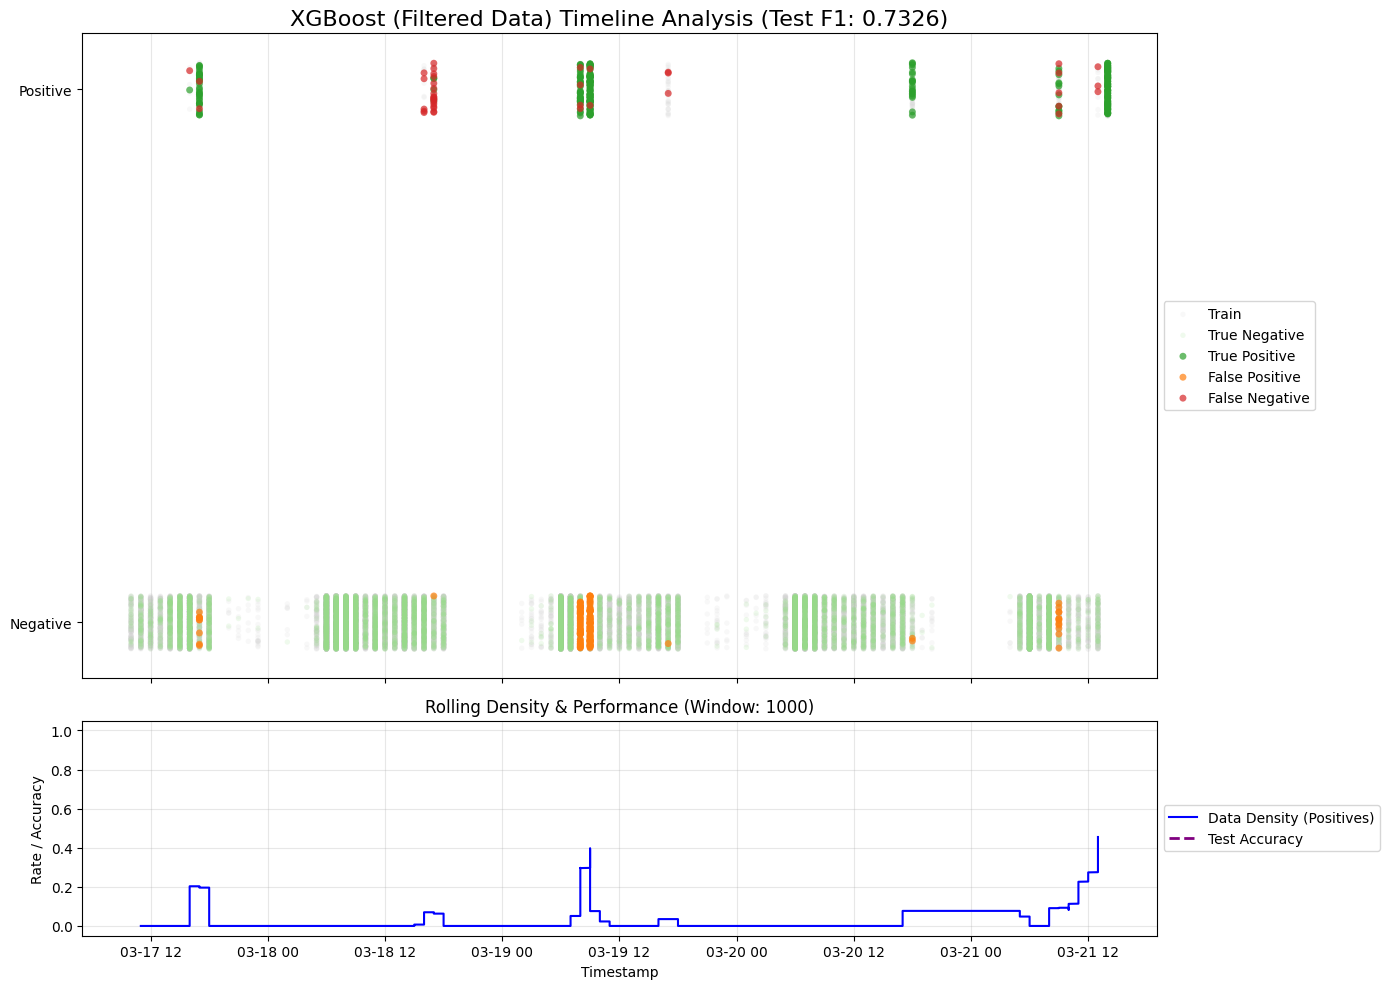

In [ ]:
sentinel_mask = (df['is_Orange_billed_Sparrow'] == 1) | (df['is_Antpitta'] == 1) | (df['is_Pygmy_Tyrant'] == 1)
df_sentinel_only = df[sentinel_mask].copy()

X_filtered = df_sentinel_only[custom_features].copy()
y_filtered = df_sentinel_only['is_simulation'].copy()

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

print(f"Filtered train set: {len(X_train_f)} rows, Simulations: {y_train_f.sum()}")
print(f"Filtered test set: {len(X_test_f)} rows, Simulations: {y_test_f.sum()}")

scaler_f = StandardScaler()
features_to_scale = [f for f in custom_features if not f.startswith('is_')]

X_train_f_scaled = X_train_f.copy()
X_test_f_scaled = X_test_f.copy()
X_train_f_scaled[features_to_scale] = scaler_f.fit_transform(X_train_f[features_to_scale])
X_test_f_scaled[features_to_scale] = scaler_f.transform(X_test_f[features_to_scale])
pos_weight = (y_train_f == 0).sum() / y_train_f.sum()
print(f"New scale_pos_weight: {pos_weight:.1f}")

xgb_filtered = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=pos_weight,
    eval_metric='logloss'
)

xgb_filtered.fit(X_train_f_scaled, y_train_f)
y_pred_proba_f = xgb_filtered.predict_proba(X_test_f_scaled)[:, 1]

print(f"\nFiltered model ROC-AUC: {roc_auc_score(y_test_f, y_pred_proba_f):.4f}")

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_f = 0
best_thresh_f = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_f >= thresh).astype(int)
    f1 = f1_score(y_test_f, y_pred)
    if f1 > best_f1_f:
        best_f1_f = f1
        best_thresh_f = thresh

y_pred_f = (y_pred_proba_f >= best_thresh_f).astype(int)
print(f"Best threshold: {best_thresh_f:.2f}, F1: {best_f1_f:.3f}")
print(classification_report(y_test_f, y_pred_f))

visualize_model_performance(
    df=df_sentinel_only,              # The original dataframe (for timestamps)
    y_train=y_train_f,    # The training labels with indices
    y_test=y_test_f,      # The test labels with indices
    y_pred=y_pred_f,  # Use y_pred_f instead of y_pred, as y_pred is redefined in the loop.
    model_name="XGBoost (Filtered Data)"
)

In [ ]:
def get_device_data_custom_scaled(df, device_name, device_col, feature_cols, target_col, test_size=0.2, random_state=42):
    """
    Filters, splits, and custom-scales data for a single device.
    This function scales only non-boolean features (not starting with 'is_').
    """
    # Filter for the specific device
    device_df = df[df[device_col] == device_name].copy()

    if device_df.empty:
        print(f"No data found for {device_name}.")
        return None, None, None, None

    X_device = device_df[feature_cols]
    y_device = device_df[target_col]

    if X_device.shape[0] < 10:
        print(f"Insufficient data for {device_name} (found {X_device.shape[0]} rows).")
        return None, None, None, None

    # Check for stratification
    stratify_param = y_device if y_device.nunique() > 1 else None
    if stratify_param is None:
        print(f"Warning: Only one class present. Splitting without stratification.")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X_device, y_device,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_param
    )

    # --- Custom Scaling Logic ---
    features_to_scale = [f for f in feature_cols if not f.startswith('is_')]

    scaler = StandardScaler()

    # Copy to avoid 'SettingWithCopyWarning'
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    # Fit on train and transform both train and test
    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
    X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

    return X_train_scaled, X_test_scaled, y_train, y_test

def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5

    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh

    return best_f1, best_threshold

# --- 3. Initial Data Filtering (Your Code) ---
# (Assuming 'df' is your full, original DataFrame)

print("Filtering data to sentinel species only...")
sentinel_mask = (df['is_Orange_billed_Sparrow'] == 1) | (df['is_Antpitta'] == 1) | (df['is_Pygmy_Tyrant'] == 1)
df_sentinel_only = df[sentinel_mask].copy()
print(f"Original dataset: {len(df)} rows")
print(f"Filtered (sentinel-only) dataset: {len(df_sentinel_only)} rows")

# --- 4. Main Loop to Run XGBoost ---

audio_moths = [
    'Audio_Moth_1', 'Audio_Moth_2', 'Audio_Moth_3',
    'Audio_Moth_4', 'Audio_Moth_5', 'Audio_Moth_6'
]
DEVICE_COLUMN = 'recorder_id'     # The column in 'df' with the moth names
TARGET_COLUMN = 'is_simulation' # The column in 'df' with the 0/1 target

all_results = []

for moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"Processing XGBoost (Filtered) for: {moth_name}")
    print("="*80)

    # --- Get Data ---
    # !! We pass df_SENTINEL_ONLY to the function !!
    data_pack = get_device_data_custom_scaled(
        df_sentinel_only, # <-- Using the pre-filtered DataFrame
        moth_name,
        DEVICE_COLUMN,
        custom_features,   # <-- Using your custom feature list
        TARGET_COLUMN,
        test_size=0.2      # <-- Matching your 0.2 test size
    )


    X_train_scaled, X_test_scaled, y_train, y_test = data_pack

    if X_train_scaled is None:
        print(f"Skipping {moth_name} due to insufficient data.")
        all_results.append({
            'device': moth_name, 'model': 'XGBoost (Filtered)', 'f1_score': None,
            'roc_auc': None, 'precision': None, 'recall': None
        })
        continue

    print(f"Data Prepared: Train size: {len(X_train_scaled)}, Test size: {len(X_test_scaled)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Test sim rate: {y_test.mean():.2%}")

    # 2. Check if training data has both classes (0 and 1)
    if y_train.nunique() < 2:
        print(f"Skipping {moth_name}: Training data has only one class (no positive samples).")
        all_results.append({
            'device': moth_name, 'model': 'XGBoost (Filtered)', 'f1_score': None,
            'roc_auc': None, 'precision': None, 'recall': None
        })
        continue # <-- Skips to the next moth

    # --- Train XGBoost Model ---

    # Calculate scale_pos_weight dynamically for *this device's* training data
    if y_train.sum() > 0:
        pos_weight = (y_train == 0).sum() / y_train.sum()
    else:
        print("Warning: No positive samples in training set. Setting pos_weight=1.")
        pos_weight = 1

    print(f"Using scale_pos_weight: {pos_weight:.1f}")

    xgb_model = xgb.XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=pos_weight, # Use the dynamically calculated weight
        eval_metric='logloss'
    )

    xgb_model.fit(X_train_scaled, y_train)
    y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

    # --- Evaluate ---
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\nFiltered model ROC-AUC: {roc_auc:.4f}")

    # Find best threshold
    best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
    print(f"Best threshold: {best_thresh:.2f}, F1: {best_f1:.3f}")

    # Get final predictions and classification report
    y_pred_final = (y_pred_proba >= best_thresh).astype(int)
    print(classification_report(y_test, y_pred_final, zero_division=0))

    # Permutation Feature importance
    print(f"--- Calculating Permutation Importance for {moth_name} ---")
    plot_permutation_importance(
        model=xgb_model,
        X_test=X_test_scaled,
        y_test=y_test,
        feature_names=custom_features, # Use 'custom_features' for this model
        title=f"Permutation Importance - XGBoost (Filtered) ({moth_name})"
    )

    # Store results
    precision = precision_score(y_test, y_pred_final, zero_division=0)
    recall = recall_score(y_test, y_pred_final, zero_division=0)

    all_results.append({
        'device': moth_name,
        'model': 'XGBoost (Filtered)',
        'f1_score': best_f1,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'best_threshold': best_thresh,
        'test_sim_rate': y_test.mean()
    })

# --- 5. Final Summary ---
print(f"\n" + "="*80)
print("FINAL SUMMARY FOR XGBOOST (FILTERED) ACROSS ALL DEVICES")
print("="*80)

summary_df = pd.DataFrame(all_results)
print(summary_df.round(3))

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    precision_score, recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define Your Devices and Features ---
# (Using your provided parameters)
custom_features = [
    'is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant',
    'Windspeed', 'Temperature', 'Datetime_hour',
    'RMS Energy', 'Humidity', 'MFCC_12'
]

audio_moths = [
    'Audio_Moth_1', 'Audio_Moth_2', 'Audio_Moth_3',
    'Audio_Moth_4', 'Audio_Moth_5', 'Audio_Moth_6'
]

DEVICE_COLUMN = 'recorder_id'
FEATURE_COLUMNS = custom_features # <-- Using your custom feature list
TARGET_COLUMN = 'is_simulation'

# --- 2. Helper Functions (From your code) ---

def get_device_data_custom_scaled(df, device_name, device_col, feature_cols, target_col, test_size=0.2, random_state=42):
    """
    Filters, splits, and custom-scales data for a single device.
    This function scales only non-boolean features (not starting with 'is_').
    """
    device_df = df[df[device_col] == device_name].copy()

    if device_df.empty: return None, None, None, None
    X_device = device_df[feature_cols]
    y_device = device_df[target_col]
    if X_device.shape[0] < 10: return None, None, None, None

    stratify_param = y_device if y_device.nunique() > 1 else None

    # Split the raw (unscaled) data first
    X_train, X_test, y_train, y_test = train_test_split(
        X_device, y_device,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_param
    )

    # --- Custom Scaling Logic ---
    features_to_scale = [f for f in feature_cols if not f.startswith('is_')]
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    # Fit on train and transform both train and test
    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
    X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

    return X_train_scaled, X_test_scaled, y_train, y_test

def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5
    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    return best_f1, best_threshold

# --- 3. Initial Data Filtering (Your Code) ---
# (Assuming 'df' is your full, original DataFrame)
print("Creating boolean sentinel columns...")
df['is_Orange_billed_Sparrow'] = (df['species'] == 'Arremon aurantiirostris_Orange-billed Sparrow')
df['is_Antpitta'] = (df['species'] == 'Hylopezus perspicillatus_Streak-chested Antpitta')
df['is_Pygmy_Tyrant'] = (df['species'] == 'Myiornis atricapillus_Black-capped Pygmy-Tyrant')

print("Filtering data to sentinel species only...")
sentinel_mask = (df['is_Orange_billed_Sparrow'] == 1) | (df['is_Antpitta'] == 1) | (df['is_Pygmy_Tyrant'] == 1)
df_sentinel_only = df[sentinel_mask].copy()
print(f"Original dataset: {len(df)} rows")
print(f"Filtered (sentinel-only) dataset: {len(df_sentinel_only)} rows")


# --- 4. Pre-process and Cache Data for All Devices ---
data_bundles = {}
print("\n--- Pre-processing data for all devices (from filtered dataset) ---")
for moth_name in audio_moths:
    data_pack = get_device_data_custom_scaled(
        df_sentinel_only, # <-- Using the pre-filtered DataFrame
        moth_name,
        DEVICE_COLUMN,
        FEATURE_COLUMNS,
        TARGET_COLUMN,
        test_size=0.2    # <-- Matching your 0.2 test size
    )

    data_bundles[moth_name] = data_pack

    if data_pack[0] is not None:
        print(f"  -> Stored data for {moth_name} (Train: {len(data_pack[0])}, Test: {len(data_pack[1])})")
    else:
        print(f"  -> No/Insufficient data for {moth_name}")
print("--- Data pre-processing complete ---")


# --- 5. Main Nested Loop for Cross-Device Testing ---

all_cross_device_results = []

# --- Outer Loop: TRAIN on this device ---
for train_moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"TRAINING Model on: {train_moth_name} (XGBoost Filtered)")
    print("="*80)

    # Get the training data for this moth
    X_train_scaled, _, y_train, _ = data_bundles[train_moth_name]

    # --- Check if training is possible ---
    if X_train_scaled is None:
        print(f"Skipping training for {train_moth_name}: Insufficient data.")
        continue

    if y_train.nunique() < 2:
        print(f"Skipping training for {train_moth_name}: Training data has only one class.")
        continue

    # --- Calculate dynamic scale_pos_weight ---
    if y_train.sum() > 0:
        pos_weight = (y_train == 0).sum() / y_train.sum()
    else:
        pos_weight = 1 # Should be unreachable due to check above, but safe
    print(f"Using scale_pos_weight: {pos_weight:.1f}")

    # --- Train the XGBoost Model ---
    xgb_model = xgb.XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=pos_weight, # Use the dynamically calculated weight
        eval_metric='logloss'
    )
    xgb_model.fit(X_train_scaled, y_train)

    # --- Inner Loop: TEST on this device ---
    print(f"--- Testing '{train_moth_name}' model on all devices: ---")
    for test_moth_name in audio_moths:

        # Get the TEST data for the inner moth
        _, X_test_scaled, _, y_test = data_bundles[test_moth_name]

        # --- Check if testing is possible ---
        if X_test_scaled is None or y_test is None:
            print(f"  -> Skipping test on {test_moth_name}: Insufficient test data.")
            continue

        if y_test.nunique() < 2:
            print(f"  -> Skipping test on {test_moth_name}: Test data has only one class.")
            continue

        # --- Test and Evaluate ---
        y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

        best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
        y_pred_final = (y_pred_proba >= best_thresh).astype(int)

        sim_precision = precision_score(y_test, y_pred_final, zero_division=0)
        sim_recall = recall_score(y_test, y_pred_final, zero_division=0)

        print(f"  -> TESTED on {test_moth_name}: F1 = {best_f1:.3f} (P: {sim_precision:.3f}, R: {sim_recall:.3f})")

        all_cross_device_results.append({
            'train_device': train_moth_name,
            'test_device': test_moth_name,
            'f1_score': best_f1,
            'precision': sim_precision,
            'recall': sim_recall
        })

# --- 6. Final Summary ---
print(f"\n" + "="*80)
print("SUMMARY OF CROSS-DEVICE VALIDATION (XGBoost Filtered)")
print("="*80)

results_df_xgb = pd.DataFrame(all_cross_device_results)

# A pivot table is the best way to view this
print("--- F1-Score Heatmap (Train device = rows, Test device = columns) ---")
f1_pivot_xgb = results_df_xgb.pivot(
    index='train_device',
    columns='test_device',
    values='f1_score'
)
print(f1_pivot_xgb.round(3))

# --- 7. Generate Heatmap Visualization ---
print("\n--- Generating Heatmap ---")
plt.figure(figsize=(12, 8))
sns.heatmap(
    f1_pivot_xgb,
    annot=True,        # Show the F1-score numbers
    fmt=".3f",         # Format to 3 decimal places
    cmap="RdYlBu",     # Color map: Red (high/good) to Blue (low/bad)
    linewidths=.5,
    cbar_kws={'label': 'F1-Score'}
)

plt.title('Cross-Device F1-Score Heatmap (XGBoost Filtered)', fontsize=16, weight='bold')
plt.xlabel('Test Device', fontsize=12)
plt.ylabel('Train Device', fontsize=12)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cross_device_f1_heatmap_xgb.png')
plt.show()

#### Cross validating original model using sentinel species data for the whole dataset

In [ ]:

# --- 1. Prepare Full Dataset ---

print(f"Using {len(custom_features)} features: {custom_features}")
X_full = df_sentinel_only[custom_features].copy()
y_full = df_sentinel_only['is_simulation'].copy()

# Identify which features to scale (all except the 'is_' boolean flags)
features_to_scale = [f for f in custom_features if not f.startswith('is_')]

# --- 2. Set up Cross-Validation ---
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_results = []
print(f"\n--- Starting {n_splits}-Fold Stratified Cross-Validation ---")

# --- 3. Run the Cross-Validation Loop ---
for fold, (train_index, val_index) in enumerate(skf.split(X_full, y_full)):
    print(f"\n" + "="*60)
    print(f"Processing Fold {fold + 1} / {n_splits}")
    print("="*60)

    # Split data for this fold using the indices
    # We use .iloc to select rows by integer index
    X_train, X_val = X_full.iloc[train_index], X_full.iloc[val_index]
    y_train, y_val = y_full.iloc[train_index], y_full.iloc[val_index]

    # --- Scale Data (INSIDE the loop) ---
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()

    # Fit scaler ONLY on X_train and transform both
    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
    X_val_scaled[features_to_scale] = scaler.transform(X_val[features_to_scale])

    # --- Calculate pos_weight (INSIDE the loop) ---
    if y_train.sum() > 0:
        pos_weight = (y_train == 0).sum() / y_train.sum()
    else:
        pos_weight = 1 # Fallback in case a fold has no positive samples

    print(f"Train size: {len(y_train)}, Val size: {len(y_val)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Val sim rate: {y_val.mean():.2%}")
    print(f"New scale_pos_weight: {pos_weight:.1f}")

    # --- Define and Train Model ---
    xgb_model = xgb.XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=pos_weight,
        eval_metric='logloss'
    )

    xgb_model.fit(X_train_scaled, y_train)

    # --- Evaluate on Validation Set ---
    y_pred_proba = xgb_model.predict_proba(X_val_scaled)[:, 1]

    roc_auc = roc_auc_score(y_val, y_pred_proba)
    print(f"\nFold {fold+1} ROC-AUC: {roc_auc:.4f}")

    # --- Find Best Threshold (for this fold) ---
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1 = 0
    best_thresh = 0.5

    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    print(f"Fold {fold+1} Best threshold: {best_thresh:.2f}, Best F1: {best_f1:.3f}")

    # Get final metrics for this fold
    y_pred_final = (y_pred_proba >= best_thresh).astype(int)
    precision = precision_score(y_val, y_pred_final, zero_division=0)
    recall = recall_score(y_val, y_pred_final, zero_division=0)

    # Store results
    fold_results.append({
        'fold': fold + 1,
        'roc_auc': roc_auc,
        'f1_score': best_f1,
        'precision': precision,
        'recall': recall,
        'best_threshold': best_thresh
    })

# --- 4. Final Summary ---
print(f"\n" + "="*60)
print("Cross-Validation Summary (All Folds)")
print("="*60)

results_df = pd.DataFrame(fold_results)
print(results_df.round(4))

print(f"\n" + "="*60)
print("Average Metrics Across All 5 Folds")
print("="*60)
print(results_df.mean().drop('fold').round(4))

#### Per-device validation

In [ ]:
# --- 1. Define Features and Device Info ---

# (Make sure these lists and columns are defined)

DEVICE_COLUMN = 'recorder_id' # The column in 'df_sentinel_only' with the moth names

# --- 2. Prepare Data (Your Original Code) ---
X_filtered = df_sentinel_only[custom_features].copy()
y_filtered = df_sentinel_only['is_simulation'].copy()

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

print(f"Filtered train set: {len(X_train_f)} rows, Simulations: {y_train_f.sum()}")
print(f"Filtered test set: {len(X_test_f)} rows, Simulations: {y_test_f.sum()}")

# --- 3. (NEW) Get a DataFrame of the Test Set ---
# We use the index from X_test_f to get the original rows from df_sentinel_only.
# This df_test will have the device ID, true label, and features.
df_test = df_sentinel_only.loc[X_test_f.index].copy()

# --- 4. Scale Data (Your Original Code) ---
scaler_f = StandardScaler()
features_to_scale = [f for f in custom_features if not f.startswith('is_')]

X_train_f_scaled = X_train_f.copy()
X_test_f_scaled = X_test_f.copy()
X_train_f_scaled[features_to_scale] = scaler_f.fit_transform(X_train_f[features_to_scale])
X_test_f_scaled[features_to_scale] = scaler_f.transform(X_test_f[features_to_scale])

# --- 5. Train XGBoost (Your Original Code) ---
if y_train_f.sum() > 0:
    pos_weight = (y_train_f == 0).sum() / y_train_f.sum()
else:
    pos_weight = 1

print(f"New scale_pos_weight: {pos_weight:.1f}")

xgb_filtered = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=pos_weight,
    eval_metric='logloss'
)

print("\n--- Training XGBoost on all devices (filtered data) ---")
xgb_filtered.fit(X_train_f_scaled, y_train_f)

# --- 6. Evaluate on ALL Test Data (Your Original Code) ---
y_pred_proba_f = xgb_filtered.predict_proba(X_test_f_scaled)[:, 1]

print(f"\nFiltered model ROC-AUC (Overall): {roc_auc_score(y_test_f, y_pred_proba_f):.4f}")

# Find best threshold (based on overall test set)
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_f = 0
best_thresh_f = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_f >= thresh).astype(int)
    f1 = f1_score(y_test_f, y_pred, zero_division=0)
    if f1 > best_f1_f:
        best_f1_f = f1
        best_thresh_f = thresh

y_pred_f = (y_pred_proba_f >= best_thresh_f).astype(int)
print(f"Best threshold (Overall): {best_thresh_f:.2f}, F1: {best_f1_f:.3f}")
print("\n--- Overall Test Set Performance (All Devices) ---")
print(classification_report(y_test_f, y_pred_f, zero_division=0))


# --- 7. (NEW) Per-Device Evaluation Loop ---
print(f"\n" + "="*80)
print("PER-DEVICE PERFORMANCE BREAKDOWN (ON TEST SET)")
print("="*80)

# Add the final predictions to our test DataFrame
# y_pred_f is a numpy array in the same order as df_test
df_test['y_pred_final'] = y_pred_f

per_device_results = []

for moth_name in audio_moths:
    # Filter the test set for *only* this moth's data
    moth_test_df = df_test[df_test[DEVICE_COLUMN] == moth_name]

    if moth_test_df.empty:
        print(f"\n--- {moth_name} ---")
        print("No test data available for this device.")
        continue

    # Get the true labels and predicted labels for this device
    y_true_device = moth_test_df['is_simulation']
    y_pred_device = moth_test_df['y_pred_final']

    # Calculate metrics
    f1 = f1_score(y_true_device, y_pred_device, zero_division=0)
    precision = precision_score(y_true_device, y_pred_device, zero_division=0)
    recall = recall_score(y_true_device, y_pred_device, zero_division=0)

    print(f"\n--- {moth_name} (Test Samples: {len(y_true_device)}) ---")
    print(f"F1: {f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")

    per_device_results.append({
        'device': moth_name,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'test_samples': len(y_true_device)
    })

# --- 8. (NEW) Final Summary Table ---
print(f"\n" + "="*80)
print("Per-Device Performance Summary")
print("="*80)
summary_df = pd.DataFrame(per_device_results)
print(summary_df.round(3))

#### LODO Validation

In [ ]:
# --- 1. Define Features and Device Info ---


DEVICE_COLUMN = 'recorder_id' # The column in 'df_sentinel_only' with the moth names
TARGET_COLUMN = 'is_simulation'
FEATURES_TO_USE = custom_features # Use the custom_features list

# Identify which features to scale
features_to_scale = [f for f in FEATURES_TO_USE if not f.startswith('is_')]

# --- 2. Helper Function ---
def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5
    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    return best_f1, best_threshold

# --- 3. Main LODO Cross-Validation Loop ---
all_lodo_results = []
print("--- Starting Leave-One-Device-Out (LODO) Validation for XGBoost (Filtered) ---")

for test_moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"HOLDING OUT (Test Set): {test_moth_name}")
    print(f"TRAINING on all other 5 devices")
    print("="*80)

    # --- Create Train/Test splits based on device ---
    # Use the pre-filtered df_sentinel_only DataFrame as the source
    train_df = df_sentinel_only[df_sentinel_only[DEVICE_COLUMN] != test_moth_name].copy()
    test_df = df_sentinel_only[df_sentinel_only[DEVICE_COLUMN] == test_moth_name].copy()

    # --- Check for valid data ---
    if test_df.empty:
        print(f"Skipping {test_moth_name}: No test data found for this device.")
        continue
    if train_df.empty:
        print(f"Skipping {test_moth_name}: No training data available.")
        continue

    # --- Separate Features and Target ---
    X_train_raw = train_df[FEATURES_TO_USE]
    y_train = train_df[TARGET_COLUMN]
    X_test_raw = test_df[FEATURES_TO_USE]
    y_test = test_df[TARGET_COLUMN]

    # Check for labels in train/test sets
    if y_train.nunique() < 2:
        print(f"Skipping {test_moth_name}: Training data has only one class.")
        continue
    if y_test.nunique() < 2:
        print(f"Skipping {test_moth_name}: Test data has only one class.")
        continue

    print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Test sim rate: {y_test.mean():.2%}")

    # --- Custom Scale Data (Fit on Train, Transform Test) ---
    scaler = StandardScaler()

    X_train_scaled = X_train_raw.copy()
    X_test_scaled = X_test_raw.copy()

    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train_raw[features_to_scale])
    X_test_scaled[features_to_scale] = scaler.transform(X_test_raw[features_to_scale])

    # --- Calculate scale_pos_weight (based *only* on train set) ---
    pos_weight = (y_train == 0).sum() / y_train.sum()
    print(f"Using scale_pos_weight: {pos_weight:.1f}")

    # --- Train XGBoost Model (from your code) ---
    xgb_model = xgb.XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=pos_weight,
        eval_metric='logloss'
    )

    xgb_model.fit(X_train_scaled, y_train)

    # --- Evaluate on Hold-Out Device ---
    y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
    y_pred_final = (y_pred_proba >= best_thresh).astype(int)

    precision = precision_score(y_test, y_pred_final, zero_division=0)
    recall = recall_score(y_test, y_pred_final, zero_division=0)

    print(f"\n--- Results for held-out {test_moth_name} ---")
    print(f"F1: {best_f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, ROC-AUC: {roc_auc:.3f}")
    # print(classification_report(y_test, y_pred_final, zero_division=0))

    # Store results
    all_lodo_results.append({
        'held_out_device': test_moth_name,
        'f1_score': best_f1,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'best_threshold': best_thresh,
        'test_samples': len(y_test)
    })

# --- 4. Final LODO Summary ---
print(f"\n" + "="*80)
print("LODO VALIDATION SUMMARY (XGBoost Filtered)")
print("="*80)

summary_df = pd.DataFrame(all_lodo_results)
print(summary_df.round(3))

print(f"\n" + "="*80)
print("Average LODO Performance")
print("="*80)
# Drop non-numeric columns before calculating mean
metrics_mean = summary_df.drop(columns=['held_out_device']).mean()
print(metrics_mean.round(3))

## MLP Neural Network

### 3 sentinel species + 6 high ranking features USING filtered data (only sentinel detection clips) (4 s)

In [ ]:
X_train_mlp = X_train_f_scaled.copy()
X_test_mlp = X_test_f_scaled.copy()
y_train_mlp = y_train_f.copy()
y_test_mlp = y_test_f.copy()

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp_model.fit(X_train_mlp, y_train_mlp)
y_pred_proba_mlp = mlp_model.predict_proba(X_test_mlp)[:, 1]

print(f"MLP ROC-AUC: {roc_auc_score(y_test_mlp, y_pred_proba_mlp):.4f}")

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_mlp = 0
best_thresh_mlp = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_mlp >= thresh).astype(int)
    f1 = f1_score(y_test_mlp, y_pred)
    if f1 > best_f1_mlp:
        best_f1_mlp = f1
        best_thresh_mlp = thresh

y_pred_mlp = (y_pred_proba_mlp >= best_thresh_mlp).astype(int)
print(f"Best threshold: {best_thresh_mlp:.2f}, F1: {best_f1_mlp:.3f}")
print(classification_report(y_test_mlp, y_pred_mlp))

plot_permutation_importance(
    model=mlp_model,
    X_test=X_test_mlp,  # Use the scaled test data
    y_test=y_test_mlp,  # Use the test labels
    feature_names=custom_features, # This list must match the columns in X_test_mlp
    title='Permutation Importance for MLP Model'
)

### 3 sentinel species + 6 high ranking features USING full data (38 s)

In [ ]:
# Use original full dataset
X_full_mlp = df[custom_features].copy()
y_full_mlp = df['is_simulation'].copy()

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full_mlp, y_full_mlp, test_size=0.2, random_state=42, stratify=y_full_mlp
)

scaler_full = StandardScaler()
features_to_scale = [f for f in custom_features if not f.startswith('is_')]

X_train_full_scaled = X_train_full.copy()
X_test_full_scaled = X_test_full.copy()
X_train_full_scaled[features_to_scale] = scaler_full.fit_transform(X_train_full[features_to_scale])
X_test_full_scaled[features_to_scale] = scaler_full.transform(X_test_full[features_to_scale])

print(f"Full dataset - Train: {len(X_train_full)}, Test: {len(X_test_full)}")
print(f"Simulations - Train: {y_train_full.sum()}, Test: {y_test_full.sum()}")

# Train MLP on full data
mlp_full = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp_full.fit(X_train_full_scaled, y_train_full)
y_pred_proba_full = mlp_full.predict_proba(X_test_full_scaled)[:, 1]

print(f"\nMLP Full Data ROC-AUC: {roc_auc_score(y_test_full, y_pred_proba_full):.4f}")

# Find best threshold
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_full = 0
best_thresh_full = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_full >= thresh).astype(int)
    f1 = f1_score(y_test_full, y_pred)
    if f1 > best_f1_full:
        best_f1_full = f1
        best_thresh_full = thresh

y_pred_full = (y_pred_proba_full >= best_thresh_full).astype(int)
print(f"Best threshold: {best_thresh_full:.2f}, F1: {best_f1_full:.3f}")
print(classification_report(y_test_full, y_pred_full))

plot_permutation_importance(
    model=mlp_model,
    X_test=X_test_mlp,  # Use the scaled test data
    y_test=y_test_mlp,  # Use the test labels
    feature_names=custom_features, # This list must match the columns in X_test_mlp
    title='Permutation Importance for MLP Model'
)

### 3 sentinel species + 6 high ranking features + acoustic features USING full data (402 s)

In [ ]:


print(f"Total features: {len(expanded_features)}")
print("Features:", expanded_features)

X_exp = df[expanded_features].copy()
y_exp = df['is_simulation'].copy()

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42, stratify=y_exp
)

# Scale features
scaler_exp = StandardScaler()
features_to_scale_exp = [f for f in expanded_features if not f.startswith('is_')]

X_train_exp_scaled = X_train_exp.copy()
X_test_exp_scaled = X_test_exp.copy()
X_train_exp_scaled[features_to_scale_exp] = scaler_exp.fit_transform(X_train_exp[features_to_scale_exp])
X_test_exp_scaled[features_to_scale_exp] = scaler_exp.transform(X_test_exp[features_to_scale_exp])

mlp_exp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp_exp.fit(X_train_exp_scaled, y_train_exp)
y_pred_proba_exp = mlp_exp.predict_proba(X_test_exp_scaled)[:, 1]

print(f"\nMLP {len(expanded_features)} Features ROC-AUC: {roc_auc_score(y_test_exp, y_pred_proba_exp):.4f}")

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_exp = 0
best_thresh_exp = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_exp >= thresh).astype(int)
    f1 = f1_score(y_test_exp, y_pred)
    if f1 > best_f1_exp:
        best_f1_exp = f1
        best_thresh_exp = thresh

y_pred_exp = (y_pred_proba_exp >= best_thresh_exp).astype(int)
print(f"Best threshold: {best_thresh_exp:.2f}, F1: {best_f1_exp:.3f}")
print(classification_report(y_test_exp, y_pred_exp))

visualize_model_performance(
    df=df,              # The original dataframe (for timestamps)
    y_train=y_train_exp,    # The training labels with indices
    y_test=y_test_exp,      # The test labels with indices
    y_pred=y_pred,  # The predictions you just generated
    model_name="MLP NN (Expanded Feature)"
)

#### MLP performance visualization

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plot_permutation_importance(
    model=mlp_exp,
    X_test=X_test_exp_scaled,  # Use the scaled test data
    y_test=y_test_exp,  # Use the test labels
    feature_names=expanded_features, # This list must match the columns in X_test_mlp
    title='Permutation Importance for MLP Model'
)

data = {
    'Model': [
        'Isolation Forest',
        'LightGBM',
        'XGBoost (9 features filtered)',
        'MLP Neural Network (19 features)'
    ],
    'Precision': [0.011, 0.07, 0.54, 0.76],  # <-- Replace with your Precision scores
    'Recall':    [0.363, 0.70, 0.89, 0.77],  # <-- Replace with your Recall scores
    'F1-Score':  [0.021, 0.13, 0.68, 0.77],  # <-- Replace with your F1-Scores
    'ROC-AUC':   [np.nan, 0.9413, 0.9908, 0.9983] # <-- Replace with your ROC-AUC scores (use np.nan for Isolation Forest)
}

# --------------------------------------------------------------------
# ---> STEP 2: RUN THE REST OF THE SCRIPT (No changes needed) <---
# --------------------------------------------------------------------

df_metrics = pd.DataFrame(data)

# Melt the DataFrame to a long format suitable for plotting
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Set the visual style and figure size for the chart
sns.set_style("whitegrid")
plt.figure(figsize=(14, 8))

# Create the bar plot using seaborn
ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

# Add the score labels on top of each bar for clarity
for p in ax.patches:
    # Check if the height is a valid number before adding the label
    if not np.isnan(p.get_height()):
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10)

# Set the titles and labels for the chart
plt.title('Comparison of Machine Learning Model Performance', fontsize=16, weight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=10, ha='right')
plt.ylim(0, 1.15) # Adjust y-axis to make space for labels above the bars
plt.legend(title='Performance Metric', loc='upper right')
plt.tight_layout()

# Save the plot as an image file and display it
plt.savefig('model_performance_comparison.png')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---> STEP 1: UPDATE YOUR METRICS HERE <---
# Replace the placeholder numbers below with the actual results from your three MLP models.
# Make sure to use the scores for the POSITIVE class (label '1').

data = {
    'Model': [
        'MLP (Filtered Data)',
        'MLP (Full Data)',
        'MLP (Full Data + Acoustic)'
    ],
    'Precision': [0.75, 0.51, 0.76],  # <-- Replace with your Precision scores
    'Recall':    [0.75, 0.46, 0.77],  # <-- Replace with your Recall scores
    'F1-Score':  [0.75, 0.49, 0.77],  # <-- Replace with your F1-Scores
    'ROC-AUC':   [0.9898, 0.9877, 0.9983],  # <-- Replace with your ROC-AUC scores
    'Time (s)':  [4, 38, 402]          # <-- These are your computation times in seconds
}


df_mlp = pd.DataFrame(data)

# Set the visual style for the charts
sns.set_style("whitegrid")

# Create a figure with two vertically stacked subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 12))
fig.suptitle('MLP Model Comparison: Performance vs. Computation Time', fontsize=18, weight='bold')

# --- Top Plot: Performance Metrics ---
df_perf = df_mlp.melt(id_vars='Model', value_vars=['Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
                      var_name='Metric', value_name='Score')

ax1 = sns.barplot(data=df_perf, x='Model', y='Score', hue='Metric', ax=axes[0], palette='plasma')
ax1.set_title('Performance Metrics', fontsize=14)
ax1.set_xlabel('') # Remove x-axis label for the top plot
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.15)
ax1.legend(title='Metric')

# Add score labels on top of each bar for the performance plot
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 xytext=(0, 9),
                 textcoords='offset points',
                 fontsize=9)

# --- Bottom Plot: Computation Time ---
ax2 = sns.barplot(data=df_mlp, x='Model', y='Time (s)', ax=axes[1], palette='cividis')
ax2.set_title('Computation Time', fontsize=14)
ax2.set_xlabel('Model Version', fontsize=12)
ax2.set_ylabel('Time (seconds)')

# Add time labels on top of each bar for the time plot
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.0f} s',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 xytext=(0, 9),
                 textcoords='offset points',
                 fontsize=10)

# Adjust the layout to prevent titles and labels from overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust rect for the main title (suptitle)

# Save the final chart as an image file and display it
plt.savefig('mlp_model_comparison.png')
plt.show()

### Individual Audio_Moth Analysis

In [ ]:
# Set this to the feature list you want to use
FEATURE_COLUMNS = expanded_features

# Define your devices and data columns

DEVICE_COLUMN = 'recorder_id'     # The column in 'df' with the moth names
TARGET_COLUMN = 'is_simulation' # The column in 'df' with the 0/1 target

# --- 3. Helper Functions (Copied from previous steps) ---

def get_device_data_custom_scaled(df, device_name, device_col, feature_cols, target_col, test_size=0.2, random_state=42):
    """
    Filters, splits, and custom-scales data for a single device.
    This function scales only non-boolean features (not starting with 'is_').
    """
    device_df = df[df[device_col] == device_name].copy()

    if device_df.empty:
        print(f"No data found for {device_name}.")
        return None, None, None, None

    X_device = device_df[feature_cols]
    y_device = device_df[target_col]

    if X_device.shape[0] < 10:
        print(f"Insufficient data for {device_name} (found {X_device.shape[0]} rows).")
        return None, None, None, None

    stratify_param = y_device if y_device.nunique() > 1 else None
    if stratify_param is None:
        print(f"Warning: Only one class present. Splitting without stratification.")

    X_train, X_test, y_train, y_test = train_test_split(
        X_device, y_device,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_param
    )

    features_to_scale = [f for f in feature_cols if not f.startswith('is_')]
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
    X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

    return X_train_scaled, X_test_scaled, y_train, y_test

def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5

    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh

    return best_f1, best_threshold

# --- 4. Main Loop to Run MLP ---

all_results = []

for moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"Processing MLP (Expanded) for: {moth_name}")
    print("="*80)

    # --- Get Data ---
    # We pass the FULL 'df' to the function
    data_pack = get_device_data_custom_scaled(
        df, # <-- Using the full, original DataFrame
        moth_name,
        DEVICE_COLUMN,
        FEATURE_COLUMNS, # <-- Using expanded_features
        TARGET_COLUMN,
        test_size=0.2    # <-- Matching your 0.2 test size
    )

    X_train_scaled, X_test_scaled, y_train, y_test = data_pack

    # --- Add Checks ---
    if X_train_scaled is None:
        print(f"Skipping {moth_name} due to insufficient data.")
        all_results.append({
            'device': moth_name, 'model': 'MLP (Expanded)', 'f1_score': None,
            'roc_auc': None, 'precision': None, 'recall': None
        })
        continue

    if y_train.nunique() < 2:
        print(f"Skipping {moth_name}: Training data has only one class (no positive samples).")
        all_results.append({
            'device': moth_name, 'model': 'MLP (Expanded)', 'f1_score': None,
            'roc_auc': None, 'precision': None, 'recall': None
        })
        continue
    # --- End Checks ---

    print(f"Data Prepared: Train size: {len(X_train_scaled)}, Test size: {len(X_test_scaled)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Test sim rate: {y_test.mean():.2%}")

    # --- Train MLP Model ---
    # (Using the exact parameters you provided)
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.01,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )

    mlp_model.fit(X_train_scaled, y_train)
    y_pred_proba = mlp_model.predict_proba(X_test_scaled)[:, 1]

    # --- Evaluate ---
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\nMLP {len(FEATURE_COLUMNS)} Features ROC-AUC: {roc_auc:.4f}")

    # Find best threshold
    best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
    print(f"Best threshold: {best_thresh:.2f}, F1: {best_f1:.3f}")

    # Get final predictions and classification report
    y_pred_final = (y_pred_proba >= best_thresh).astype(int)
    print(classification_report(y_test, y_pred_final, zero_division=0))

    # Permutation Feature importance
    print(f"--- Calculating Permutation Importance for {moth_name} ---")
    plot_permutation_importance(
        model=mlp_model,
        X_test=X_test_scaled,
        y_test=y_test,
        feature_names=FEATURE_COLUMNS, # This is your 'expanded_features' list
        title=f"Permutation Importance - MLP ({moth_name})"
    )

    # Store results
    precision = precision_score(y_test, y_pred_final, zero_division=0)
    recall = recall_score(y_test, y_pred_final, zero_division=0)

    all_results.append({
        'device': moth_name,
        'model': 'MLP (Expanded)',
        'f1_score': best_f1,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'best_threshold': best_thresh,
        'test_sim_rate': y_test.mean()
    })

# --- 5. Final Summary ---
print(f"\n" + "="*80)
print("FINAL SUMMARY FOR MLP (EXPANDED) ACROSS ALL DEVICES")
print("="*80)

summary_df = pd.DataFrame(all_results)
print(summary_df.round(3))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    precision_score, recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define Your Devices and Features ---
# (Using your provided parameters)

# (Assuming 'core_features' is defined from a previous cell)
# core_features = [
#     'RMS Energy', 'Spectral Contrast', 'Spectral Flatness',
#     'Spectral Bandwidth', 'Spectral Rolloff (85%)', 'Onset Strength',
#     'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13'
# ]

expanded_features = core_features + [
    'is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant',
    'Temperature', 'Humidity', 'Windspeed', 'Datetime_hour',
    'Human Activity Score', 'confidence'
]

audio_moths = [
    'Audio_Moth_1', 'Audio_Moth_2', 'Audio_Moth_3',
    'Audio_Moth_4', 'Audio_Moth_5', 'Audio_Moth_6'
]

DEVICE_COLUMN = 'recorder_id'
FEATURE_COLUMNS = expanded_features # <-- Using your expanded feature list
TARGET_COLUMN = 'is_simulation'

# --- 2. Helper Functions (From your code) ---

def get_device_data_custom_scaled(df, device_name, device_col, feature_cols, target_col, test_size=0.2, random_state=42):
    """
    Filters, splits, and custom-scales data for a single device.
    This function scales only non-boolean features (not starting with 'is_').
    """
    device_df = df[df[device_col] == device_name].copy()

    if device_df.empty: return None, None, None, None
    X_device = device_df[feature_cols]
    y_device = device_df[target_col]
    if X_device.shape[0] < 10: return None, None, None, None

    stratify_param = y_device if y_device.nunique() > 1 else None

    # Split the raw (unscaled) data first
    X_train, X_test, y_train, y_test = train_test_split(
        X_device, y_device,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_param
    )

    # --- Custom Scaling Logic ---
    features_to_scale = [f for f in feature_cols if not f.startswith('is_')]
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    # Fit on train and transform both train and test
    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
    X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

    return X_train_scaled, X_test_scaled, y_train, y_test

def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5
    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    return best_f1, best_threshold

# --- 3. Pre-process and Cache Data for All Devices ---
data_bundles = {}
print("\n--- Pre-processing data for all devices (from full dataset) ---")
for moth_name in audio_moths:
    data_pack = get_device_data_custom_scaled(
        df, # <-- Using the full, original DataFrame
        moth_name,
        DEVICE_COLUMN,
        FEATURE_COLUMNS, # Using expanded_features
        TARGET_COLUMN,
        test_size=0.2    # <-- Matching your 0.2 test size
    )

    data_bundles[moth_name] = data_pack

    if data_pack[0] is not None:
        print(f"  -> Stored data for {moth_name} (Train: {len(data_pack[0])}, Test: {len(data_pack[1])})")
    else:
        print(f"  -> No/Insufficient data for {moth_name}")
print("--- Data pre-processing complete ---")


# --- 4. Main Nested Loop for Cross-Device Testing ---

all_cross_device_results = []

# --- Outer Loop: TRAIN on this device ---
for train_moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"TRAINING Model on: {train_moth_name} (MLP Expanded)")
    print("="*80)

    # Get the training data for this moth
    X_train_scaled, _, y_train, _ = data_bundles[train_moth_name]

    # --- Check if training is possible ---
    if X_train_scaled is None:
        print(f"Skipping training for {train_moth_name}: Insufficient data.")
        continue

    if y_train.nunique() < 2:
        print(f"Skipping training for {train_moth_name}: Training data has only one class.")
        continue

    # --- Train the MLP Model ---
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.01,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
    mlp_model.fit(X_train_scaled, y_train)

    # --- Inner Loop: TEST on this device ---
    print(f"--- Testing '{train_moth_name}' model on all devices: ---")
    for test_moth_name in audio_moths:

        # Get the TEST data for the inner moth
        _, X_test_scaled, _, y_test = data_bundles[test_moth_name]

        # --- Check if testing is possible ---
        if X_test_scaled is None or y_test is None:
            print(f"  -> Skipping test on {test_moth_name}: Insufficient test data.")
            continue

        if y_test.nunique() < 2:
            print(f"  -> Skipping test on {test_moth_name}: Test data has only one class.")
            continue

        # --- Test and Evaluate ---
        y_pred_proba = mlp_model.predict_proba(X_test_scaled)[:, 1]

        best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
        y_pred_final = (y_pred_proba >= best_thresh).astype(int)

        sim_precision = precision_score(y_test, y_pred_final, zero_division=0)
        sim_recall = recall_score(y_test, y_pred_final, zero_division=0)

        print(f"  -> TESTED on {test_moth_name}: F1 = {best_f1:.3f} (P: {sim_precision:.3f}, R: {sim_recall:.3f})")

        all_cross_device_results.append({
            'train_device': train_moth_name,
            'test_device': test_moth_name,
            'f1_score': best_f1,
            'precision': sim_precision,
            'recall': sim_recall
        })

# --- 5. Final Summary ---
print(f"\n" + "="*80)
print("SUMMARY OF CROSS-DEVICE VALIDATION (MLP Expanded)")
print("="*80)

results_df_mlp = pd.DataFrame(all_cross_device_results)

# A pivot table is the best way to view this
print("--- F1-Score Heatmap (Train device = rows, Test device = columns) ---")
f1_pivot_mlp = results_df_mlp.pivot(
    index='train_device',
    columns='test_device',
    values='f1_score'
)
print(f1_pivot_mlp.round(3))

# --- 6. Generate Heatmap Visualization ---
print("\n--- Generating Heatmap ---")
plt.figure(figsize=(12, 8))
sns.heatmap(
    f1_pivot_mlp,
    annot=True,        # Show the F1-score numbers
    fmt=".3f",         # Format to 3 decimal places
    cmap="RdYlBu",     # Color map: Red (high/good) to Blue (low/bad)
    linewidths=.5,
    cbar_kws={'label': 'F1-Score'}
)
plt.title('Cross-Device F1-Score Heatmap (MLP Expanded)', fontsize=16, weight='bold')
plt.xlabel('Test Device', fontsize=12)
plt.ylabel('Train Device', fontsize=12)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cross_device_f1_heatmap_mlp.png')
plt.show()

It seemed that every model that was trained on one device was overfitting, so I wanted to Check if the original models trained on the full dataset was overfitting or not by performing cross-validation.

#### Cross Validation for original MLP NN with 3 Sentinel Species + 6 high ranking features + acoustic data using full data

In [ ]:

# --- 1. Data Preparation (Same as your code) ---

print(f"Total features: {len(expanded_features)}")

X_exp = df[expanded_features].copy()
y_exp = df['is_simulation'].copy()

# Identify features to scale (non-booleans)
features_to_scale_exp = [f for f in expanded_features if not f.startswith('is_')]

# --- 2. Cross-Validation Setup ---
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Lists to store the score from each fold
fold_f1_scores = []
fold_roc_auc_scores = []
fold_best_thresholds = []

print(f"\n--- Starting {N_SPLITS}-Fold Stratified Cross-Validation ---")

# --- 3. The Cross-Validation Loop ---
for fold, (train_index, test_index) in enumerate(skf.split(X_exp, y_exp)):
    print(f"\n" + "="*80)
    print(f"FOLD {fold + 1}/{N_SPLITS}")
    print("="*80)

    # --- A: Split data for this fold ---
    X_train, X_test = X_exp.iloc[train_index], X_exp.iloc[test_index]
    y_train, y_test = y_exp.iloc[train_index], y_exp.iloc[test_index]

    # --- B: Scale features (Fit *only* on train data) ---
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[features_to_scale_exp] = scaler.fit_transform(X_train[features_to_scale_exp])
    X_test_scaled[features_to_scale_exp] = scaler.transform(X_test[features_to_scale_exp])

    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

    # --- C: Initialize and Train Model (re-create for each fold) ---
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.01,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )

    mlp_model.fit(X_train_scaled, y_train)

    # --- D: Evaluate ---
    y_pred_proba = mlp_model.predict_proba(X_test_scaled)[:, 1]

    fold_roc_auc = roc_auc_score(y_test, y_pred_proba)
    fold_roc_auc_scores.append(fold_roc_auc)

    # Find best threshold (your logic)
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1_fold = 0
    best_thresh_fold = 0.5

    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        if f1 > best_f1_fold:
            best_f1_fold = f1
            best_thresh_fold = thresh

    fold_f1_scores.append(best_f1_fold)
    fold_best_thresholds.append(best_thresh_fold)

    print(f"Fold {fold+1} ROC-AUC: {fold_roc_auc:.4f}")
    print(f"Fold {fold+1} Best F1: {best_f1_fold:.3f} (at threshold {best_thresh_fold:.2f})")

# --- 4. Final Summary ---
print(f"\n" + "="*80)
print("Cross-Validation Summary (All 6 Moths Combined)")
print("="*80)
print(f"Average F1-Score:    {np.mean(fold_f1_scores):.4f} +/- {np.std(fold_f1_scores):.4f}")
print(f"Average ROC-AUC:     {np.mean(fold_roc_auc_scores):.4f} +/- {np.std(fold_roc_auc_scores):.4f}")
print(f"Average Best Threshold: {np.mean(fold_best_thresholds):.2f}")

It seems that training model on individual audio moths were causing them to overfit, increasing performance but greatly reducing generalizability.

Future goals:
1. Use Leave-One-Device-Out (LODO) Cross-Validation
    - Train on a combined dataset of Moth_1, Moth_2, Moth_3, Moth_4, and Moth_5.
    - Test only on the held-out Moth_6.
    - Repeat this process 6 times, holding out a different moth each time.
    - All models performed worse compared to previous performance metrics
    - This suggests the 1) models either do not generalize well and performs poorly when introduced to a unfamiliar device, or 2) the different devices have unique qualities and cannot be generalized well from training with the other audio moths
    - Audio_Moth 5 and 6 are most similar to each other, which causes their f1 score to be higher during LODO
2. Feature Selection and Augmentation
    - more useful feature (from feature selection), more samples (from augmenting previous simulation samples)
3. Device specific validation for original model to see if a device is carrying the performance metric
    - Results are patchy at best, with some models that have audio moth 3, 5, and 6 being well predicted (MLP), while in others, audio moth 3 gets zero recall (Sentinel species XGBoost, probably due to its filtered dataset and audio moth three only having 52 test samples), others also show that Audio moth 1 has been carrying the performance (lightGBM)
4. standarize data across audio_moth
5. select other audio features
6. Rufous Piha
7. Spectacled Owl
8. how to represent sentinel species within each data point
9.
Further questions:



#### Per-device Validation

In [ ]:

# --- 1. Define Features and Device Info ---


DEVICE_COLUMN = 'recorder_id' # The column in 'df' with the moth names

# --- 2. Prepare Data (Your Original Code) ---
print(f"Total features: {len(expanded_features)}")
print("Features:", expanded_features)

X_exp = df[expanded_features].copy()
y_exp = df['is_simulation'].copy()

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42, stratify=y_exp
)

# --- 3. (NEW) Get a DataFrame of the Test Set ---
# We use the index from X_test_exp to get the original rows from df.
# This df_test will have the device ID, true label, and features.
df_test = df.loc[X_test_exp.index].copy()

# --- 4. Scale Data (Your Original Code) ---
scaler_exp = StandardScaler()
features_to_scale_exp = [f for f in expanded_features if not f.startswith('is_')]

X_train_exp_scaled = X_train_exp.copy()
X_test_exp_scaled = X_test_exp.copy()
X_train_exp_scaled[features_to_scale_exp] = scaler_exp.fit_transform(X_train_exp[features_to_scale_exp])
X_test_exp_scaled[features_to_scale_exp] = scaler_exp.transform(X_test_exp[features_to_scale_exp])

# --- 5. Train MLP (Your Original Code) ---
mlp_exp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

print("\n--- Training MLP on all devices ---")
mlp_exp.fit(X_train_exp_scaled, y_train_exp)

# --- 6. Evaluate on ALL Test Data (Your Original Code) ---
y_pred_proba_exp = mlp_exp.predict_proba(X_test_exp_scaled)[:, 1]

print(f"\nMLP {len(expanded_features)} Features ROC-AUC (Overall): {roc_auc_score(y_test_exp, y_pred_proba_exp):.4f}")

# Find best threshold (based on overall test set)
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_exp = 0
best_thresh_exp = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_exp >= thresh).astype(int)
    f1 = f1_score(y_test_exp, y_pred)
    if f1 > best_f1_exp:
        best_f1_exp = f1
        best_thresh_exp = thresh

y_pred_exp = (y_pred_proba_exp >= best_thresh_exp).astype(int)
print(f"Best threshold (Overall): {best_thresh_exp:.2f}, F1: {best_f1_exp:.3f}")
print("\n--- Overall Test Set Performance (All Devices) ---")
print(classification_report(y_test_exp, y_pred_exp))


# --- 7. (NEW) Per-Device Evaluation Loop ---
print(f"\n" + "="*80)
print("PER-DEVICE PERFORMANCE BREAKDOWN (ON TEST SET)")
print("="*80)

# Add the final predictions to our test DataFrame
df_test['y_pred_final'] = y_pred_exp

per_device_results = []

for moth_name in audio_moths:
    # Filter the test set for *only* this moth's data
    moth_test_df = df_test[df_test[DEVICE_COLUMN] == moth_name]

    if moth_test_df.empty:
        print(f"\n--- {moth_name} ---")
        print("No test data available for this device.")
        continue

    # Get the true labels and predicted labels for this device
    y_true_device = moth_test_df['is_simulation']
    y_pred_device = moth_test_df['y_pred_final']

    # Calculate metrics
    f1 = f1_score(y_true_device, y_pred_device, zero_division=0)
    precision = precision_score(y_true_device, y_pred_device, zero_division=0)
    recall = recall_score(y_true_device, y_pred_device, zero_division=0)

    print(f"\n--- {moth_name} (Test Samples: {len(y_true_device)}) ---")
    print(f"F1: {f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")
    # print(classification_report(y_true_device, y_pred_device, zero_division=0))

    per_device_results.append({
        'device': moth_name,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'test_samples': len(y_true_device)
    })

# --- 8. (NEW) Final Summary Table ---
print(f"\n" + "="*80)
print("Per-Device Performance Summary")
print("="*80)
summary_df = pd.DataFrame(per_device_results)
print(summary_df.round(3))

#### LODO Validation

In [ ]:
# WARNING: Long runtime (1hr 30min+ on Google Colab pro T4 GPU)


DEVICE_COLUMN = 'recorder_id' # The column in 'df' with the moth names
TARGET_COLUMN = 'is_simulation'
FEATURES_TO_USE = expanded_features

# Identify which features to scale (all except the 'is_' boolean flags)
features_to_scale = [f for f in FEATURES_TO_USE if not f.startswith('is_')]

# --- 2. Helper Function ---
def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5
    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    return best_f1, best_threshold

# --- 3. Main LODO Cross-Validation Loop ---
all_lodo_results = []
print("--- Starting Leave-One-Device-Out (LODO) Validation for MLP ---")

for test_moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"HOLDING OUT (Test Set): {test_moth_name}")
    print(f"TRAINING on all other 5 devices")
    print("="*80)

    # --- Create Train/Test splits based on device ---
    # Train set = all data *except* the hold-out device
    train_df = df[df[DEVICE_COLUMN] != test_moth_name].copy()
    # Test set = *only* the hold-out device
    test_df = df[df[DEVICE_COLUMN] == test_moth_name].copy()

    # --- Check for valid data ---
    if test_df.empty:
        print(f"Skipping {test_moth_name}: No data found for this device.")
        continue
    if train_df.empty:
        print(f"Skipping {test_moth_name}: No training data available.")
        continue

    # --- Separate Features and Target ---
    X_train_raw = train_df[FEATURES_TO_USE]
    y_train = train_df[TARGET_COLUMN]
    X_test_raw = test_df[FEATURES_TO_USE]
    y_test = test_df[TARGET_COLUMN]

    # Check for labels in train/test sets
    if y_train.nunique() < 2:
        print(f"Skipping {test_moth_name}: Training data has only one class.")
        continue
    if y_test.nunique() < 2:
        print(f"Skipping {test_moth_name}: Test data has only one class.")
        continue

    print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Test sim rate: {y_test.mean():.2%}")

    # --- Scale Data (Fit on Train, Transform Test) ---
    scaler = StandardScaler()

    X_train_scaled = X_train_raw.copy()
    X_test_scaled = X_test_raw.copy()

    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train_raw[features_to_scale])
    X_test_scaled[features_to_scale] = scaler.transform(X_test_raw[features_to_scale])

    # --- Train MLP Model (from your code) ---
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.01,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )

    mlp_model.fit(X_train_scaled, y_train)

    # --- Evaluate on Hold-Out Device ---
    y_pred_proba = mlp_model.predict_proba(X_test_scaled)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
    y_pred_final = (y_pred_proba >= best_thresh).astype(int)

    precision = precision_score(y_test, y_pred_final, zero_division=0)
    recall = recall_score(y_test, y_pred_final, zero_division=0)

    print(f"\n--- Results for held-out {test_moth_name} ---")
    print(f"F1: {best_f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, ROC-AUC: {roc_auc:.3f}")
    # print(classification_report(y_test, y_pred_final, zero_division=0))

    # Store results
    all_lodo_results.append({
        'held_out_device': test_moth_name,
        'f1_score': best_f1,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'best_threshold': best_thresh,
        'test_samples': len(y_test)
    })

# --- 4. Final LODO Summary ---
print(f"\n" + "="*80)
print("LODO VALIDATION SUMMARY (MLP Expanded)")
print("="*80)

summary_df = pd.DataFrame(all_lodo_results)
print(summary_df.round(3))

print(f"\n" + "="*80)
print("Average LODO Performance")
print("="*80)
# Drop non-numeric columns before calculating mean
metrics_mean = summary_df.drop(columns=['held_out_device']).mean()
print(metrics_mean.round(3))

## Models using separate Audio_Moth data

In [ ]:
# --- 1. Define Your Parameters ---

# Make sure these are defined correctly
DEVICE_COLUMN = 'recorder_id' # The column with 'Audio_Moth_1', etc.
FEATURE_COLUMNS = core_features # Your list of feature names
TARGET_COLUMN = 'is_simulation'

# Store results for all models and all devices
all_results = []

# --- 2. Start the Main Loop ---
for moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"Processing All Models for: {moth_name}")
    print("="*80)

    # --- 3. Get Data Using the New Function ---
    data_pack = get_device_data(
        df,
        moth_name,
        DEVICE_COLUMN,
        FEATURE_COLUMNS,
        TARGET_COLUMN
    )

    # Unpack the data
    X_train_scaled, X_test_scaled, y_train, y_test = data_pack

    # Check if data was successfully processed
    if X_train_scaled is None:
        print(f"Skipping {moth_name} due to insufficient data.")
        continue

    print(f"Data Prepared: Train size: {len(X_train_scaled)}, Test size: {len(X_test_scaled)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Test sim rate: {y_test.mean():.2%}")


    # --- 4. Run Model 1: XGBoost ---
    print("\n--- Training XGBoost ---")

    # Calculate scale_pos_weight specifically for this device's training data
    if y_train.sum() > 0:
        pos_weight = (y_train == 0).sum() / y_train.sum()
    else:
        pos_weight = 1 # Default if no positive samples

    xgb_model = xgb.XGBClassifier(
        random_state=42, n_estimators=200, max_depth=4,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight, # Use dynamic weight
        eval_metric='logloss', reg_alpha=1, reg_lambda=1
    )
    xgb_model.fit(X_train_scaled, y_train)
    y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

    xgb_roc_auc = roc_auc_score(y_test, y_pred_proba_xgb)
    print(f"XGBoost ROC-AUC: {xgb_roc_auc:.4f}")

    # Find best threshold for XGBoost...
    # (Your threshold-finding logic here...)
    # ...
    # For this example, I'll just use 0.5
    y_pred_xgb = (y_pred_proba_xgb >= 0.5).astype(int)
    xgb_f1 = f1_score(y_test, y_pred_xgb)

    all_results.append({
        'device': moth_name, 'model': 'XGBoost',
        'f1_score': xgb_f1, 'roc_auc': xgb_roc_auc
    })


    # --- 5. Run Model 2: LightGBM ---
    print("\n--- Training LightGBM ---")
    lgb_model = lgb.LGBMClassifier(
        random_state=42, n_estimators=200, max_depth=4,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', # Handles imbalance automatically
        reg_alpha=1, reg_lambda=1, verbose=-1
    )

    lgb_model.fit(X_train_scaled, y_train)
    y_pred_proba_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]

    lgb_roc_auc = roc_auc_score(y_test, y_pred_proba_lgb)
    print(f"LightGBM ROC-AUC: {lgb_roc_auc:.4f}")

    # Find best threshold for LightGBM...
    # (Your threshold-finding logic here...)
    # ...
    # For this example, I'll just use 0.5
    y_pred_lgb = (y_pred_proba_lgb >= 0.5).astype(int)
    lgb_f1 = f1_score(y_test, y_pred_lgb)

    all_results.append({
        'device': moth_name, 'model': 'LightGBM',
        'f1_score': lgb_f1, 'roc_auc': lgb_roc_auc
    })


    # --- 6. Run Model 3: MLP Neural Network ---
    print("\n--- Training MLP ---")
    # ... (Your MLP model code here) ...
    # mlp_model = MLPClassifier(...)
    # mlp_model.fit(X_train_scaled, y_train)
    # ... (calculate metrics) ...
    # all_results.append({'device': moth_name, 'model': 'MLP', ...})

# --- 7. Final Summary ---
print(f"\n" + "="*80)
print("FINAL SUMMARY OF ALL MODELS AND DEVICES")
print("="*80)

summary_df = pd.DataFrame(all_results)
print(summary_df)

# You can pivot for a clearer view
print("\n--- PIVOT TABLE (F1-Score) ---")
print(summary_df.pivot(index='device', columns='model', values='f1_score').round(3))

## Integrating SentinelProbs

In [ ]:
import numpy as np
import pandas as pd

def add_sentinel_prob_feature(df):
    """
    Calculates the 'SentinelProb' for each species based on temporal patterns
    and adds it as a new column to the dataframe.
    """
    print("Generating 'SentinelProb' feature...")

    # 1. Define Helper Functions (from colleague's notebook)
    def nocturnal_bias(s):
        # Night = 19:00–04:59
        if 'Datetime_hour' not in s: return 0.5
        night_mask = (s['Datetime_hour'] >= 19) | (s['Datetime_hour'] < 5)
        n_night = night_mask.sum()
        n_day = len(s) - n_night
        return (n_night + 1) / (n_night + n_day + 2)

    def time_concentration(s):
        if 'Datetime_hour' not in s: return 0
        theta = 2 * np.pi * (s['Datetime_hour'] / 24.0)
        C, S = np.cos(theta).mean(), np.sin(theta).mean()
        return float(np.hypot(C, S))

    def hourly_entropy(s):
        if 'Datetime_hour' not in s: return 1.0
        p = s['Datetime_hour'].value_counts(normalize=True).reindex(range(24), fill_value=0.0)
        p = p + 1e-12
        return float(-(p * np.log(p)).sum())

    # 2. Filter for reliable data (min 10 clips per species-device pair)
    # Using 'recorder_id' as per your previous code. Change if your column is different.
    device_col = 'recorder_id'
    if device_col not in df.columns:
        device_col = 'device_id' # Fallback

    pair_counts = df.groupby(['species', device_col]).size().reset_index(name='n')
    valid_pairs = pair_counts.query('n >= 10')[['species', device_col]]
    df_f = df.merge(valid_pairs, on=['species', device_col], how='inner')

    # 3. Calculate metrics per species
    print(" - Calculating temporal metrics per species...")
    species_feats = (
        df_f.groupby('species')
        .apply(lambda g: pd.Series({
            'NocturnalBias': nocturnal_bias(g),
            'TimeConcentration': time_concentration(g),
            'HourlyEntropy': hourly_entropy(g)
        }))
        .reset_index()
    )

    # 4. Z-Score Standardization (Critical for the probability formula)
    for c in ['NocturnalBias', 'TimeConcentration', 'HourlyEntropy']:
        mu = species_feats[c].mean()
        sd = species_feats[c].std(ddof=0) + 1e-9
        species_feats[c + '_z'] = (species_feats[c] - mu) / sd

    # 5. Calculate Sentinel Probability
    # Weights from colleague's notebook
    w = {
        'NocturnalBias_z': 0.25,
        'TimeConcentration_z': 0.25,
        'HourlyEntropy_z': -0.15
    }

    z = (
        w['NocturnalBias_z'] * species_feats['NocturnalBias_z'] +
        w['TimeConcentration_z'] * species_feats['TimeConcentration_z'] +
        w['HourlyEntropy_z'] * species_feats['HourlyEntropy_z']
    )

    species_feats['SentinelProb'] = 1.0 / (1.0 + np.exp(-z))

    # 6. Merge back into main dataframe
    # We drop the temp columns before merging to keep it clean
    final_features = species_feats[['species', 'SentinelProb']]

    # Merge and fill missing species (rare ones) with the median probability
    if 'SentinelProb' in df.columns:
        df = df.drop(columns=['SentinelProb']) # Remove if exists

    df_merged = df.merge(final_features, on='species', how='left')
    median_prob = df_merged['SentinelProb'].median()
    df_merged['SentinelProb'] = df_merged['SentinelProb'].fillna(median_prob)

    print(f" - Done. Added 'SentinelProb'. Mean: {df_merged['SentinelProb'].mean():.3f}")
    return df_merged

# --- EXECUTE THE FUNCTION ---
df = add_sentinel_prob_feature(df)

# Check the new feature
print("\nTop 5 Species by Sentinel Probability:")
print(df[['species', 'SentinelProb']].drop_duplicates().sort_values('SentinelProb', ascending=False).head(5))

### Using SentinelProbs feature on all four models and EXCLUDING original sentinel species selection

In [ ]:
# 1. Define Features
# We KEEP acoustic and environmental features
# We REMOVE specific bird booleans
# We ADD 'SentinelProb'

acoustic_features = [
    'RMS Energy', 'Spectral Contrast', 'Spectral Flatness',
    'Spectral Bandwidth', 'Spectral Rolloff (85%)', 'Onset Strength',
    'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13'
]

environmental_features = [
    'Temperature', 'Humidity', 'Windspeed', 'Datetime_hour',
    'Human Activity Score', 'confidence'
]

# The New Feature Set
feature_cols = acoustic_features + environmental_features + ['SentinelProb']
target_col = 'is_simulation'

print(f"Total features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# 2. Split Data (80% Train, 20% Test)
X = df[feature_cols].copy()
y = df[target_col].copy()

# Stratify ensures we have the same % of simulations in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Simulations in Test: {y_test.sum()} ({y_test.mean():.2%})")

# 3. Scale Features
# Note: SentinelProb is already 0-1, but scaling it alongside others is fine for MLP
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# List to store results for comparison
benchmark_results = []

In [ ]:
# --- Helper to log results ---
def log_result(model_name, y_true, y_pred, y_proba=None):
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else 0

    print(f"\n>>> {model_name} Results <<<")
    print(f"F1: {f1:.4f} | AUC: {auc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
    print("-" * 50)

    benchmark_results.append({
        'Model': model_name,
        'F1': f1, 'ROC-AUC': auc, 'Precision': prec, 'Recall': rec
    })

# ==========================================
# 1. Isolation Forest (Anomaly Detection)
# ==========================================
print("Training Isolation Forest...")
# Contamination = expected % of anomalies (simulations)
contamination_rate = y_train.mean()

iso = IsolationForest(
    contamination=contamination_rate,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_scaled)

# Predict (-1 is anomaly, 1 is normal) -> Convert to 1/0
iso_preds_raw = iso.predict(X_test_scaled)
iso_preds = np.where(iso_preds_raw == -1, 1, 0)

log_result("Isolation Forest", y_test, iso_preds)


# ==========================================
# 2. XGBoost
# ==========================================
# 1. Split the data
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Calculate a CONSERVATIVE imbalance weight to boost Precision
# Using the square root of the ratio prevents the model from being overly sensitive
raw_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
conservative_weight = np.sqrt(raw_weight)
print(f"Original Weight: {raw_weight:.2f} | Conservative Weight: {conservative_weight:.2f}")

# 3. Initialize XGBoost with Precision-focused Hyperparameters
print("Training Optimized XGBoost Model...")
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=conservative_weight,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    min_child_weight=5,
    gamma=2,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

# 4. Train the model
xgb_model.fit(X_train, y_train)
print("Training complete!\n")

# 5. Evaluate
y_pred = xgb_model.predict(X_test)
print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred))

# 6. Check the feature importance
plot_feature_importance(
    model=xgb_model,
    feature_names=X.columns,
    title="XGBoost Feature Importance (Precision Tuned)"
)


# ==========================================
# 3. LightGBM
# ==========================================
print("Training LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
lgb_model.fit(X_train_scaled, y_train)
lgb_proba = lgb_model.predict_proba(X_test_scaled)[:, 1]
lgb_preds = (lgb_proba >= 0.5).astype(int)

log_result("LightGBM", y_test, lgb_preds, lgb_proba)


# ==========================================
# 4. MLP Neural Network
# ==========================================
print("Training MLP Neural Network...")
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=300,
    early_stopping=True,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)
mlp_proba = mlp.predict_proba(X_test_scaled)[:, 1]
mlp_preds = (mlp_proba >= 0.5).astype(int)

log_result("MLP Neural Net", y_test, mlp_preds, mlp_proba)

In [ ]:
# Create Comparison DataFrame
results_df = pd.DataFrame(benchmark_results)

# 1. Plot Model Performance
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='F1', palette='viridis')
plt.title("Model F1 Scores (using SentinelProb)")
plt.ylim(0, 1.0)
plt.show()

# 2. Plot Feature Importance (XGBoost)
# This confirms if SentinelProb is actually useful
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=15, height=0.5)
plt.title("XGBoost Feature Importance")
plt.show()

print("\n--- Summary Results ---")
print(results_df.round(4))

### Comparing with original parameters

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score

# --- 1. Setup Feature Sets ---

# Basic Features (Shared by both sets)
acoustic_features = [
    'RMS Energy', 'Spectral Contrast', 'Spectral Flatness',
    'Spectral Bandwidth', 'Spectral Rolloff (85%)', 'Onset Strength',
    'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13'
]
environmental_features = [
    'Temperature', 'Humidity', 'Windspeed', 'Datetime_hour',
    'Human Activity Score', 'confidence'
]
base_features = acoustic_features + environmental_features

# Feature Set A: Original (Arbitrary Sentinel Species)
# Re-creating booleans just in case they were dropped
df['is_Orange_billed_Sparrow'] = (df['species'] == 'Arremon aurantiirostris_Orange-billed Sparrow')
df['is_Antpitta'] = (df['species'] == 'Hylopezus perspicillatus_Streak-chested Antpitta')
df['is_Pygmy_Tyrant'] = (df['species'] == 'Myiornis atricapillus_Black-capped Pygmy-Tyrant')

features_original = base_features + ['is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant']

# Feature Set B: New (Sentinel Probability)
features_new = base_features + ['SentinelProb']

# Define Target
target_col = 'is_simulation'

# --- 2. Prepare Data Splits ---

# We use the SAME split for both to ensure a fair comparison
# We need a dataframe that has ALL potential features first
all_cols = list(set(features_original + features_new + [target_col]))
data_for_split = df[all_cols].copy()

X_train_full, X_test_full, y_train, y_test = train_test_split(
    data_for_split.drop(columns=[target_col]),
    data_for_split[target_col],
    test_size=0.2,
    random_state=42,
    stratify=data_for_split[target_col]
)

print(f"Train size: {len(X_train_full)}, Test size: {len(X_test_full)}")

# --- 3. Training Loop ---

results_list = []

scenarios = {
    "Original (3 Species)": features_original,
    "New (SentinelProb)": features_new
}

# Scale Pos Weight for XGB/LGBM
pos_weight = (y_train == 0).sum() / y_train.sum()

for scenario_name, feat_list in scenarios.items():
    print(f"\n--- Running Models for: {scenario_name} ---")

    # Select specific features for this scenario
    X_train_curr = X_train_full[feat_list].copy()
    X_test_curr = X_test_full[feat_list].copy()

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_curr)
    X_test_scaled = scaler.transform(X_test_curr)

    # ----------------------------------------
    # Model 1: Isolation Forest
    # ----------------------------------------
    iso = IsolationForest(contamination=y_train.mean(), random_state=42, n_jobs=-1)
    iso.fit(X_train_scaled)
    y_pred = (iso.predict(X_test_scaled) == -1).astype(int)
    f1 = f1_score(y_test, y_pred)
    results_list.append({'Model': 'Isolation Forest', 'Feature Set': scenario_name, 'F1-Score': f1})

    # ----------------------------------------
    # Model 2: XGBoost
    # ----------------------------------------
    xgb_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        scale_pos_weight=pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1
    )
    xgb_model.fit(X_train_scaled, y_train)
    y_pred = xgb_model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    results_list.append({'Model': 'XGBoost', 'Feature Set': scenario_name, 'F1-Score': f1})

    # ----------------------------------------
    # Model 3: LightGBM
    # ----------------------------------------
    lgb_model = lgb.LGBMClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        class_weight='balanced', random_state=42, verbose=-1, n_jobs=-1
    )
    lgb_model.fit(X_train_scaled, y_train)
    y_pred = lgb_model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    results_list.append({'Model': 'LightGBM', 'Feature Set': scenario_name, 'F1-Score': f1})

    # ----------------------------------------
    # Model 4: MLP Neural Network
    # ----------------------------------------
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=300,
        early_stopping=True, random_state=42
    )
    mlp.fit(X_train_scaled, y_train)
    y_pred = mlp.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    results_list.append({'Model': 'MLP Neural Net', 'Feature Set': scenario_name, 'F1-Score': f1})

# --- 4. Plot Comparison ---

results_df = pd.DataFrame(results_list)

# Set plot style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Create grouped bar chart
ax = sns.barplot(
    data=results_df,
    x='Model',
    y='F1-Score',
    hue='Feature Set',
    palette='viridis'
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.title('Model Performance Comparison: Original vs. SentinelProb Features', fontsize=16)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, 1.1)  # Give space for labels
plt.legend(title='Feature Set', loc='lower right')
plt.tight_layout()
plt.show()

# Print raw table
print("\nSummary Table:")
print(results_df.pivot(index='Model', columns='Feature Set', values='F1-Score').round(4))

### Using SentinelProbs with LODO validation

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

# --- 1. Define New Feature Set ---
# We REMOVE: 'is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant'
# We ADD: 'SentinelProb'

acoustic_features = [
    'RMS Energy', 'Spectral Contrast', 'Spectral Flatness',
    'Spectral Bandwidth', 'Spectral Rolloff (85%)', 'Onset Strength',
    'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13'
]

# Combine acoustic + environmental + new SentinelProb
new_feature_set = acoustic_features + [
    'SentinelProb',         # <--- The new feature from your colleague
    'Temperature', 'Humidity', 'Windspeed', 'Datetime_hour',
    'Human Activity Score', 'confidence'
]

print(f"Using {len(new_feature_set)} features: {new_feature_set}")

# --- 2. Setup Models and Validation ---

audio_moths = [
    'Audio_Moth_1', 'Audio_Moth_2', 'Audio_Moth_3',
    'Audio_Moth_4', 'Audio_Moth_5', 'Audio_Moth_6'
]
DEVICE_COLUMN = 'recorder_id'
TARGET_COLUMN = 'is_simulation'

# Features to scale (all except SentinelProb which is already 0-1, but scaling it doesn't hurt)
features_to_scale = new_feature_set

all_results = []

print("\n--- Starting LODO Validation with SentinelProb ---")

for test_moth in audio_moths:
    print(f"\nTesting on: {test_moth} (Training on others)")

    # Split Data
    train_df = df[df[DEVICE_COLUMN] != test_moth].copy()
    test_df = df[df[DEVICE_COLUMN] == test_moth].copy()

    if test_df.empty: continue

    X_train = train_df[new_feature_set]
    y_train = train_df[TARGET_COLUMN]
    X_test = test_df[new_feature_set]
    y_test = test_df[TARGET_COLUMN]

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- MODEL 1: Isolation Forest (Unsupervised) ---
    # Note: IsoForest doesn't use y_train labels
    iso = IsolationForest(contamination='auto', random_state=42, n_jobs=-1)
    iso.fit(X_train_scaled)
    y_pred_iso = (iso.predict(X_test_scaled) == -1).astype(int)

    all_results.append({
        'Device': test_moth, 'Model': 'Isolation Forest',
        'F1': f1_score(y_test, y_pred_iso, zero_division=0)
    })

    # --- MODEL 2: XGBoost ---
    xgb_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        random_state=42, eval_metric='logloss', n_jobs=-1
    )
    xgb_model.fit(X_train_scaled, y_train)
    y_pred_xgb = xgb_model.predict(X_test_scaled)

    all_results.append({
        'Device': test_moth, 'Model': 'XGBoost',
        'F1': f1_score(y_test, y_pred_xgb, zero_division=0)
    })

    # --- MODEL 3: LightGBM ---
    lgb_model = lgb.LGBMClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        random_state=42, verbose=-1, n_jobs=-1
    )
    lgb_model.fit(X_train_scaled, y_train)
    y_pred_lgb = lgb_model.predict(X_test_scaled)

    all_results.append({
        'Device': test_moth, 'Model': 'LightGBM',
        'F1': f1_score(y_test, y_pred_lgb, zero_division=0)
    })

    # --- MODEL 4: MLP Neural Network ---
    # Using a smaller architecture for speed in the loop
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=300,
        random_state=42, early_stopping=True
    )
    mlp.fit(X_train_scaled, y_train)
    y_pred_mlp = mlp.predict(X_test_scaled)

    all_results.append({
        'Device': test_moth, 'Model': 'MLP',
        'F1': f1_score(y_test, y_pred_mlp, zero_division=0)
    })

# --- 3. Summary ---
results_df = pd.DataFrame(all_results)
pivot_results = results_df.pivot(index='Device', columns='Model', values='F1')

print("\n" + "="*60)
print("F1-SCORES WITH NEW 'SentinelProb' FEATURE")
print("="*60)
print(pivot_results.round(3))
print("\nAverage F1 per Model:")
print(pivot_results.mean().round(3))

Graph the time per audio moth when simulation occurs
Display the datetime of the test predicted by each model compared to their original status

# Visualizing dataset and model performance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score

# ======================================================================
# 1. SETUP: FEATURES, SPLIT, SCALING
# ======================================================================

# --- Feature Definitions (from previous step) ---
acoustic_features = [
    'RMS Energy', 'Spectral Contrast', 'Spectral Flatness',
    'Spectral Bandwidth', 'Spectral Rolloff (85%)', 'Onset Strength',
    'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13'
]
environmental_features = [
    'Temperature', 'Humidity', 'Windspeed', 'Datetime_hour',
    'Human Activity Score', 'confidence'
]
feature_cols = acoustic_features + environmental_features + ['SentinelProb']
target_col = 'is_simulation'

# Convert Datetime (Col 77) to a proper datetime object
df['timestamp'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('timestamp').reset_index(drop=True)

# --- Train/Test Split ---
X = df[feature_cols].copy()
y = df[target_col].copy()

# Create splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- DataFrames for Visualization (FULL DATA) ---
# Create a master DataFrame sorted by time to hold everything
df_master = df[['timestamp', target_col]].copy()
df_master.rename(columns={target_col: 'actual_class'}, inplace=True)
df_master['dataset_type'] = 'Train'
df_master.loc[X_test.index, 'dataset_type'] = 'Test'

# --- Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Prediction Storage ---
predictions = {}

# ======================================================================
# 2. MODEL TRAINING AND PREDICTION
# ======================================================================

# --- XGBoost ---
print("Training XGBoost...")
pos_weight = (y_train == 0).sum() / y_train.sum()
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,
                              scale_pos_weight=pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)
predictions['XGBoost'] = xgb_model.predict(X_test_scaled)

# --- LightGBM ---
print("Training LightGBM...")
lgb_model = lgb.LGBMClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,
                               class_weight='balanced', random_state=42, verbose=-1, n_jobs=-1)
lgb_model.fit(X_train_scaled, y_train)
predictions['LightGBM'] = lgb_model.predict(X_test_scaled)

# --- MLP Neural Network ---
print("Training MLP Neural Net...")
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300,
                    early_stopping=True, random_state=42)
mlp.fit(X_train_scaled, y_train)
predictions['MLP Neural Net'] = mlp.predict(X_test_scaled)

# --- Isolation Forest ---
print("Training Isolation Forest...")
contamination_rate = y_train.mean()
iso = IsolationForest(contamination=contamination_rate, n_estimators=100, random_state=42, n_jobs=-1)
iso.fit(X_train_scaled)
iso_preds_raw = iso.predict(X_test_scaled)
predictions['Isolation Forest'] = np.where(iso_preds_raw == -1, 1, 0)


# ======================================================================
# 3. VISUALIZATION FUNCTION
# ======================================================================

def plot_model_timeline(model_name, y_test, y_pred, df_master):
    """Generates the two-panel timeline plot for a single model."""

    df_plot = df_master.copy()
    test_mask = df_plot['dataset_type'] == 'Test'

    # Map predictions back to the full dataset index
    df_plot.loc[test_mask, 'predicted_class'] = y_pred

    # Define Confusion Matrix Status for TEST SET ONLY
    conditions = [
        # True Positive (Actual 1, Predicted 1)
        (test_mask) & (df_plot['actual_class'] == 1) & (df_plot['predicted_class'] == 1),
        # True Negative (Actual 0, Predicted 0)
        (test_mask) & (df_plot['actual_class'] == 0) & (df_plot['predicted_class'] == 0),
        # False Negative (Actual 1, Predicted 0 - Missed Pos)
        (test_mask) & (df_plot['actual_class'] == 1) & (df_plot['predicted_class'] == 0),
        # False Positive (Actual 0, Predicted 1 - False Alarm)
        (test_mask) & (df_plot['actual_class'] == 0) & (df_plot['predicted_class'] == 1),
        # Train Data
        (~test_mask)
    ]
    choices = ['True Positive', 'True Negative', 'False Negative', 'False Positive', 'Train']
    df_plot['status'] = np.select(conditions, choices, default='Unknown')

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Define colors for the Confusion Matrix categories
    colors = {
        'Train': 'lightgrey',
        'True Positive': '#2ca02c',  # Green
        'True Negative': '#98df8a',  # Light Green
        'False Negative': '#d62728', # Red (Critical miss)
        'False Positive': '#ff7f0e'  # Orange (False alarm)
    }

    # --- Subplot 1: The Scalable Scatter ---
    plot_order = ['Train', 'True Negative', 'True Positive', 'False Positive', 'False Negative']

    for status in plot_order:
        subset = df_plot[df_plot['status'] == status]
        if subset.empty: continue

        jitter = np.random.uniform(-0.05, 0.05, size=len(subset))

        # Alpha blending is crucial here
        alpha_val = 0.15 if status in ['Train', 'True Negative'] else 0.7
        size_val = 15 if status in ['Train', 'True Negative'] else 25 # Make errors stand out

        ax1.scatter(subset['timestamp'], subset['actual_class'] + jitter,
                    c=colors.get(status), label=status, alpha=alpha_val, s=size_val, edgecolors='none')

    ax1.set_title(f'{model_name} Performance on Test Set (Timeline Scatter Plot)', fontsize=16)
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['Negative Class (Background)', 'Positive Class (Simulation)'])
    ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), markerscale=2)
    ax1.grid(True, axis='x', alpha=0.3)

    # Add Train/Test Split Boundary
    try:
        split_time = df_plot[df_plot['dataset_type'] == 'Test']['timestamp'].min()
        ax1.axvline(split_time, color='black', linestyle=':', alpha=0.7)
        ax1.text(split_time, 1.05, ' Start of Test Set', color='black', va='center', ha='left', fontsize=10)
    except:
        pass


    # --- Subplot 2: Rolling Density/Accuracy (The "Cluster" Detector) ---

    window = 1000 # Rolling window size (in samples)

    # A. Rolling Positive Density (calculated over ALL data for context)
    df_plot['positive_rate'] = df_plot['actual_class'].rolling(window=window, center=True).mean()

    # B. Rolling Accuracy (calculated over TEST data only)
    df_plot['correct'] = (df_plot['actual_class'] == df_plot['predicted_class']).astype(int)

    # Only calculate rolling accuracy where we have test predictions
    test_only_acc = df_plot.loc[test_mask, 'correct'].rolling(window=window, center=True).mean()
    df_plot.loc[test_mask, 'rolling_acc'] = test_only_acc

    ax2.plot(df_plot['timestamp'], df_plot['positive_rate'], color='blue', label=f'Density of Positives ({window}-period avg)')
    ax2.plot(df_plot['timestamp'], df_plot['rolling_acc'], color='purple', linestyle='--', linewidth=2, label=f'Model Accuracy ({window}-period avg)')

    ax2.set_ylabel('Rate / Accuracy')
    ax2.set_ylim(0, 1.05)
    ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax2.grid(True, alpha=0.3)
    ax2.set_title(f'Aggregated View: Trends and Accuracy (F1-Score: {f1_score(y_test, y_pred):.4f})')

    plt.xlabel('Timestamp')
    plt.tight_layout()
    plt.show()

# ======================================================================
# 4. EXECUTION: Generate Plots for All 4 Models
# ======================================================================

y_test_np = y_test.values # Convert to numpy array for consistent input

for model_name, y_pred in predictions.items():
    plot_model_timeline(model_name, y_test_np, y_pred, df_master)

Observation:
1. The chart is quite useful for timeline based visualizations such as this, however, it falters at the massive size of the dataset. The points are mushed together, and I don't know how many points are covered up by others.
2. Most charts show the full dataset (Except XGBoost with its filtered data), and each model has certain areas that they are good for.
3. Having this visualization (or a confusion matrix) as a function was really useful and I will try to include this chart in future model explorations.

Further Works:
1. Making this chart more clear for our massive dataset (make the chart interactive by allowing data points to display characteristics of itself, expanding the area in which the point could appear, or by grouping the points somehow)
2. Further explore SentinelProbs, or throw its components into models to see what happens
3. receive news on other models and possible feature/data engineering
4. Use Qian Fu structure for event based selection for chart Sentinel Pipeline

Sliding window dataset 3 second
diagnosing dataset (categorize and summarize) Statistics wise
- problems
  - csv contains 6 rows for a 2.76s clip, there is **Data Overlap**, the audio data in that overlapping section is counted twice, while the unique data at the start and end is counted once. This biases features toward the center of the clip and suppresses the beginning/end information
    - 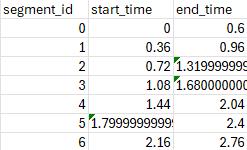
  - **Non-linearity** in some variables
    - RMS Energy is calculated based on the sound clip, simple averaging will give wrong numbers
  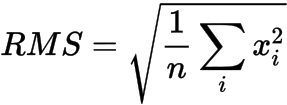
    - MFCCs (Mel-Frequency Cepstral Coefficients) are logarithmic, averaging can cause temporal information to be lost
      - Cepstral Mean Subtraction (CMS): A standard technique where the mean of the MFCCs across an utterance is calculated and subtracted from each frame to remove linear channel effects (requires the original clip)
ideally: Access the **raw audio** and recalculate features for the full 2.76s duration. This is the only way to be mathematically accurate.
Practically: **extracting statistical summary**, generate Mean, Max, and StdDev for features
- Group by segment_id and calculate multiple statistics to capture the variation


1. Combine all rows into 2.76 clips
2. modify and rerun segmentation in google colab to test viability
3. compare sliding window and bioacustic dataset

##Dataset Reconcilation

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define File Paths
# You need to find the exact path in your Drive.
# Usually starts with /content/drive/My Drive/...
bio_path = '/content/drive/MyDrive/Audio Moth Data/bioacoustics_dataset.csv'
sliding_path = '/content/drive/MyDrive/Audio Moth Data/sliding_window_acoustic.csv'

# 3. Load the Dataframes
print("Loading datasets...")
try:
    df_bio = pd.read_csv(bio_path)
    df_sliding = pd.read_csv(sliding_path)
    print("Datasets loaded successfully.")
except FileNotFoundError:
    print("ERROR: Could not find files. Please check your paths.")

In [ ]:
# --- ADVANCED FEATURE ENGINEERING FOR DEPLOYMENT ---

def engineer_human_presence_features(data):
    """
    Transforms raw acoustic and environmental data into multi-scale temporal,
    biological, and compression-resilient features.
    """
    data = data.copy()

    # Ensure data is sorted by time for accurate Rolling/Delta calculations
    if 'Datetime' in data.columns:
        data['Datetime'] = pd.to_datetime(data['Datetime'])
        data = data.sort_values(by='Datetime')

    # 1. Cyclical Time (Convert hour into a continuous loop)
    if 'Datetime_hour' in data.columns:
        data['hour_sin'] = np.sin(2 * np.pi * data['Datetime_hour'] / 24)
        data['hour_cos'] = np.cos(2 * np.pi * data['Datetime_hour'] / 24)

    # 2. Multi-Scale Temporal Dynamics (Assuming ~3s per window)
    time_scales = {
        '15s': 5,
        '30s': 10,
        '60s': 20,
        '5m': 100
    }

    if 'RMS Energy' in data.columns:
        # Immediate sudden change (Window-to-Window)
        data['RMS_Energy_Delta'] = data['RMS Energy'].diff().fillna(0)

        # Calculate Variance and Mean for multiple time scales
        for scale_name, window_size in time_scales.items():
            data[f'RMS_Energy_Var_{scale_name}'] = data['RMS Energy'].rolling(window=window_size, min_periods=1).var().fillna(0)
            data[f'RMS_Energy_Mean_{scale_name}'] = data['RMS Energy'].rolling(window=window_size, min_periods=1).mean().fillna(0)

    # 3. Biological Sentinel Logic & Deltas
    sentinels = ['is_Orange_billed_Sparrow', 'is_Antpitta', 'is_Pygmy_Tyrant']
    existing_sentinels = [c for c in sentinels if c in data.columns]

    if existing_sentinels:
        # Sum of active species (0 to 3)
        data['sentinel_active_count'] = data[existing_sentinels].sum(axis=1)

        # Delta for species appearing/disappearing (- means they stopped, + means they started)
        data['Sentinel_Count_Delta'] = data['sentinel_active_count'].diff().fillna(0)

        # Calculate 5-minute historical bird activity
        data['Rolling_Sentinel_Activity_5m'] = data['sentinel_active_count'].rolling(window=100, min_periods=1).mean().fillna(0)

        # True "Eerie Silence": It was active in the last 5 minutes, but is suddenly 0 right now.
        data['is_suspiciously_quiet'] = (
            (data['sentinel_active_count'] == 0) &
            (data['Rolling_Sentinel_Activity_5m'] > 0.05)
        ).astype(int)

    # 4. Environmental Interplay (Prevent weather false positives)
    if 'RMS Energy' in data.columns and 'Windspeed' in data.columns:
        # High energy + low wind = anomaly. Add 0.001 to prevent divide-by-zero
        data['Energy_per_Wind'] = data['RMS Energy'] / (data['Windspeed'] + 0.001)

    return data

# --- Apply the transformations ---
print("Engineering multi-scale features for df...")
df = engineer_human_presence_features(df)
print("Done!")

# --- Prevent KeyError for 'is_simulation' ---
if 'is_simulation' not in df.columns:
    df['is_simulation'] = (~df['Sim Type'].isna()).astype(int)

# --- Updated Feature Selection List ---
custom_features = [
    # Resilient Acoustic Features
    'Spectral Centroid', 'Spectral Bandwidth', 'Spectral Flatness',
    'Zero Crossing Rate', 'RMS Energy',

    # Engineered Temporal Deltas
    'RMS_Energy_Delta', 'Sentinel_Count_Delta',

    # Multi-Scale Rolling Variances (Chaos indicators)
    'RMS_Energy_Var_15s', 'RMS_Energy_Var_30s', 'RMS_Energy_Var_60s', 'RMS_Energy_Var_5m',

    # Multi-Scale Rolling Means (Baseline volume indicators)
    'RMS_Energy_Mean_15s', 'RMS_Energy_Mean_30s', 'RMS_Energy_Mean_60s', 'RMS_Energy_Mean_5m',

    # Environmental & Time
    'Windspeed', 'Temperature', 'Humidity', 'Energy_per_Wind',
    'hour_sin', 'hour_cos',

    # Biological Indicators
    'sentinel_active_count', 'is_suspiciously_quiet'
]

# Ensure we only use features that actually exist
custom_features = [col for col in custom_features if col in df.columns]

# Assign X and y
X = df[custom_features]
y = df['is_simulation']

In [ ]:
import pandas as pd
import numpy as np

def analyze_datasets(sliding_df, bio_df):
    print("\n=== 1. DATA PREPARATION ===")

    # 1. Normalize Column Names for Comparison
    sliding_df['join_key'] = sliding_df['original_clip_name'].astype(str).str.strip()
    bio_df['join_key'] = bio_df['clip_name'].astype(str).str.strip()

    # 2. Collapse Sliding Window (Many-to-One)
    # We group by the filename and take the first entry of 'Sim Type'
    # Assumption: The simulation type is constant for the entire clip.
    sliding_collapsed = sliding_df.groupby('join_key').first().reset_index()

    print(f"Original Sliding Rows: {len(sliding_df)}")
    print(f"Collapsed Sliding Files: {len(sliding_collapsed)}")
    print(f"Bioacoustics Files:      {len(bio_df)}")
    print("-" * 40)

    # === 2. EXISTENCE CHECK ===
    sliding_files = set(sliding_collapsed['join_key'])
    bio_files = set(bio_df['join_key'])

    common = sliding_files.intersection(bio_files)
    in_sliding_only = sliding_files - bio_files
    in_bio_only = bio_files - sliding_files

    print("=== 2. DISCREPANCY REPORT ===")
    print(f"Files in BOTH datasets:       {len(common)}")
    print(f"Files in Sliding ONLY:        {len(in_sliding_only)} (Unexpected extra files)")
    print(f"Files in Bioacoustics ONLY:   {len(in_bio_only)} (Missing from model)")

    if len(in_bio_only) > 0:
        print("\n[Example files missing from Sliding Window]")
        print(list(in_bio_only)[:5])

    print("-" * 40)

    # === 3. POSITIVITY RATES (Updated for Sim Type) ===

    # RULE 1: Bioacoustics Positive = 'Sim Type' is NOT "[]"
    # We convert to string to ensure "[]" is caught even if formatted differently
    bio_pos_mask = bio_df['Sim Type'].astype(str) != "[]"
    bio_pos_count = bio_pos_mask.sum()
    bio_rate = (bio_pos_count / len(bio_df)) * 100

    # RULE 2: Sliding Window Positive = 'Sim Type' is NOT Blank (NaN/None)
    # We use the collapsed DF to avoid double counting
    # pd.notna() handles NaNs, None, and NaT
    slide_pos_mask = sliding_collapsed['Sim Type'].notna() & (sliding_collapsed['Sim Type'] != "")
    slide_pos_count = slide_pos_mask.sum()
    slide_rate = (slide_pos_count / len(sliding_collapsed)) * 100

    print("=== 3. POSITIVITY RATES (Target Balance) ===")
    print(f"Bioacoustics (Rule: != '[]'):   {bio_rate:.2f}% ({bio_pos_count}/{len(bio_df)})")
    print(f"Sliding Window (Rule: Not Blank): {slide_rate:.2f}% ({slide_pos_count}/{len(sliding_collapsed)})")

    if abs(bio_rate - slide_rate) > 0.5:
        print(">> WARNING: Significant shift in class balance detected!")
    else:
        print(">> Class balance is consistent.")
    print("-" * 40)

    # === 4. FEATURE STATISTICS (Bioacoustics DF) ===
    print("=== 4. BIOACOUSTICS FEATURE STATS ===")

    # Updated to check for Spectral Centroid or fallback features
    possible_stats = ['Spectral Centroid', 'Spectral Bandwidth', 'Zero Crossing Rate', 'RMS Energy']
    existing_cols = [c for c in possible_stats if c in bio_df.columns]

    if existing_cols:
        stats = bio_df[existing_cols].agg(['max', 'mean', 'median', 'std'])
        print(stats)
    else:
        print(f"Could not find columns {possible_stats}")

analyze_datasets(df_sliding, df_bio)

Bioacoustic dataset against my old sliding window, to see if there were any updates in the shared dataset

In [ ]:
analyze_datasets(df, df_bio)

In [ ]:
def print_dataset_stats(df, dataset_name, mode='bio'):
    """
    mode: 'bio' (Positive != '[]') OR 'sliding' (Positive != NaN)
    """
    print(f"========================================")
    print(f" STATISTICS FOR: {dataset_name}")
    print(f"========================================")
    print(f"Total Rows: {len(df)}")

    # --- 1. POSITIVITY RATE (Based on Sim Type) ---
    if 'Sim Type' in df.columns:
        if mode == 'bio':
            # BIOACOUSTICS RULE: Negative is "[]"
            # We treat everything that isn't "[]" as positive
            is_positive = df['Sim Type'].astype(str) != '[]'
            rule_desc = "!= '[]'"
        elif mode == 'sliding':
            # SLIDING WINDOW RULE: Negative is Blank/NaN
            # We treat everything that isn't NaN/Empty as positive
            is_positive = df['Sim Type'].notna() & (df['Sim Type'] != "")
            rule_desc = "Not Blank"

        pos_count = is_positive.sum()
        pos_rate = (pos_count / len(df)) * 100

        print(f"\n[Class Balance - Rule: {rule_desc}]")
        print(f"Positive Samples: {pos_count}")
        print(f"Negative Samples: {len(df) - pos_count}")
        print(f"Positivity Rate:  {pos_rate:.2f}%")
    else:
        print("\n[Class Balance] 'Sim Type' column not found.")

    # --- 2. ACOUSTIC FEATURE STATISTICS ---
    print(f"\n[Acoustic Feature Statistics]")

    target_features = [
        'Spectral Centroid',
        'Zero Crossing Rate',
        'Spectral Bandwidth',
        'RMS Energy'
    ]

    existing_features = [col for col in target_features if col in df.columns]

    if existing_features:
        stats_df = df[existing_features].agg(['max', 'mean', 'median', 'std'])
        print(stats_df.T.to_string())
    else:
        print(f"None of the requested features {target_features} were found.")

    print("\n")

# --- EXECUTION EXAMPLES ---
print_dataset_stats(df_bio, "Bioacoustics Dataset", mode='bio')
print_dataset_stats(df_sliding, "Sliding Window Dataset", mode='sliding')

There seems to be a lot less (4,214) positive samples in the sliding_window_acoustics dataset compared to the bioacoustic dataset despite having similar total counts. Considering using bioacoustic dataset for future model training, or redoing sliding window extraction and segmentation code for higher positive sam

### Advanced Modeling & Exploration ###

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

print("Running Grid Search... (This may take a few minutes)")

# 1. Define the parameters to test
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1]
}

# 2. Initialize a base XGBoost model
xgb_base = XGBClassifier(
    scale_pos_weight=conservative_weight, # Using the tuned weight from earlier
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

# 3. Run the Grid Search (cv=3 means it tests each combination 3 times)
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# 4. Extract the results and format them for Seaborn
results_df = pd.DataFrame(grid_search.cv_results_)
heatmap_data = results_df.pivot(index='param_max_depth', columns='param_learning_rate', values='mean_test_score')

# 5. Draw the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".3f", cbar_kws={'label': 'Mean F1 Score'})
plt.title('XGBoost Cross-Validation F1 Scores', fontsize=14)
plt.xlabel('Learning Rate', fontsize=12)
plt.ylabel('Max Depth (Tree Complexity)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Best Parameters Found: {grid_search.best_params_}")

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# 1. Bring the massive haystack down to a manageable 50,000 samples
under_sampler = RandomUnderSampler(sampling_strategy={0: 50000}, random_state=42)

# 2. Synthetically generate human acoustic patterns to reach 50,000
smote = SMOTE(sampling_strategy={1: 50000}, random_state=42)

# 3. Combine them into a single pipeline
resample_pipeline = Pipeline([
    ('undersample', under_sampler),
    ('oversample', smote)
])

# 4. Apply ONLY to the training data! (Never synthesize your test data)
print("Resampling training data...")
X_train_res, y_train_res = resample_pipeline.fit_resample(X_train, y_train)

print("--- New Balanced Training Distribution ---")
print(y_train_res.value_counts())

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

print("Training CatBoost Model...")
cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    auto_class_weights='SqrtBalanced', # Built-in imbalance handler
    eval_metric='F1',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100                        # Prints an update every 100 trees
)

# Train on the SMOTEd data, but evaluate on the untouched real-world test data
cat_model.fit(
    X_train_res, y_train_res,
    eval_set=(X_test, y_test)
)

print("\n--- CatBoost Classification Report ---")
y_pred_cat = cat_model.predict(X_test)
print(classification_report(y_test, y_pred_cat))


In [ ]:
!pip install catboost

In [ ]:
def generate_lora_alerts(predictions_df, time_col='Datetime', pred_col='Prediction', window_minutes=2, threshold_m=5):
    """
    Simulates the Edge Device (Shaman 2 Node) filtering logic.
    Requires 'M' positive 3-second detections within 'N' minutes to trigger a LoRa alert.
    """
    print(f"Running Event Logic: {threshold_m} hits required within a {window_minutes}-minute window.")

    # Ensure data is sorted sequentially by time
    edge_df = predictions_df.sort_values(time_col).copy()
    edge_df = edge_df.set_index(time_col)

    # Calculate rolling sum of positive predictions over the time window
    # 'T' is the pandas offset alias for minutes
    window_string = f'{window_minutes}T'
    edge_df['Hits_in_Window'] = edge_df[pred_col].rolling(window_string).sum().fillna(0)

    # Trigger the LoRa alert only if the rolling hits exceed the required threshold
    edge_df['LoRa_Alert_Triggered'] = (edge_df['Hits_in_Window'] >= threshold_m).astype(int)

    # Analyze the false-positive reduction
    total_raw_hits = edge_df[pred_col].sum()
    total_lora_alerts = edge_df[edge_df['LoRa_Alert_Triggered'] == 1].shape[0]

    print(f"Raw 3-second Model Hits: {total_raw_hits}")
    print(f"Filtered LoRa Alerts Sent: {total_lora_alerts}")
    if total_raw_hits > 0:
        reduction = (1 - (total_lora_alerts / total_raw_hits)) * 100
        print(f"False Alarm Reduction: {reduction:.1f}%")

    return edge_df.reset_index()

# Note: To test this, you will need to pass in a dataframe containing your test set
# predictions and their original Datetimes.

In [ ]:
import pandas as pd
import numpy as np

def export_logic_test_vectors(output_filename="logic_test_vectors.csv"):
    print("Generating M-of-N Test Vectors for Mechatronics Team...")

    # 1. Create a simulated timeline (100 windows, 3 seconds each = 5 minutes)
    # 0 = silence/background, 1 = positive model hit
    simulated_hits = np.zeros(100, dtype=int)

    # Inject isolated noise (e.g., shoe drop) at window 10 (2 hits)
    simulated_hits[10:12] = 1

    # Inject sustained event (e.g., human walking/roasting) from window 40 to 60
    # Randomly hitting about 70% of the time during the event
    simulated_hits[40:60] = np.random.choice([0, 1], size=20, p=[0.3, 0.7])

    df = pd.DataFrame({'Raw_Hit': simulated_hits})

    # 2. Apply the Logic: M=5 hits required within a rolling window of N=40 (2 minutes)
    df['Rolling_Hits'] = df['Raw_Hit'].rolling(window=40, min_periods=1).sum()
    df['LoRa_Trigger'] = (df['Rolling_Hits'] >= 5).astype(int)

    # 3. Export for the hardware team
    df[['Raw_Hit', 'LoRa_Trigger']].to_csv(output_filename, index=False)
    print(f"✅ Success: Test vectors saved to {output_filename}")
    print("Hand this CSV to the hardware team to verify their C++ logic.")

# Run the function
export_logic_test_vectors()

In [ ]:
!pip install onnxmltools skl2onnx -q

import onnxmltools
from onnxmltools.convert import convert_xgboost
from onnxmltools.utils import save_model
from onnxmltools.convert.common.data_types import FloatTensorType
from xgboost import XGBClassifier
import json

# ── Step 1: Strip named features from the JSON ──────────────────────────────
with open('shaman_champion.json', 'r') as f:
    model_dict = json.load(f)

# Remove feature names so ONNX sees f0, f1, f2... instead of 'Windspeed' etc.
if 'learner' in model_dict:
    model_dict['learner']['feature_names'] = []
    model_dict['learner']['feature_types'] = []

with open('shaman_champion_stripped.json', 'w') as f:
    json.dump(model_dict, f)

# ── Step 2: Load the stripped model ─────────────────────────────────────────
clf = XGBClassifier()
clf.load_model('shaman_champion_stripped.json')

N_FEATURES = clf.n_features_in_
print(f"Detected {N_FEATURES} features")

# ── Step 3: Convert to ONNX ──────────────────────────────────────────────────
initial_type = [('float_input', FloatTensorType([None, N_FEATURES]))]
onnx_model = convert_xgboost(clf, initial_types=initial_type)

save_model(onnx_model, 'shaman_model.onnx')

print("✅ Success: Model exported as ONNX!")
print("File generated: shaman_model.onnx")

In [ ]:
import struct
import time

def simulate_lora_payload(confidence_float, duration_windows, eerie_silence_active):
    """
    Packs data into an ultra-lightweight 8-byte hexadecimal string for LoRaWAN.
    """
    print("--- LoRa Payload Serialization ---")

    # Byte 0: Header (0x02 = Human Presence Event)
    header = 2

    # Bytes 1-4: Timestamp (Unix Epoch)
    timestamp = int(time.time())

    # Byte 5: Confidence Score (Convert float 0.0-1.0 to integer 0-255)
    confidence_int = int(confidence_float * 255)

    # Byte 6: Event Duration (Number of 3-second windows)
    duration = int(duration_windows)

    # Byte 7: Biological Flag (1 = Eerie Silence active, 0 = Normal)
    bio_flag = 1 if eerie_silence_active else 0

    # Pack into struct
    # > = Big-Endian
    # B = unsigned char (1 byte)
    # I = unsigned int (4 bytes)
    # Format: 1 byte, 4 bytes, 1 byte, 1 byte, 1 byte = 8 bytes total
    payload_bytes = struct.pack('> B I B B B', header, timestamp, confidence_int, duration, bio_flag)

    # Convert to Hex string for transmission
    hex_payload = payload_bytes.hex()

    print(f"Input: Confidence {confidence_float}, Duration {duration_windows} windows, Bio Flag {bio_flag}")
    print(f"Bit Format: > B I B B B")
    print(f"Final LoRa Hex Payload: {hex_payload}")
    print(f"Total Transmission Size: {len(payload_bytes)} Bytes")

# Test the function with a simulated event
simulate_lora_payload(confidence_float=0.92, duration_windows=15, eerie_silence_active=True)